Self Assessment Tool for Rehabilitation and TUG analysis
---
---
In this notebook, we explore the use of wearable IMU devices to create a self assessment system for rehabilitation and TUG analysis.  The devices are worn around the waist, around the knee and around the thigh.  
Each device records accelerometer and gyroscope measurements, as well as the arduino onboard clock timestamp (when the data was recorded). Each device has slight variations in the arduino milliseconds recorded.

#### The different Approaches 
---

To achieve our aim, we will experiment with different variations of our dataset, and different experimental approaches. Our resulting model will be a combination of the best performing dataset and approach combination. 

Because the timestamps from each IMU device is different, we will take different approaches to consolidate all the recorded measurements into a usable dataset

In the first approach, we will merge the data from each node into a dataset, using the average of the `pc_timestamp` field for each row. 

In the second approach, we will use each IMU device independently, flatten them and use them in building the models 

## Imports and Global Experimental Configuration

This notebook uses synchronized data from three wearable IMU nodes positioned at the knee, thigh, and lumbar region.

Each IMU records:

- Three accelerometer channels: `ax`, `ay`, and `az`
- Three gyroscope channels: `gx`, `gy`, and `gz`

The Arduino acquisition program records one sample every 20 ms. Therefore, the effective dataset sampling frequency is:

\[
f_s = \frac{1}{0.02} = 50 \text{ Hz}
\]

This 50-Hz value must be used consistently throughout preprocessing, filtering, feature engineering, time conversion, and model segmentation.

For Human Activity Recognition, two-second windows are used. At 50 Hz, each window therefore contains:

\[
2 \times 50 = 100 \text{ samples}
\]

A 50% overlap advances the window by one second, or 50 samples.

Keeping these values in one global configuration prevents inconsistent assumptions such as using 50 Hz in one part of the notebook and 20 Hz in another.

#### GLobal Configurations
---


In [1]:
"""Project-wide imports and configuration.

All tunable constants live in this cell so the rest of the notebook can focus
on behaviour rather than configuration.
"""

from pathlib import Path
from collections import Counter
import gc
import random
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from scipy.signal import butter, find_peaks, sosfiltfilt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv1D,
    ConvLSTM2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling1D,
    Input,
    LSTM,
    MaxPooling1D,
)
from tensorflow.keras.optimizers import Adam


# Reproducibility
RANDOM_SEED = 42

# Data location
DATA_DIRECTORY = "data_copy"
MODEL_DIRECTORY = "models"

# Sensor configuration
SAMPLING_RATE_HZ = 50
DT = 1.0 / SAMPLING_RATE_HZ
SENSOR_NODES = ("knee", "lumbar", "thigh")
ACCELEROMETER_CHANNELS = ("ax", "ay", "az")
GYROSCOPE_CHANNELS = ("gx", "gy", "gz")
SENSOR_CHANNELS = ACCELEROMETER_CHANNELS + GYROSCOPE_CHANNELS

# HAR configuration
HAR_ACTIVITIES = ("sit", "stand", "walk")
SELECTED_ACTIVITIES = list(HAR_ACTIVITIES)
WINDOW_SECONDS = 2.0
WINDOW_SIZE = int(SAMPLING_RATE_HZ * WINDOW_SECONDS)
TIME_STEPS = WINDOW_SIZE
OVERLAP_RATIO = 0.50
WINDOW_STEP = int(WINDOW_SIZE * (1 - OVERLAP_RATIO))
HOP_SIZE = WINDOW_STEP

# Synchronisation quality control
MIN_STREAM_BALANCE = 0.80
MIN_SYNCHRONISED_SAMPLES = WINDOW_SIZE

# Filtering
LOWPASS_CUTOFF_HZ = 4.0
FILTER_ORDER = 4

# Feature engineering / EDA
FEATURE_ROLLING_SECONDS = 2.0
MIN_STEP_INTERVAL_SECONDS = 0.30
STEP_PROMINENCE_MULTIPLIER = 0.50
CORRELATION_THRESHOLD = 0.90
SAMPLE_USER_ID = "user_2"

# Neural-network training
MAX_EPOCHS = 40
BATCH_SIZE = 64
EARLY_STOPPING_PATIENCE = 6
LR_REDUCTION_PATIENCE = 3
LEARNING_RATE = 0.001

# Conv-LSTM shape
NUMBER_OF_SUBSEQUENCES = 4
STEPS_PER_SUBSEQUENCE = WINDOW_SIZE // NUMBER_OF_SUBSEQUENCES

# Feature importance
PERMUTATION_REPEATS = 3

# Random Forest
BASE_RF_PARAMETERS = {
    "n_estimators": 400,
    "max_depth": 14,
    "min_samples_split": 8,
    "min_samples_leaf": 3,
    "max_features": "sqrt",
    "class_weight": "balanced_subsample",
}
RF_PARAMETER_DISTRIBUTIONS = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [None, 8, 12, 16, 20],
    "min_samples_split": [2, 4, 8, 12],
    "min_samples_leaf": [1, 2, 3, 5],
    "max_features": ["sqrt", "log2", 0.50, 0.75],
    "class_weight": ["balanced", "balanced_subsample"],
}
RF_TUNING_ITERATIONS = 12
INNER_GROUP_FOLDS = 3

# Inference benchmarking
INFERENCE_WARMUP_RUNS = 20
MAX_BENCHMARK_WINDOWS = 200

# Derived column collections
MOTION_COLUMNS = [
    f"{node}_{channel}"
    for node in SENSOR_NODES
    for channel in SENSOR_CHANNELS
]
ACCELEROMETER_COLUMNS = [
    f"{node}_{channel}"
    for node in SENSOR_NODES
    for channel in ACCELEROMETER_CHANNELS
]
GYROSCOPE_COLUMNS = [
    f"{node}_{channel}"
    for node in SENSOR_NODES
    for channel in GYROSCOPE_CHANNELS
]
MODEL_FEATURE_COLUMNS = MOTION_COLUMNS.copy()
METADATA_COLUMNS = ["pc_timestamp", "user_id", "session_id", "activity"]
QUALITY_CONTROL_COLUMNS = [
    "knee_arduino_ms",
    "lumbar_arduino_ms",
    "thigh_arduino_ms",
]


def find_data_folder(directory_name=DATA_DIRECTORY):
    """Return the first existing project data directory."""
    candidates = (Path(directory_name), Path("..") / directory_name)
    folder = next((path for path in candidates if path.exists()), None)
    if folder is None:
        raise FileNotFoundError(
            f"Could not find '{directory_name}' in the current directory or its parent."
        )
    return folder


def seed_everything(seed=RANDOM_SEED):
    """Seed Python, NumPy and TensorFlow for repeatable experiments."""
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


def print_section(title, width=80):
    """Print a small, consistent console section heading."""
    print("=" * width)
    print(title)
    print("=" * width)


data_folder = find_data_folder()
seed_everything()
sns.set_theme(style="whitegrid")

if WINDOW_SIZE % NUMBER_OF_SUBSEQUENCES != 0:
    raise ValueError("WINDOW_SIZE must be divisible by NUMBER_OF_SUBSEQUENCES.")

print_section("EXPERIMENT CONFIGURATION", 70)
print(f"Sampling frequency : {SAMPLING_RATE_HZ} Hz")
print(f"Sample interval    : {DT:.3f} seconds")
print(f"HAR window length  : {WINDOW_SECONDS:.1f} seconds")
print(f"Samples per window : {WINDOW_SIZE}")
print(f"Window step        : {WINDOW_STEP} samples")
print(f"Raw IMU channels   : {len(MOTION_COLUMNS)}")
print(f"Data directory     : {data_folder.resolve()}")


EXPERIMENT CONFIGURATION
Sampling frequency : 50 Hz
Sample interval    : 0.020 seconds
HAR window length  : 2.0 seconds
Samples per window : 100
Window step        : 50 samples
Raw IMU channels   : 18
Data directory     : /Users/ikenjokudc/Documents/Arduino/finals-project/data_copy


#### Visualising the data folder structure
---

In [2]:
def iter_project_tree(directory, ignore_hidden=False):
    """Yield `(depth, path)` pairs for every item below `directory`."""
    directory = Path(directory)

    def walk(folder, depth):
        """Yield tree entries recursively from one folder."""
        entries = sorted(folder.iterdir(), key=lambda path: (path.is_file(), path.name.lower()))
        for entry in entries:
            if ignore_hidden and entry.name.startswith("."):
                continue
            yield depth, entry
            if entry.is_dir():
                yield from walk(entry, depth + 1)

    yield from walk(directory, 0)


def format_tree_line(depth, path):
    """Format one path as a readable tree line."""
    marker = "📁" if path.is_dir() else "📄"
    return f"{'    ' * depth}{marker} {path.name}"


def show_data_folder_tree(directory=data_folder, ignore_hidden=True):
    """Print the project data directory as a compact tree."""
    print(f"{Path(directory).resolve().name}/")
    for depth, path in iter_project_tree(directory, ignore_hidden=ignore_hidden):
        print(format_tree_line(depth, path))


show_data_folder_tree()


data_copy/
📁 user_1
    📁 sit
        📄 session-knee.csv
        📄 session-lumbar.csv
        📄 session-thigh.csv
    📁 stand
        📄 session-knee.csv
        📄 session-lumbar.csv
        📄 session-thigh.csv
    📁 tug
        📄 session-knee.csv
        📄 session-lumbar.csv
        📄 session-thigh.csv
    📁 walk
        📄 session-knee.csv
        📄 session-lumbar.csv
        📄 session-thigh.csv
📁 user_2
    📁 sit
        📄 session-knee.csv
        📄 session-lumbar.csv
        📄 session-thigh.csv
    📁 stand
        📄 session-knee.csv
        📄 session-lumbar.csv
        📄 session-thigh.csv
    📁 tug
        📄 session-knee.csv
        📄 session-lumbar.csv
        📄 session-thigh.csv
    📁 walk
        📄 session-knee.csv
        📄 session-lumbar.csv
        📄 session-thigh.csv
📁 user_3
    📁 sit
        📄 session-knee.csv
        📄 session-lumbar.csv
        📄 session-thigh.csv
    📁 stand
        📄 session-knee.csv
        📄 session-lumbar.csv
        📄 session-thigh.csv
    📁 tug
    

---
#### The DataSet
---
Each IMU device measures and records the following fields: 
| Field Name | Description |
| :--- | :--- |
| `pc_timestamp` | The absolute wall-clock timestamp recorded by the receiving computer/server when the data packet was received. |
| `arduiono_ms` | The relative uptime timestamp in milliseconds (`millis()`) recorded by the Arduino microcontroller at the exact time of sample capture. |
| `node_position` | The physical location or placement of the sensor node on the subject's body (e.g., wrist, waist, thigh). |
| `activity` | The ground-truth physical activity label being performed during data collection (e.g., sitting, standing, walking). |
| `ax` | Acceleration along the spatial $X$-axis measured by the accelerometer. |
| `ay` | Acceleration along the spatial $Y$-axis measured by the accelerometer. |
| `az` | Acceleration along the spatial $Z$-axis measured by the accelerometer. |
| `gx` | Angular velocity (rotational speed) around the spatial $X$-axis measured by the gyroscope. |
| `gy` | Angular velocity (rotational speed) around the spatial $Y$-axis measured by the gyroscope. |
| `gz` | Angular velocity (rotational speed) around the spatial $Z$-axis measured by the gyroscope. |
| `rssi` | Received Signal Strength Indicator (typically in dBm), measuring the wireless signal quality between the IMU node and the receiver. |


Building the datasets: There will be two datasets, in `Dataset A`, all the columns in the different datasets will be merged, using the `pc_timestamp`
For each user, the three different sensors will be merged into one dataset for each activity. 

so, for `user_1` where activity is sit, the knee, lumbar and thigh datasets will be merged into one.

#### Multi-Sensor Synchronisation and Dataset Construction
---

Each activity recording contains three independent IMU streams:

- Knee
- Lumbar
- Thigh

All three devices sample at approximately 50 Hz, but each Arduino has its own independent `millis()` clock. The absolute `arduino_ms` values therefore cannot be compared directly between devices.

The `pc_timestamp` field is also unsuitable as the primary sample-alignment clock because it represents the time at which a packet was received by the computer. Network transmission and batching can introduce different delays for the knee, lumbar, and thigh devices.

The synchronization strategy therefore uses **relative elapsed time within each individual sensor recording**.

For every sensor:

1. The data are ordered using `arduino_ms`.
2. Duplicate Arduino sample timestamps are removed.
3. The first Arduino timestamp is treated as time zero.
4. Every later sample is expressed as elapsed milliseconds from that point.

For example:

```text
Knee Arduino clock:
153420, 153440, 153460
→
0, 20, 40 ms

Lumbar Arduino clock:
271840, 271860, 271880
→
0, 20, 40 ms

Thigh Arduino clock:
89210, 89230, 89250
→
0, 20, 40 ms

In [3]:
def parse_pc_timestamp(series):
    """Parse a PC timestamp column while inferring the unit for numeric values."""
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().mean() < 0.95:
        return pd.to_datetime(series, errors="coerce")

    magnitude = numeric.dropna().abs().median()
    if magnitude >= 1e17:
        unit = "ns"
    elif magnitude >= 1e14:
        unit = "us"
    elif magnitude >= 1e11:
        unit = "ms"
    else:
        unit = "s"
    return pd.to_datetime(numeric, unit=unit, errors="coerce")


def validate_sensor_columns(data, file_path):
    """Raise a clear error when a sensor CSV is missing required fields."""
    required = ["pc_timestamp", "arduino_ms", *SENSOR_CHANNELS]
    missing = [column for column in required if column not in data.columns]
    if missing:
        raise ValueError(f"{file_path} is missing required columns: {missing}")


def coerce_sensor_types(data):
    """Convert timestamp and IMU fields to the dtypes used by the pipeline."""
    cleaned = data.copy()
    cleaned["pc_timestamp"] = parse_pc_timestamp(cleaned["pc_timestamp"])
    cleaned["arduino_ms"] = pd.to_numeric(cleaned["arduino_ms"], errors="coerce")
    for column in SENSOR_CHANNELS:
        cleaned[column] = pd.to_numeric(cleaned[column], errors="coerce")
    return cleaned


def calculate_median_sample_interval(data):
    """Estimate one sensor's median positive Arduino sampling interval in ms."""
    intervals = data["arduino_ms"].dropna().diff()
    positive = intervals[intervals > 0]
    return float(positive.median()) if not positive.empty else np.nan


def load_sensor_stream(file_path):
    """Load one sensor CSV and preserve its original acquisition order."""
    data = pd.read_csv(file_path)
    validate_sensor_columns(data, file_path)
    data = coerce_sensor_types(data)
    data = (
        data.replace([np.inf, -np.inf], np.nan)
        .dropna(subset=SENSOR_CHANNELS)
        .reset_index(drop=True)
    )
    if data.empty:
        raise ValueError(f"No usable IMU observations remain in {file_path}.")

    data["sample_index"] = np.arange(len(data), dtype=np.int64)
    return data, calculate_median_sample_interval(data)


def get_session_files(activity_dir):
    """Return the expected knee, lumbar and thigh files for one activity session."""
    return {
        node: activity_dir / f"session-{node}.csv"
        for node in SENSOR_NODES
    }


def load_session_streams(sensor_files):
    """Load all three sensor files for one activity session."""
    streams = {}
    intervals = {}
    for node, file_path in sensor_files.items():
        streams[node], intervals[node] = load_sensor_stream(file_path)
    return streams, intervals


def calculate_stream_balance(streams):
    """Return shortest length, longest length and their ratio."""
    counts = {node: len(stream) for node, stream in streams.items()}
    shortest = min(counts.values())
    longest = max(counts.values())
    balance = shortest / longest if longest else 0.0
    return counts, shortest, longest, balance


def session_passes_quality_check(shortest_stream, stream_balance):
    """Decide whether a session contains enough balanced three-sensor data."""
    return (
        stream_balance >= MIN_STREAM_BALANCE
        and shortest_stream >= MIN_SYNCHRONISED_SAMPLES
    )


def prefix_sensor_columns(data, node):
    """Prefix sensor-specific fields so columns remain unique after concatenation."""
    return data.rename(columns={column: f"{node}_{column}" for column in data.columns})


def align_streams_by_sample_order(streams, number_of_rows):
    """Align the three same-rate streams by acquisition order and trim to equal length."""
    aligned = []
    for node in SENSOR_NODES:
        sensor = streams[node].iloc[:number_of_rows].reset_index(drop=True)
        aligned.append(prefix_sensor_columns(sensor, node))
    return pd.concat(aligned, axis=1)


def get_session_start_time(knee_stream):
    """Use the first available knee PC timestamp as a convenient wall-clock origin."""
    timestamps = knee_stream["pc_timestamp"].dropna()
    return timestamps.iloc[0] if not timestamps.empty else pd.Timestamp("2000-01-01")


def add_session_metadata(data, user_id, activity, session_id, start_time):
    """Attach project metadata and a clean 50 Hz analysis timeline."""
    result = data.copy()
    result["user_id"] = user_id
    result["activity"] = activity
    result["session_id"] = session_id
    result["pc_timestamp"] = start_time + pd.to_timedelta(
        np.arange(len(result)) / SAMPLING_RATE_HZ,
        unit="s",
    )
    return result


def select_dataset_columns(data):
    """Keep only metadata, Arduino QC clocks and the 18 model sensor channels."""
    columns = [*METADATA_COLUMNS, *QUALITY_CONTROL_COLUMNS, *MOTION_COLUMNS]
    return data[columns].copy()


def build_session_quality_record(user_id, activity, streams, intervals, aligned_rows, status):
    """Create one tidy quality-control row for a user/activity recording."""
    counts, _, _, balance = calculate_stream_balance(streams)
    return {
        "user_id": user_id,
        "activity": activity,
        "session_id": f"{user_id}__{activity}",
        "knee_rows": counts["knee"],
        "lumbar_rows": counts["lumbar"],
        "thigh_rows": counts["thigh"],
        "aligned_rows": aligned_rows,
        "stream_balance": balance,
        "knee_median_interval_ms": intervals["knee"],
        "lumbar_median_interval_ms": intervals["lumbar"],
        "thigh_median_interval_ms": intervals["thigh"],
        "status": status,
    }


def build_one_session(user_id, activity_dir):
    """Load, validate and align one participant/activity recording."""
    activity = activity_dir.name.strip().lower()
    sensor_files = get_session_files(activity_dir)

    missing_files = [path for path in sensor_files.values() if not path.exists()]
    if missing_files:
        print(f"Skipping {user_id}/{activity}: missing sensor file(s).")
        return None, None

    streams, intervals = load_session_streams(sensor_files)
    _, shortest, _, balance = calculate_stream_balance(streams)
    passes_qc = session_passes_quality_check(shortest, balance)
    status = "included" if passes_qc else "excluded"

    quality = build_session_quality_record(
        user_id=user_id,
        activity=activity,
        streams=streams,
        intervals=intervals,
        aligned_rows=shortest if passes_qc else 0,
        status=status,
    )
    if not passes_qc:
        return None, quality

    aligned = align_streams_by_sample_order(streams, shortest)
    session_id = f"{user_id}__{activity}"
    start_time = get_session_start_time(streams["knee"])
    aligned = add_session_metadata(aligned, user_id, activity, session_id, start_time)
    return select_dataset_columns(aligned), quality


def discover_activity_folders(root=data_folder):
    """Yield `(user_id, activity_folder)` pairs in deterministic order."""
    for user_dir in sorted(root.glob("user_*")):
        if not user_dir.is_dir():
            continue
        for activity_dir in sorted(user_dir.iterdir()):
            if activity_dir.is_dir():
                yield user_dir.name, activity_dir


def build_synchronised_dataset(root=data_folder):
    """Build Dataset_A and its per-session alignment quality report."""
    sessions = []
    quality_rows = []

    for user_id, activity_dir in discover_activity_folders(root):
        session, quality = build_one_session(user_id, activity_dir)
        if quality is not None:
            quality_rows.append(quality)
        if session is not None:
            sessions.append(session)

    quality_df = pd.DataFrame(quality_rows)
    if quality_df.empty:
        raise RuntimeError("No sensor recordings were discovered.")
    if not sessions:
        raise RuntimeError("No sessions passed data-quality control.")

    dataset = (
        pd.concat(sessions, ignore_index=True)
        .sort_values(["user_id", "session_id", "pc_timestamp"])
        .reset_index(drop=True)
    )
    return dataset, quality_df


def report_dataset_coverage(dataset, quality_df):
    """Display session QC and the final participant/activity coverage table."""
    print_section("MULTI-SENSOR ALIGNMENT QUALITY REPORT", 110)
    display(quality_df.sort_values(["user_id", "activity"]).reset_index(drop=True))

    coverage = pd.crosstab(dataset["user_id"], dataset["activity"])
    print_section("FINAL DATASET COVERAGE", 110)
    display(coverage)

    included = quality_df["status"].eq("included").sum()
    excluded = quality_df["status"].eq("excluded").sum()
    print(f"Users retained: {dataset['user_id'].nunique()}")
    print(f"Activities retained: {sorted(dataset['activity'].unique())}")
    print(f"Final Dataset_A shape: {dataset.shape}")
    print(f"Included sessions: {included}")
    print(f"Excluded sessions: {excluded}")
    return coverage


def save_preprocessed_dataset(dataset, quality_df):
    """Persist the synchronized dataset and QC report for reproducibility."""
    dataset.to_csv("Dataset_A.csv", index=False)
    quality_df.to_csv("session_sync_quality.csv", index=False)


def run_dataset_build_pipeline():
    """Run raw-file discovery, QC, alignment, reporting and persistence."""
    global Dataset_A, session_quality_df, coverage_table
    Dataset_A, session_quality_df = build_synchronised_dataset()
    coverage_table = report_dataset_coverage(Dataset_A, session_quality_df)
    save_preprocessed_dataset(Dataset_A, session_quality_df)
    return Dataset_A


Dataset_A = run_dataset_build_pipeline()


MULTI-SENSOR ALIGNMENT QUALITY REPORT


,user_id,activity,session_id,knee_rows,lumbar_rows,thigh_rows,aligned_rows,stream_balance,knee_median_interval_ms,lumbar_median_interval_ms,thigh_median_interval_ms,status
0,user_1,sit,user_1__sit,3440,3490,3420,3420,0.979943,17.0,17.0,17.0,included
1,user_1,stand,user_1__stand,3620,3630,3620,3620,0.997245,17.0,17.0,17.0,included
2,user_1,tug,user_1__tug,460,450,420,420,0.913043,17.0,17.0,17.0,included
3,user_1,walk,user_1__walk,3490,3490,3490,3490,1.000000,17.0,17.0,17.0,included
4,user_2,sit,user_2__sit,260,260,260,260,1.000000,17.0,17.0,17.0,included
5,user_2,stand,user_2__stand,3280,3360,3310,3280,0.976190,17.0,17.0,17.0,included
6,user_2,tug,user_2__tug,570,580,580,570,0.982759,17.0,17.0,17.0,included
7,user_2,walk,user_2__walk,3910,3910,3930,3910,0.994911,17.0,17.0,17.0,included
8,user_3,sit,user_3__sit,4040,4020,4020,4020,0.995050,17.0,17.0,17.0,included
9,user_3,stand,user_3__stand,3800,3790,3800,3790,0.997368,17.0,17.0,17.0,included


FINAL DATASET COVERAGE


activity,sit,stand,tug,walk
user_id,,,,
user_1,3420,3620,420,3490
user_2,260,3280,570,3910
user_3,4020,3790,460,2820
user_4,3460,3600,330,3850
user_5,3510,3530,320,4020
user_6,3680,3540,400,3790
user_7,3710,2980,0,2500
user_8,4060,3590,310,0


Users retained: 8
Activities retained: ['sit', 'stand', 'tug', 'walk']
Final Dataset_A shape: (81240, 25)
Included sessions: 30
Excluded sessions: 2


## Dataset Integrity, Activity Exposure, and Participant Coverage
---

Before analysing sensor distributions, the synchronized dataset must be checked for data-quality problems that could invalidate subsequent conclusions.

### Missing measurements

Every retained row should contain complete measurements from all three IMU nodes. Missing motion values at this stage would indicate that synchronization or data cleaning was incomplete.

### Duplicate measurements

Two genuine consecutive sensor measurements can have identical acceleration or gyroscope values, particularly during relatively static activities. Therefore, complete-row equality should not be used to decide whether a sensor sample is duplicated.

Duplicates were already handled during ingestion using the Arduino sample timestamp. This stage only verifies that duplicate acquisition identities are no longer present.

### Activity exposure

The number of rows belonging to each activity indicates how much recorded data is available for that activity. It does **not** represent the prevalence of that activity in everyday life.

An activity with a longer recording duration naturally contributes more samples and will later produce more HAR windows. Therefore, unequal sample counts can create modelling class imbalance even though they should not be interpreted as behavioural prevalence.

### Participant coverage

A participant-by-activity table is generated to identify which activities are available for each participant after synchronization quality control.

This is particularly important for Leave-One-Subject-Out evaluation because a held-out participant may not contain every target class if one of their sensor recordings had to be excluded.

Activities are nominal categories rather than ordinal quantities. No ordering such as `sit < stand < walk` is implied.

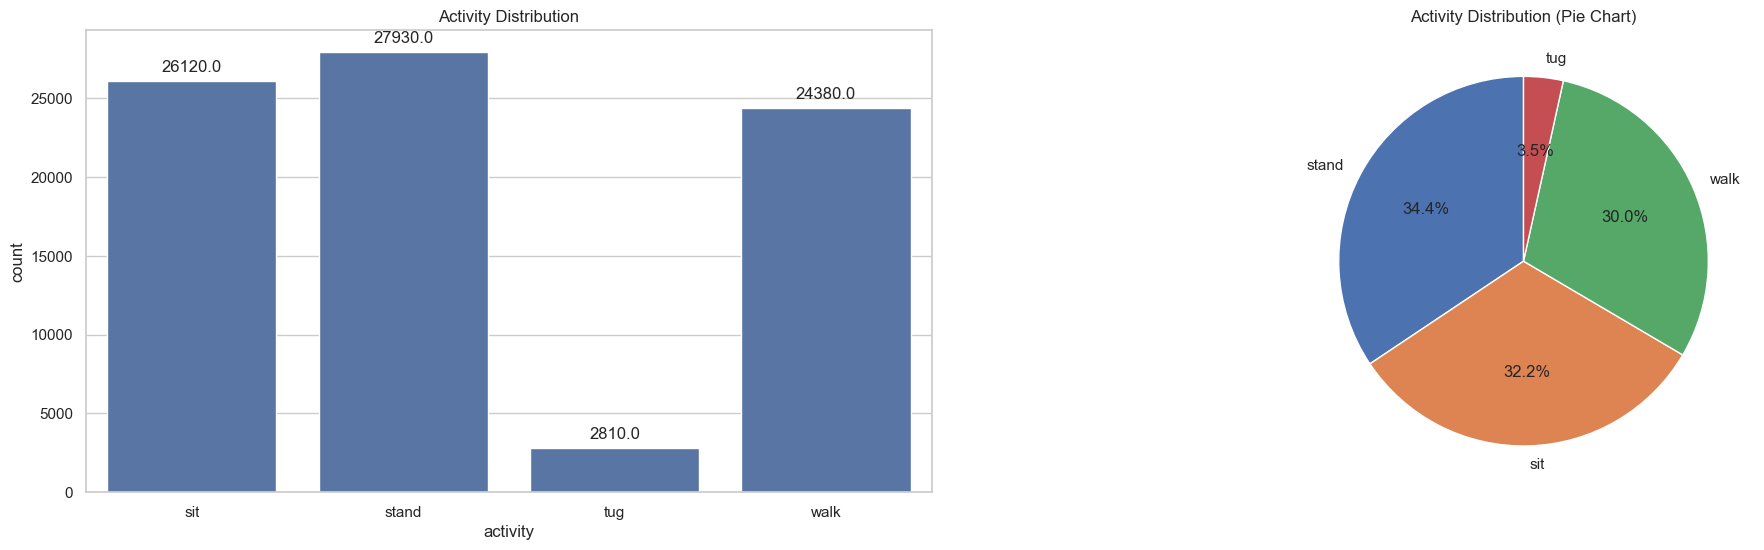

In [4]:
def run_activity_distribution_eda():
    """Run the activity distribution eda stage."""
    global activity_counts
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 6))
    sns.countplot(data=Dataset_A, x='activity', ax=ax1)
    ax1.set_title('Activity Distribution')
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2.0, p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')
    activity_counts = Dataset_A['activity'].value_counts()
    ax2.pie(activity_counts, labels=activity_counts.index, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Activity Distribution (Pie Chart)')
run_activity_distribution_eda()


In [5]:
def required_dataset_columns():
    """Return the columns that must exist after multi-sensor alignment."""
    return [*METADATA_COLUMNS, *MOTION_COLUMNS]


def find_missing_required_columns(dataframe):
    """Return required columns that are absent from a dataframe."""
    return [column for column in required_dataset_columns() if column not in dataframe.columns]


def build_missing_value_summary(dataframe):
    """Count missing values in the columns required by downstream analysis."""
    return (
        dataframe[required_dataset_columns()]
        .isna()
        .sum()
        .to_frame(name="missing_values")
    )


def count_duplicate_sample_identities(dataframe):
    """Count repeated knee acquisition identities inside physical sessions."""
    identity = ["user_id", "session_id", "knee_arduino_ms"]
    return int(dataframe.duplicated(subset=identity).sum())


def validate_dataset_integrity(dataframe):
    """Raise clear errors for missing columns, missing IMU values or duplicates."""
    missing_columns = find_missing_required_columns(dataframe)
    if missing_columns:
        raise ValueError(f"Dataset_A is missing required columns: {missing_columns}")

    missing_motion_values = dataframe[MOTION_COLUMNS].isna().sum().sum()
    if missing_motion_values:
        raise ValueError(f"{missing_motion_values} missing IMU measurements remain.")

    duplicate_count = count_duplicate_sample_identities(dataframe)
    if duplicate_count:
        raise ValueError("Duplicate acquisition identities remain after synchronization.")


def run_dataset_integrity_pipeline():
    """Validate the aligned dataset and display its missing-value summary."""
    global missing_summary

    Dataset_A["pc_timestamp"] = pd.to_datetime(
        Dataset_A["pc_timestamp"],
        errors="coerce",
    )
    validate_dataset_integrity(Dataset_A)
    missing_summary = build_missing_value_summary(Dataset_A)

    print_section("MISSING VALUE SUMMARY")
    display(missing_summary)
    print("Dataset integrity checks passed.")
    return missing_summary


missing_summary = run_dataset_integrity_pipeline()


MISSING VALUE SUMMARY


,missing_values
pc_timestamp,0
user_id,0
session_id,0
activity,0
knee_ax,0
knee_ay,0
knee_az,0
knee_gx,0
knee_gy,0
knee_gz,0


Dataset integrity checks passed.


---
#### Exploratory Dta Analysis
---
---

## Distribution and Extreme-Value Analysis of IMU Signals

The distribution of accelerometer and gyroscope amplitudes provides an initial view of the range, spread, skewness, and potential artefacts within each sensor channel.

These plots represent **signal-amplitude distributions**. They do not indicate the sensor sampling frequency. Sampling frequency is determined from the acquisition configuration and timestamp spacing.

When comparing activities, density-normalised histograms are used rather than stacked sample counts. This prevents activities with longer recordings from visually dominating the plots simply because they contribute more observations.

An Interquartile Range (IQR) analysis is also calculated to identify statistically extreme observations.

The IQR rule is used only as a diagnostic. Values outside the conventional 1.5×IQR range are not automatically deleted because rapid human movement can legitimately generate extreme acceleration or angular-velocity values.

Automatically deleting all statistical outliers could remove exactly the dynamic movements that distinguish one activity from another.

Potentially problematic values should instead be investigated using sensor limits, temporal plots, cross-sensor consistency, and filtering.

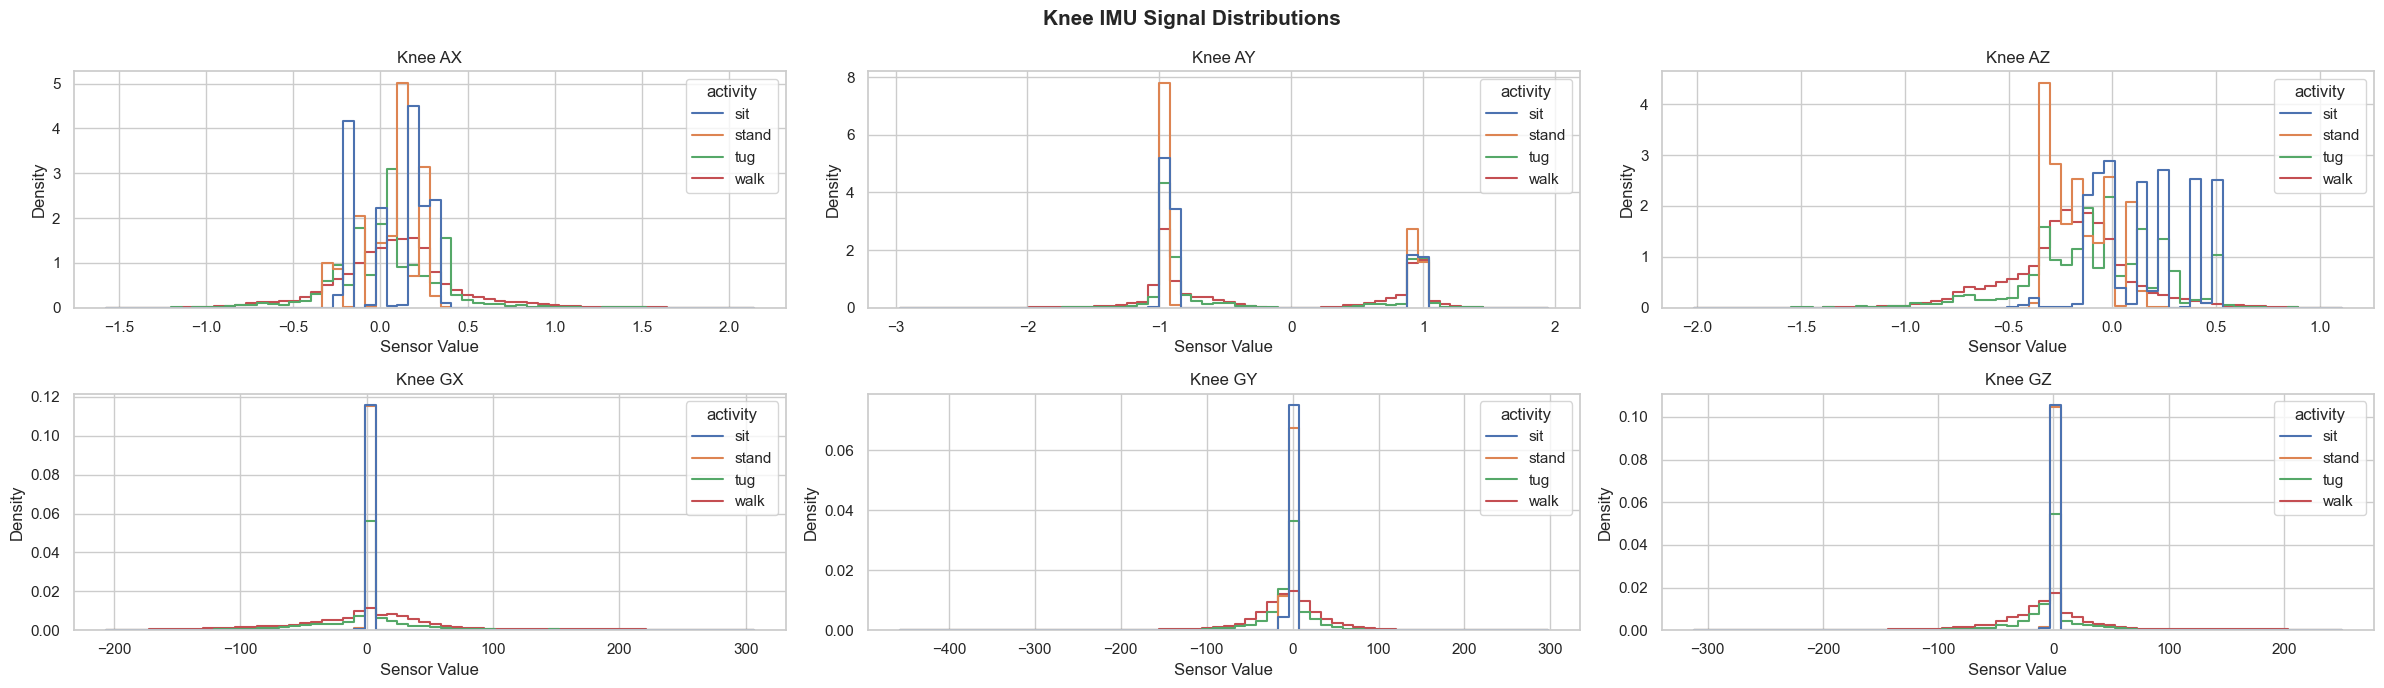

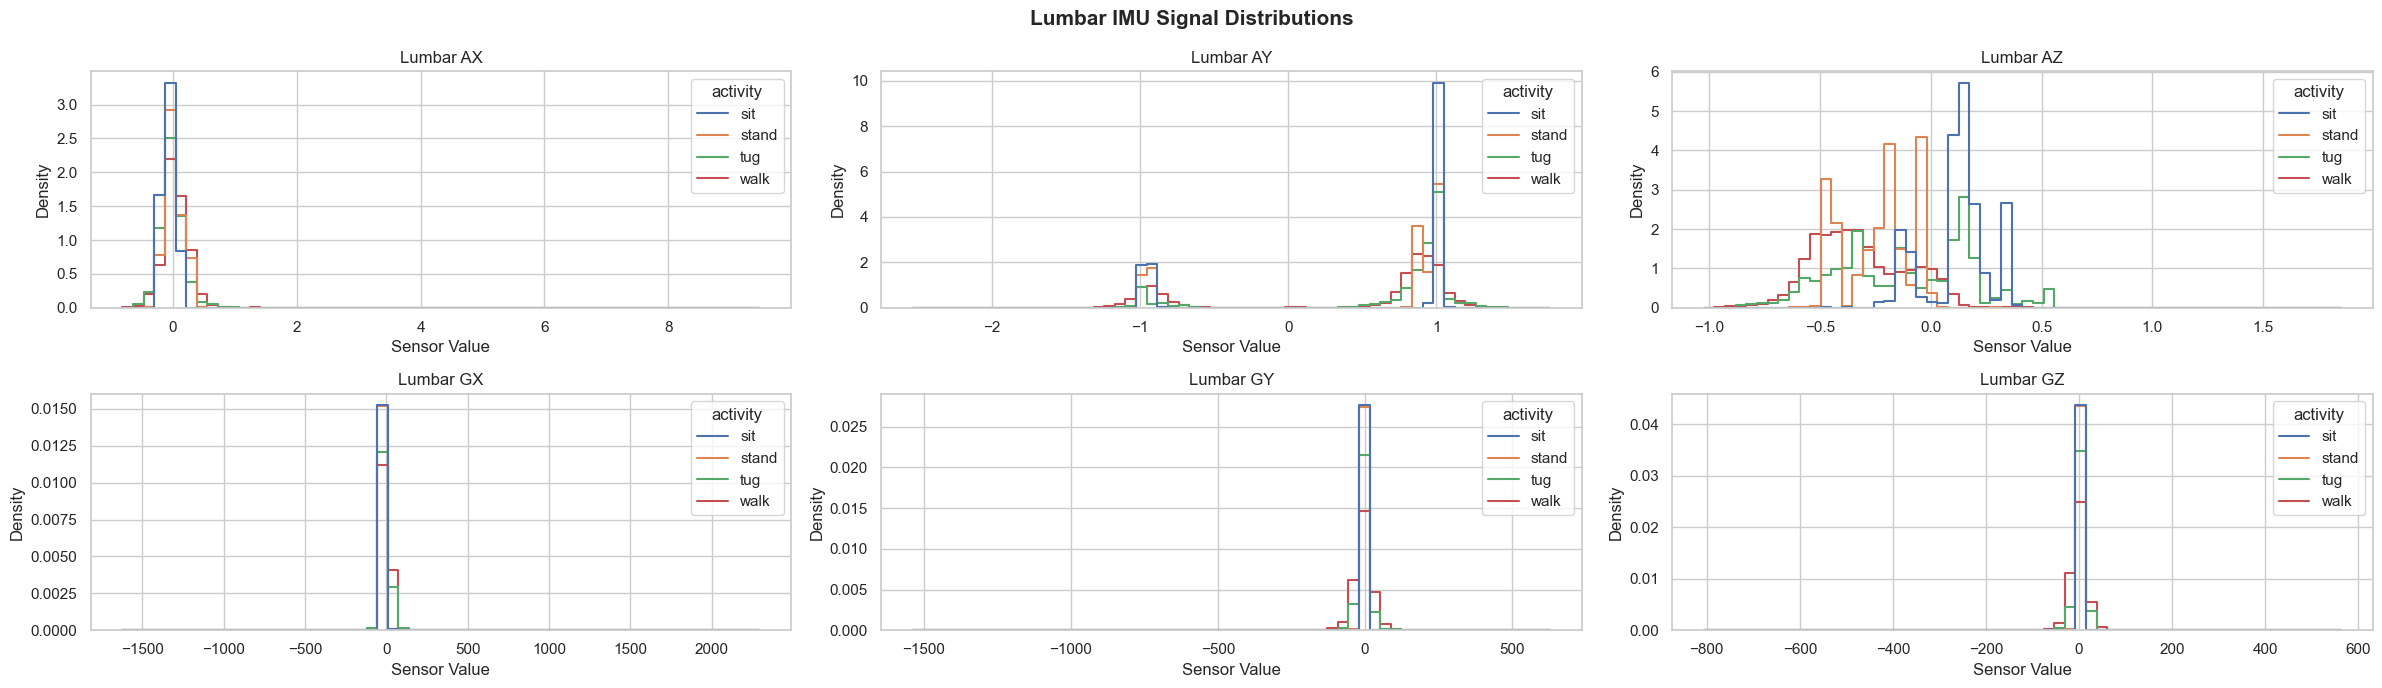

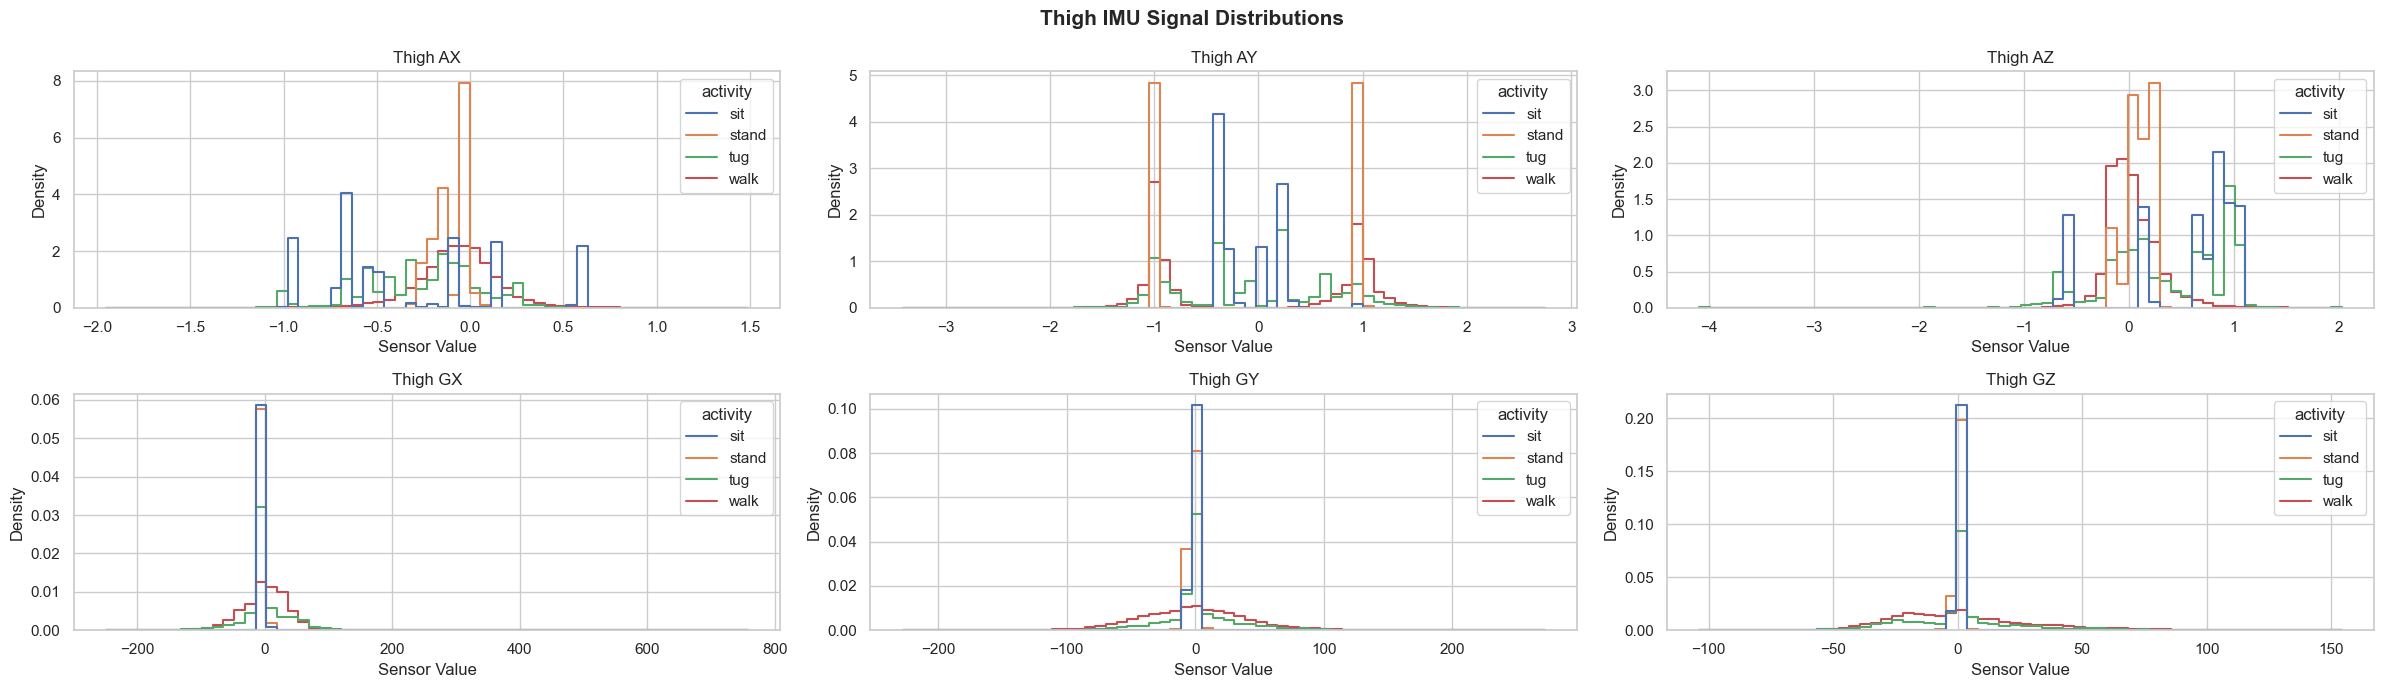

IQR EXTREME-VALUE DIAGNOSTIC


,feature,minimum,maximum,iqr_extreme_count,iqr_extreme_percentage
0,knee_gy,-456.890,296.730,28083,34.568
1,knee_gx,-206.290,306.110,27900,34.343
2,thigh_gy,-227.710,272.020,27594,33.966
3,thigh_gx,-249.060,758.240,27580,33.949
4,knee_gz,-311.780,249.900,27233,33.522
5,thigh_gz,-103.670,154.210,27186,33.464
6,lumbar_gy,-1536.780,630.420,26327,32.406
7,lumbar_gz,-806.400,562.730,24691,30.393
8,lumbar_gx,-1622.320,2293.480,22667,27.901
9,thigh_ax,-1.954,1.491,11887,14.632


In [6]:
def plot_node_distributions(dataframe, node):
    """
    Plot activity-normalised amplitude distributions for all six channels of
    one IMU node.
    """
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 7))
    for channel, axis in zip(SENSOR_CHANNELS, axes.flatten()):
        column = f'{node}_{channel}'
        sns.histplot(data=dataframe, x=column, hue='activity', stat='density', common_norm=False, element='step', fill=False, bins=60, ax=axis)
        axis.set_title(f'{node.capitalize()} {channel.upper()}')
        axis.set_xlabel('Sensor Value')
        axis.set_ylabel('Density')
    fig.suptitle(f'{node.capitalize()} IMU Signal Distributions', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

def run_signal_distribution_eda():
    """Run the signal distribution eda stage."""
    global extreme_value_summary
    for node in SENSOR_NODES:
        plot_node_distributions(Dataset_A, node)
    extreme_value_records = []
    for column in MOTION_COLUMNS:
        q1 = Dataset_A[column].quantile(0.25)
        q3 = Dataset_A[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        extreme_mask = (Dataset_A[column] < lower_bound) | (Dataset_A[column] > upper_bound)
        extreme_value_records.append({'feature': column, 'minimum': Dataset_A[column].min(), 'maximum': Dataset_A[column].max(), 'iqr_extreme_count': int(extreme_mask.sum()), 'iqr_extreme_percentage': extreme_mask.mean() * 100})
    extreme_value_summary = pd.DataFrame(extreme_value_records).sort_values('iqr_extreme_percentage', ascending=False).reset_index(drop=True)
    print('=' * 80)
    print('IQR EXTREME-VALUE DIAGNOSTIC')
    print('=' * 80)
    display(extreme_value_summary.round(3))
run_signal_distribution_eda()


## Boxplots
---

The boxplots provide a compact view of the distributions of the accelerometer
measurements and highlight observations that fall outside the typical
interquartile range.

These observations should not automatically be removed. In wearable IMU data,
large accelerations can correspond to genuine rapid body movements rather than
measurement errors.

The boxplots are therefore used as a diagnostic tool only. Potentially extreme
values will be retained unless there is evidence that they exceed the physical
sensor limits or result from data corruption.

The activity variable is a nominal categorical target. No numerical ordering
between sitting, standing, walking, or TUG is assumed.

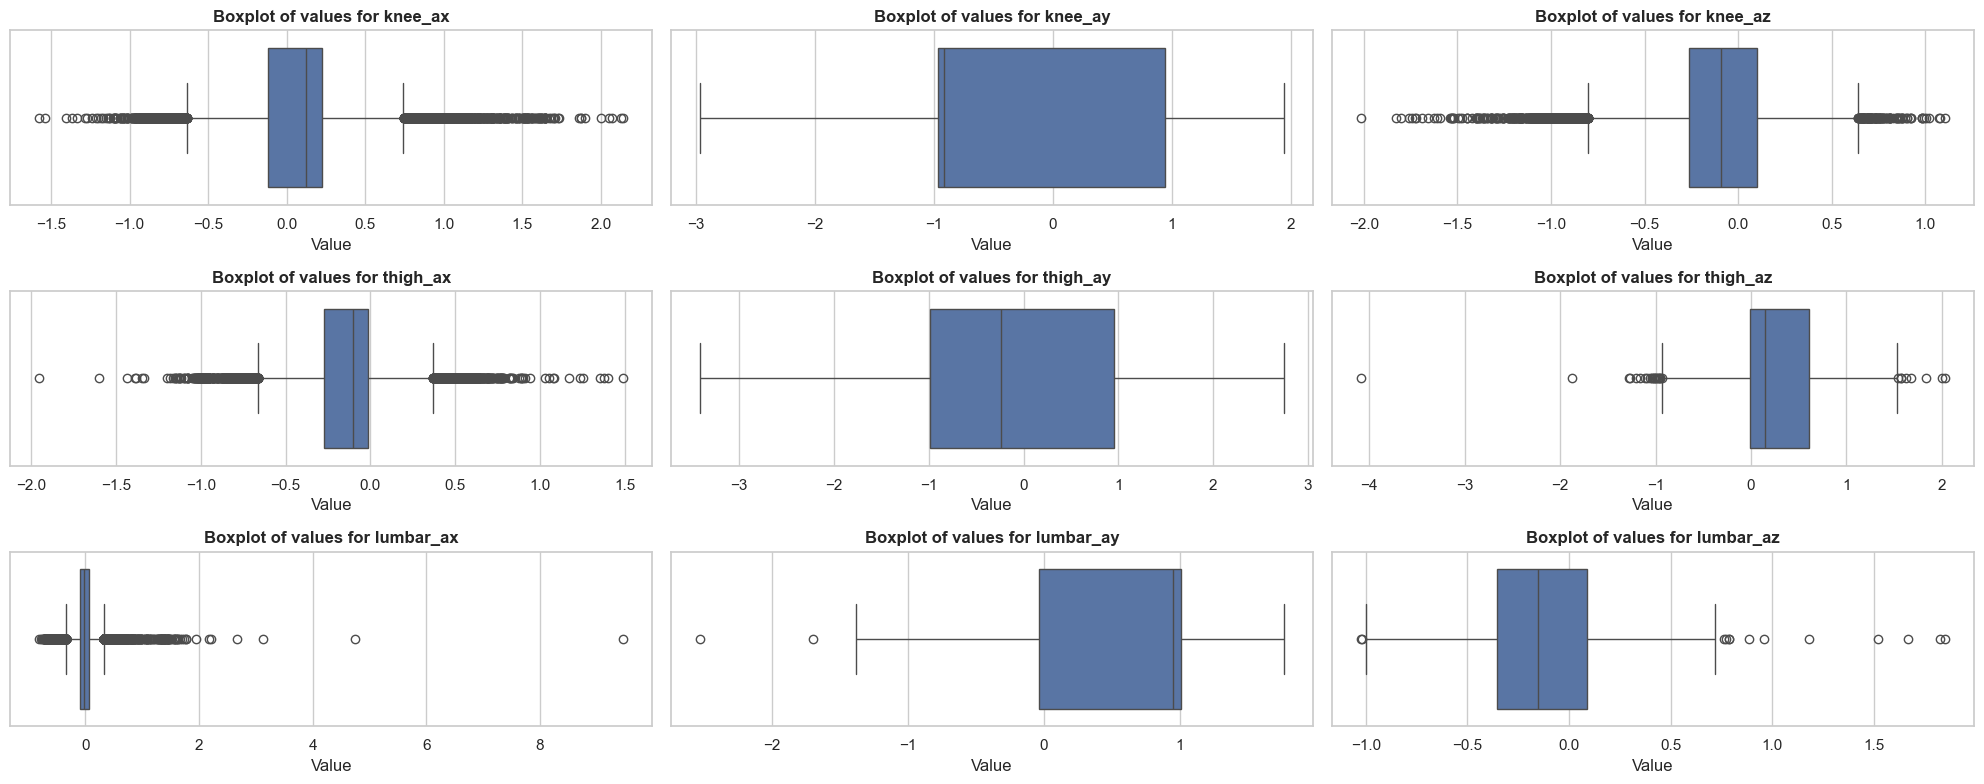

In [7]:
def run_boxplot_eda():
    """Run the boxplot eda stage."""
    columns_to_plot = ['knee_ax', 'knee_ay', 'knee_az', 'thigh_ax', 'thigh_ay', 'thigh_az', 'lumbar_ax', 'lumbar_ay', 'lumbar_az']
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 8))
    for column, ax in zip(columns_to_plot, axes.flatten()):
        sns.boxplot(data=Dataset_A, x=column, ax=ax)
        ax.set_title(f'Boxplot of values for {column}', fontweight='bold')
        ax.set_xlabel('Value')
    plt.tight_layout()
    plt.show()
run_boxplot_eda()


The boxplots identify observations outside the central interquartile range, but those values are retained unless there is evidence of sensor corruption. Rapid movement can legitimately produce large accelerometer or gyroscope values, so automatic outlier removal would risk deleting useful activity information.

Scaling is applied later only where the model requires it; the Random Forest operates on statistical window features without StandardScaler, while the neural networks are scaled using training-participant data only.


## User Distribution, Activity and Engagement
---

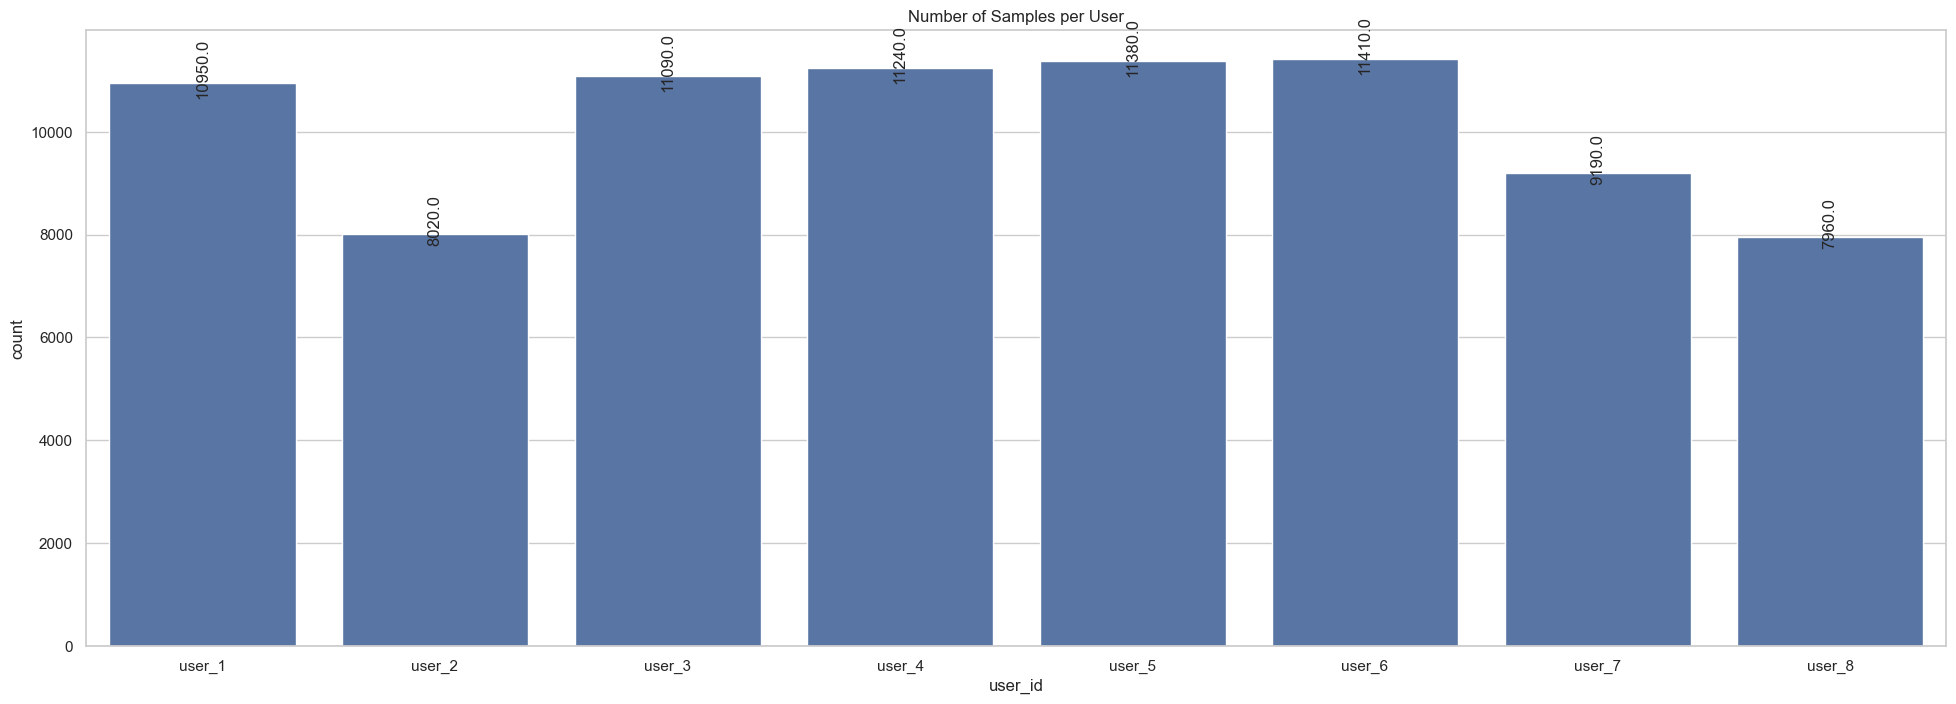

In [8]:
def run_participant_distribution_eda():
    """Run the participant distribution eda stage."""
    fig, ax1 = plt.subplots(1, 1, figsize=(24, 8))
    sns.countplot(data=Dataset_A, x='user_id', ax=ax1)
    ax1.set_title('Number of Samples per User')
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2.0, p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points', rotation=90)
run_participant_distribution_eda()


##### Did every user perform every activity?
---
User-level analysis is particularly important in human activity recognition because individuals exhibit unique movement patterns. To avoid data leakage and ensure generalizability, subject-independent evaluation methods such as leave-one-subject-out validation should be considered rather than random train-test splits.

activity   sit  stand  tug  walk
user_id                         
user_1    3420   3620  420  3490
user_2     260   3280  570  3910
user_3    4020   3790  460  2820
user_4    3460   3600  330  3850
user_5    3510   3530  320  4020
activity  sit  stand  tug  walk
user_id                        
user_1      1      1    1     1
user_2      1      1    1     1
user_3      1      1    1     1
user_4      1      1    1     1
user_5      1      1    1     1
user_6      1      1    1     1
user_7      1      1    0     1
user_8      1      1    1     0


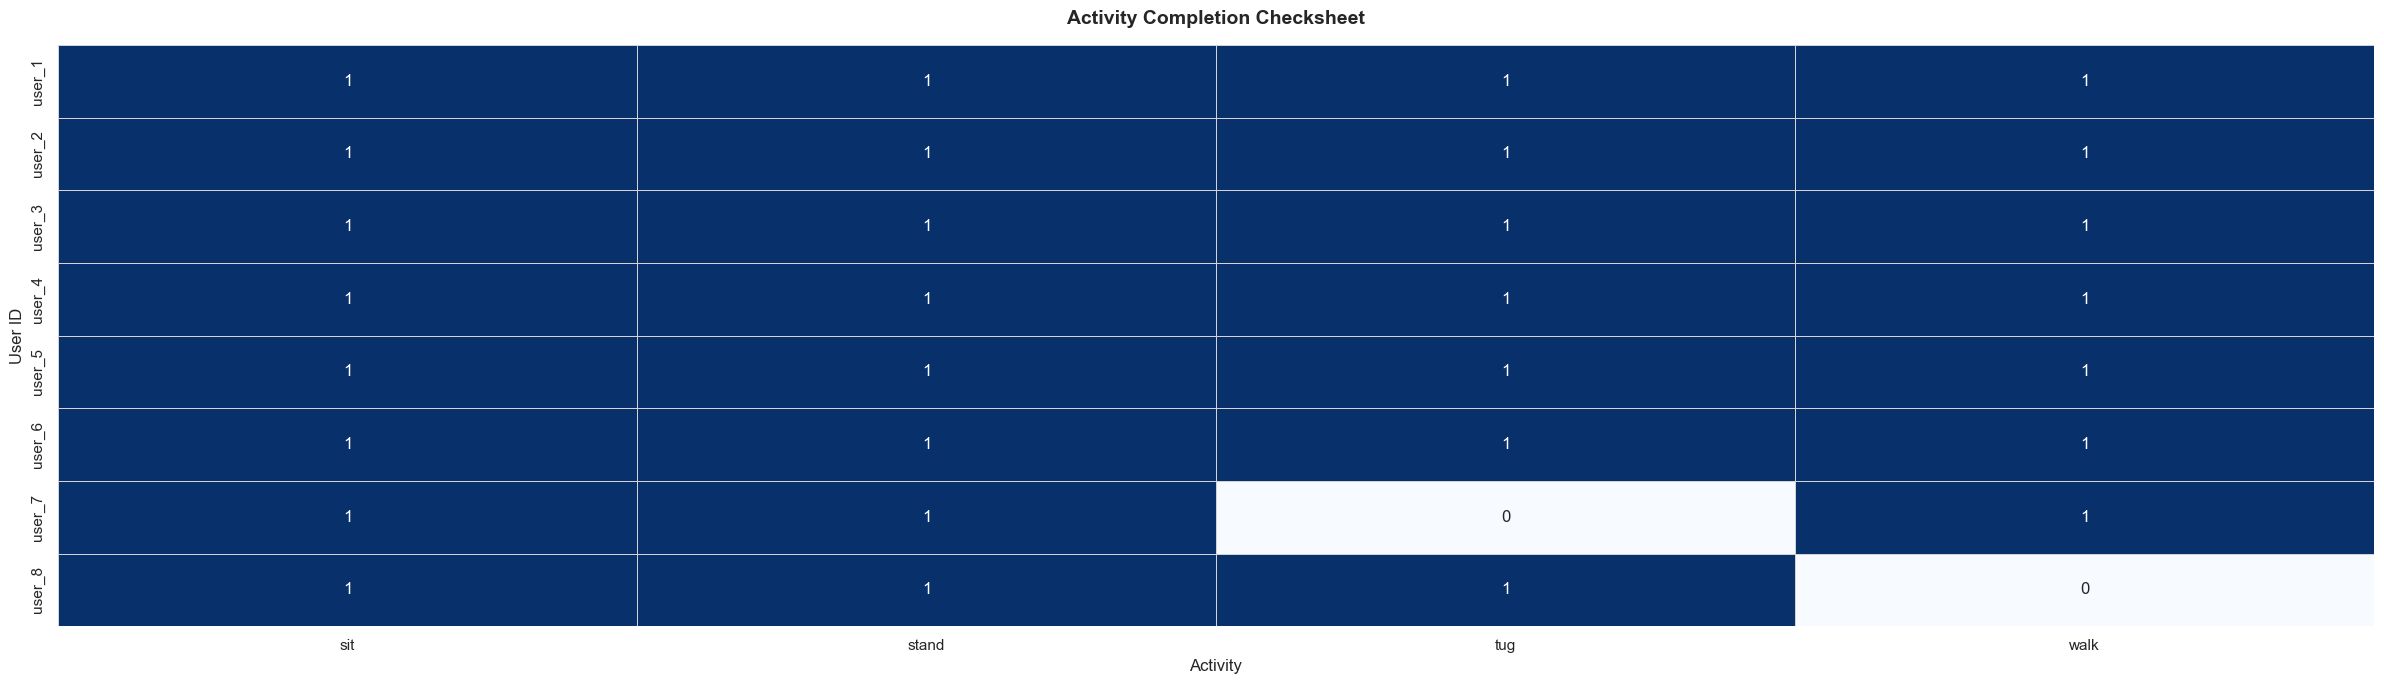

In [9]:
def run_activity_completion_check():
    """Run the activity completion check stage."""
    global check_list, completion_matrix
    check_list = pd.crosstab(Dataset_A['user_id'], Dataset_A['activity'])
    print(check_list.head())
    completion_matrix = (check_list > 0).astype(int)
    print(completion_matrix)
    plt.figure(figsize=(24, 7))
    sns.heatmap(completion_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, vmin=0, vmax=1, linewidths=0.5, linecolor='lightgray')
    plt.title('Activity Completion Checksheet', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('User ID', fontsize=12)
    plt.xlabel('Activity', fontsize=12)
    plt.tight_layout()
    plt.show()
run_activity_completion_check()


---
The completion matrix above is the source of truth for participant/activity coverage after synchronization quality control. Any missing activity for a participant is therefore treated as a data-availability issue rather than inferred from an earlier dataset.

This matters for evaluation because random window-level splitting could place highly related samples from the same participant in both training and test data. The modelling stage therefore uses participant-wise Leave-One-Subject-Out evaluation so that each test participant remains unseen during training.


## Time-Domain Comparison of Activities
---

Histogram-based EDA describes the distribution of individual sensor values, but Human Activity Recognition depends strongly on how those values change through time.

A time-domain visualisation is therefore used to compare short sections of sitting, standing, walking, and TUG data from one participant.

The horizontal axis is expressed in actual elapsed seconds rather than dataframe row number.

Accelerometer and gyroscope measurements are displayed separately because they represent different physical quantities.

The purpose of this analysis is descriptive. Differences visible for a single participant should not automatically be generalised to the entire population. Later subject-independent modelling is required to determine whether these patterns generalise across individuals.

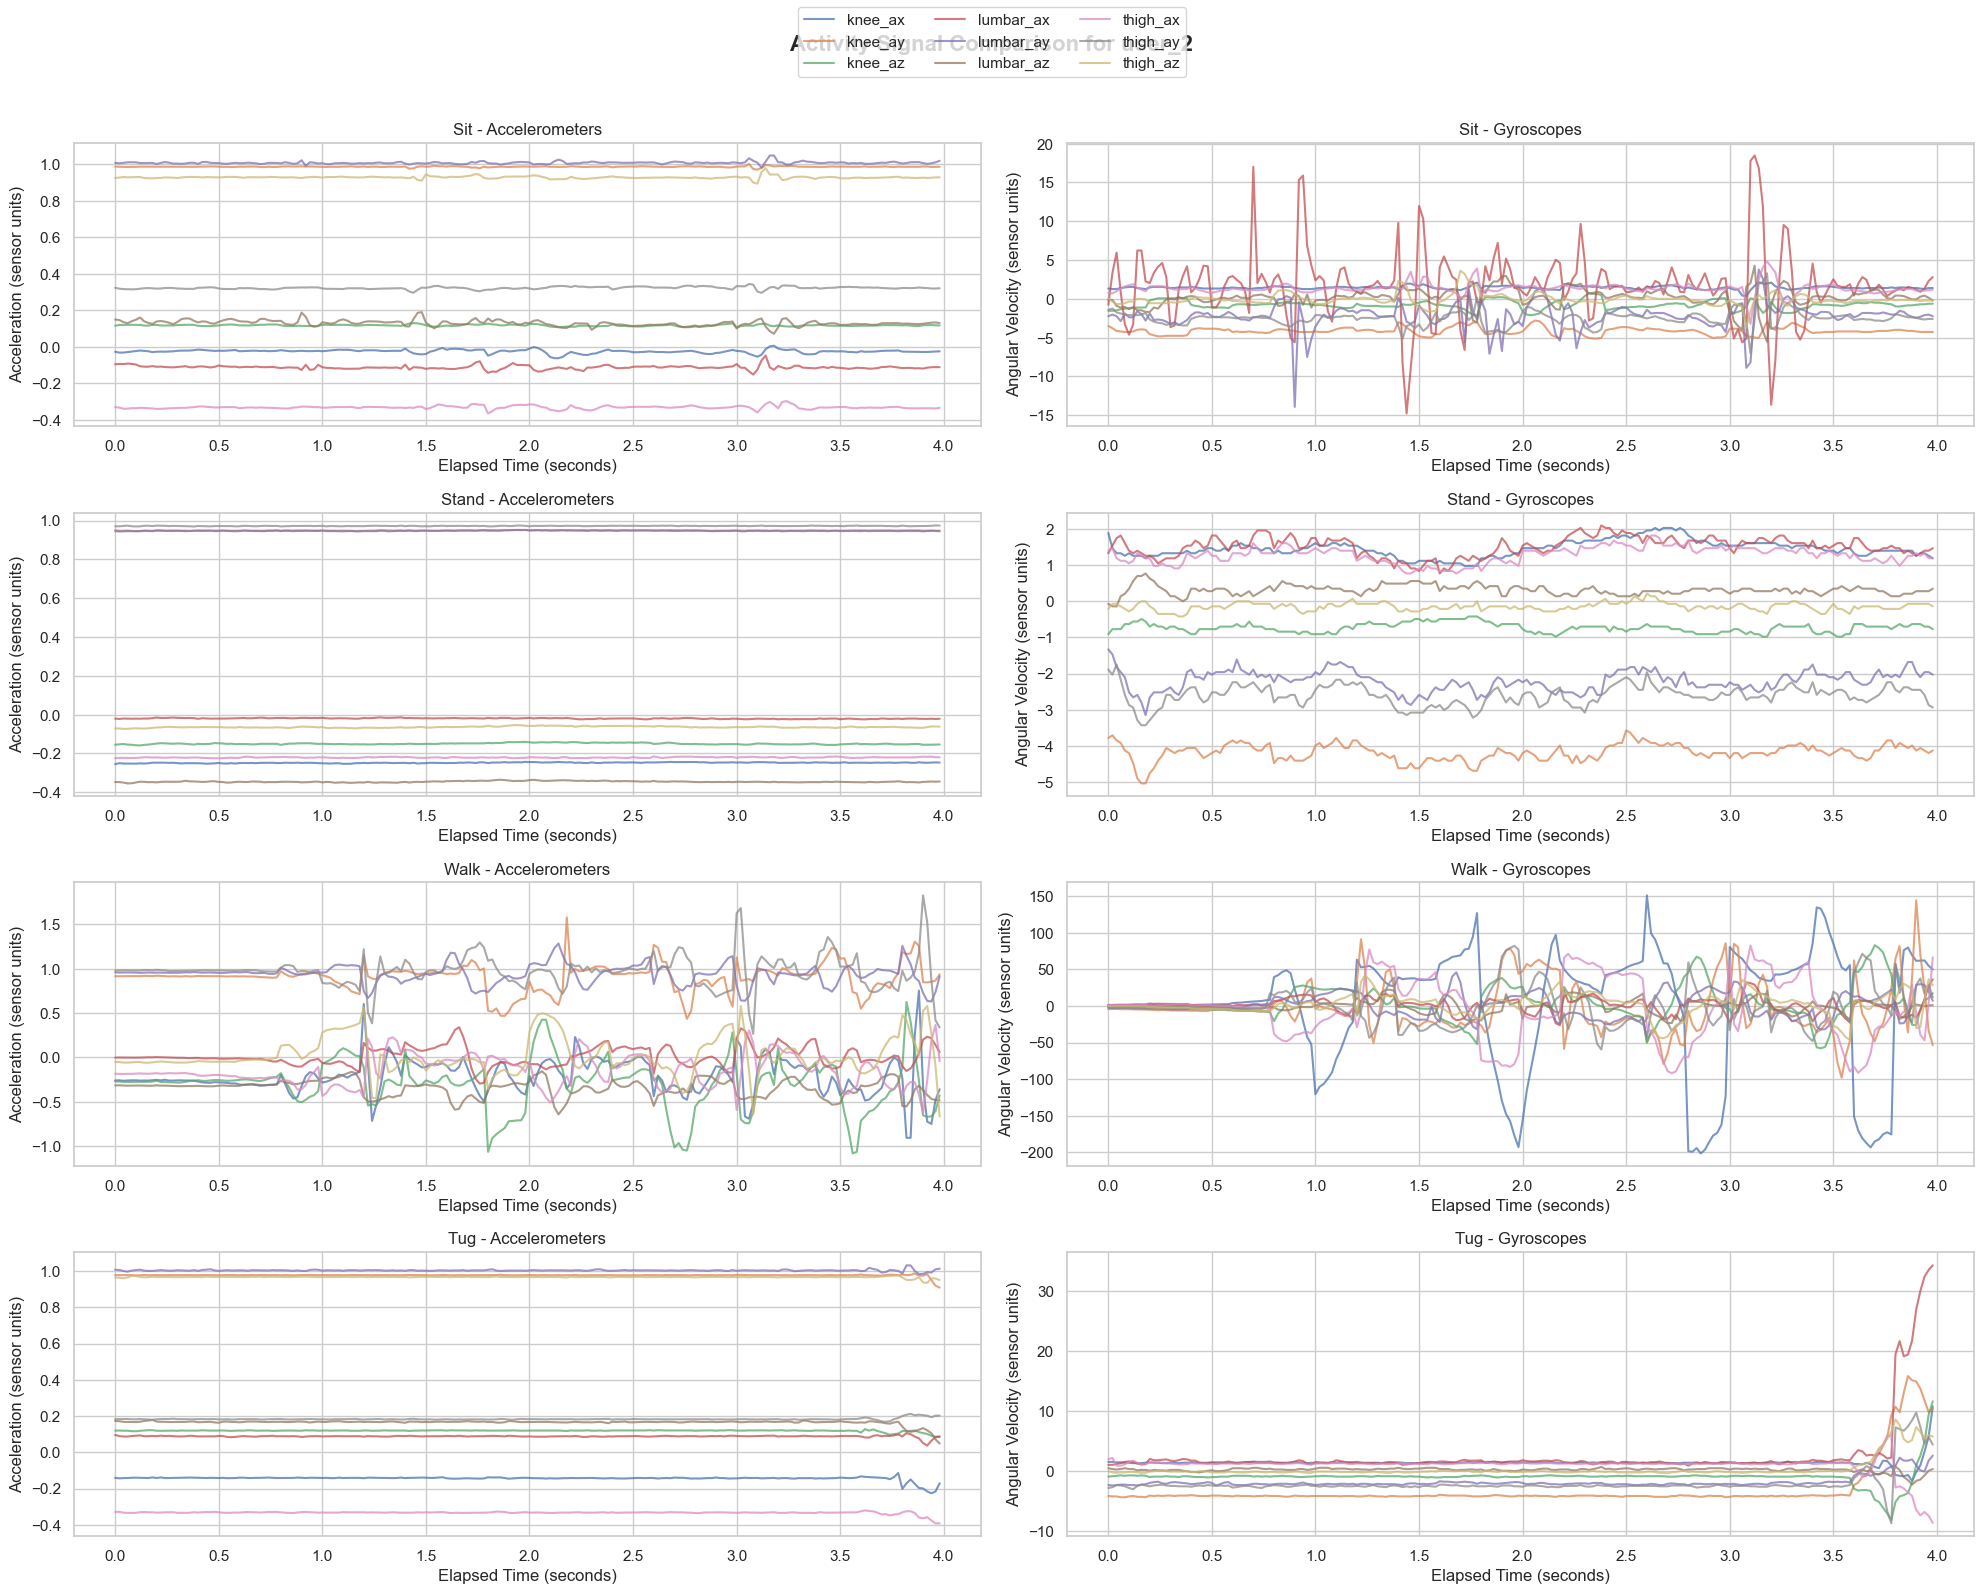

In [10]:
def get_activity_sample(dataframe, user_id, activity, duration_seconds=4.0):
    """
    Return a short chronological sample from one participant/activity session.
    """
    subset = dataframe[(dataframe['user_id'] == user_id) & (dataframe['activity'] == activity)].sort_values(['session_id', 'pc_timestamp']).copy()
    if subset.empty:
        return subset
    first_session = subset['session_id'].iloc[0]
    subset = subset[subset['session_id'] == first_session].copy()
    maximum_samples = int(duration_seconds * SAMPLING_RATE_HZ)
    return subset.head(maximum_samples).copy()

def elapsed_seconds(dataframe):
    """Return elapsed seconds from the first row of a chronological sample."""
    if dataframe.empty:
        return np.array([])
    return (dataframe['pc_timestamp'] - dataframe['pc_timestamp'].iloc[0]).dt.total_seconds().to_numpy()

def plot_activity_signal(dataframe, user_id, activities=('sit', 'stand', 'walk', 'tug'), duration_seconds=4.0):
    """
    Compare accelerometer and gyroscope signals across activities.
    """
    fig, axes = plt.subplots(nrows=len(activities), ncols=2, figsize=(20, 4 * len(activities)))
    for row_index, activity in enumerate(activities):
        sample = get_activity_sample(dataframe=dataframe, user_id=user_id, activity=activity, duration_seconds=duration_seconds)
        accel_axis = axes[row_index, 0]
        gyro_axis = axes[row_index, 1]
        if sample.empty:
            accel_axis.text(0.5, 0.5, 'No data available', ha='center', va='center')
            gyro_axis.text(0.5, 0.5, 'No data available', ha='center', va='center')
            continue
        time_axis = elapsed_seconds(sample)
        for column in ACCELEROMETER_COLUMNS:
            accel_axis.plot(time_axis, sample[column], label=column, alpha=0.75)
        accel_axis.set_title(f'{activity.capitalize()} - Accelerometers')
        accel_axis.set_xlabel('Elapsed Time (seconds)')
        accel_axis.set_ylabel('Acceleration (sensor units)')
        for column in GYROSCOPE_COLUMNS:
            gyro_axis.plot(time_axis, sample[column], label=column, alpha=0.75)
        gyro_axis.set_title(f'{activity.capitalize()} - Gyroscopes')
        gyro_axis.set_xlabel('Elapsed Time (seconds)')
        gyro_axis.set_ylabel('Angular Velocity (sensor units)')
    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', ncol=3)
    fig.suptitle(f'Activity Signal Comparison for {user_id}', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

def run_time_domain_eda():
    """Run the time domain eda stage."""
    plot_activity_signal(Dataset_A, user_id=SAMPLE_USER_ID)
run_time_domain_eda()


The time-domain plots show that the amplitude, variability, and temporal structure of the IMU signals differ across the recorded activities. Walking generally produces more periodic motion than sitting or standing, while TUG contains a mixture of movement phases.

These observations are descriptive rather than model conclusions. The later LOSO experiments are used to determine whether the patterns generalise to participants who were not seen during training.


---
# Data Preprocessing
---

The raw IMU signals contain both movement information and higher-frequency measurement noise. A low-pass Butterworth filter is therefore used as an offline denoising step.

The sensors are sampled at **50 Hz**, giving a Nyquist frequency of **25 Hz**. The notebook uses a **4 Hz** cutoff as an experimental preprocessing choice. Filtering is applied independently within each physical recording session so that the end of one recording cannot influence the beginning of another.


## Session-Safe Low-Pass Filtering
---

Human movement signals are generally concentrated in the lower-frequency
portion of wearable IMU measurements, while higher-frequency components may
contain sensor noise, vibration, and other unwanted components.

A fourth-order Butterworth low-pass filter with a 4 Hz cutoff is used as the
current experimental denoising configuration.

Because the sensors are sampled at 50 Hz, the Nyquist frequency is:

\[
f_N = \frac{50}{2} = 25\text{ Hz}
\]

The 4 Hz cutoff is therefore well below the Nyquist limit.

The cutoff should be treated as a preprocessing design choice rather than as an
assumption that all human movement occurs below exactly 4 Hz. Its suitability
can subsequently be assessed through model performance or sensitivity
analysis.

In [11]:
def run_filtering_pipeline():
    """Run the filtering pipeline stage."""
    global filter_sos, Dataset_A_unfiltered, Dataset_A_filtered, Dataset_A
    if not 0 < LOWPASS_CUTOFF_HZ < SAMPLING_RATE_HZ / 2:
        raise ValueError('The low-pass cutoff must lie between 0 Hz and the Nyquist frequency.')
    filter_sos = butter(N=FILTER_ORDER, Wn=LOWPASS_CUTOFF_HZ, btype='low', fs=SAMPLING_RATE_HZ, output='sos')
    Dataset_A_unfiltered = Dataset_A.copy()
    filtered_sessions = []
    for session_id, session_data in Dataset_A_unfiltered.groupby('session_id', sort=False):
        session_data = session_data.sort_values('pc_timestamp').copy()
        for column in MOTION_COLUMNS:
            try:
                session_data[column] = sosfiltfilt(filter_sos, session_data[column].to_numpy(dtype=float))
            except ValueError:
                print(f'Warning: session {session_id} was too short to filter column {column}.')
        filtered_sessions.append(session_data)
    Dataset_A_filtered = pd.concat(filtered_sessions, ignore_index=True).sort_values(['user_id', 'session_id', 'pc_timestamp']).reset_index(drop=True)
    Dataset_A = Dataset_A_filtered.copy()
    print('=' * 70)
    print('LOW-PASS FILTER SUMMARY')
    print('=' * 70)
    print(f'Sampling frequency : {SAMPLING_RATE_HZ} Hz')
    print(f'Nyquist frequency  : {SAMPLING_RATE_HZ / 2:.1f} Hz')
    print(f'Cutoff frequency   : {LOWPASS_CUTOFF_HZ:.1f} Hz')
    print(f'Filtered channels  : {len(MOTION_COLUMNS)}')
    print(f'Rows before        : {len(Dataset_A_unfiltered):,}')
    print(f'Rows after         : {len(Dataset_A):,}')
run_filtering_pipeline()


LOW-PASS FILTER SUMMARY
Sampling frequency : 50 Hz
Nyquist frequency  : 25.0 Hz
Cutoff frequency   : 4.0 Hz
Filtered channels  : 18
Rows before        : 81,240
Rows after         : 81,240


### Signal Check After Filtering

The same participant/activity plotting function is reused after filtering so the effect of denoising can be inspected without maintaining a second plotting implementation.


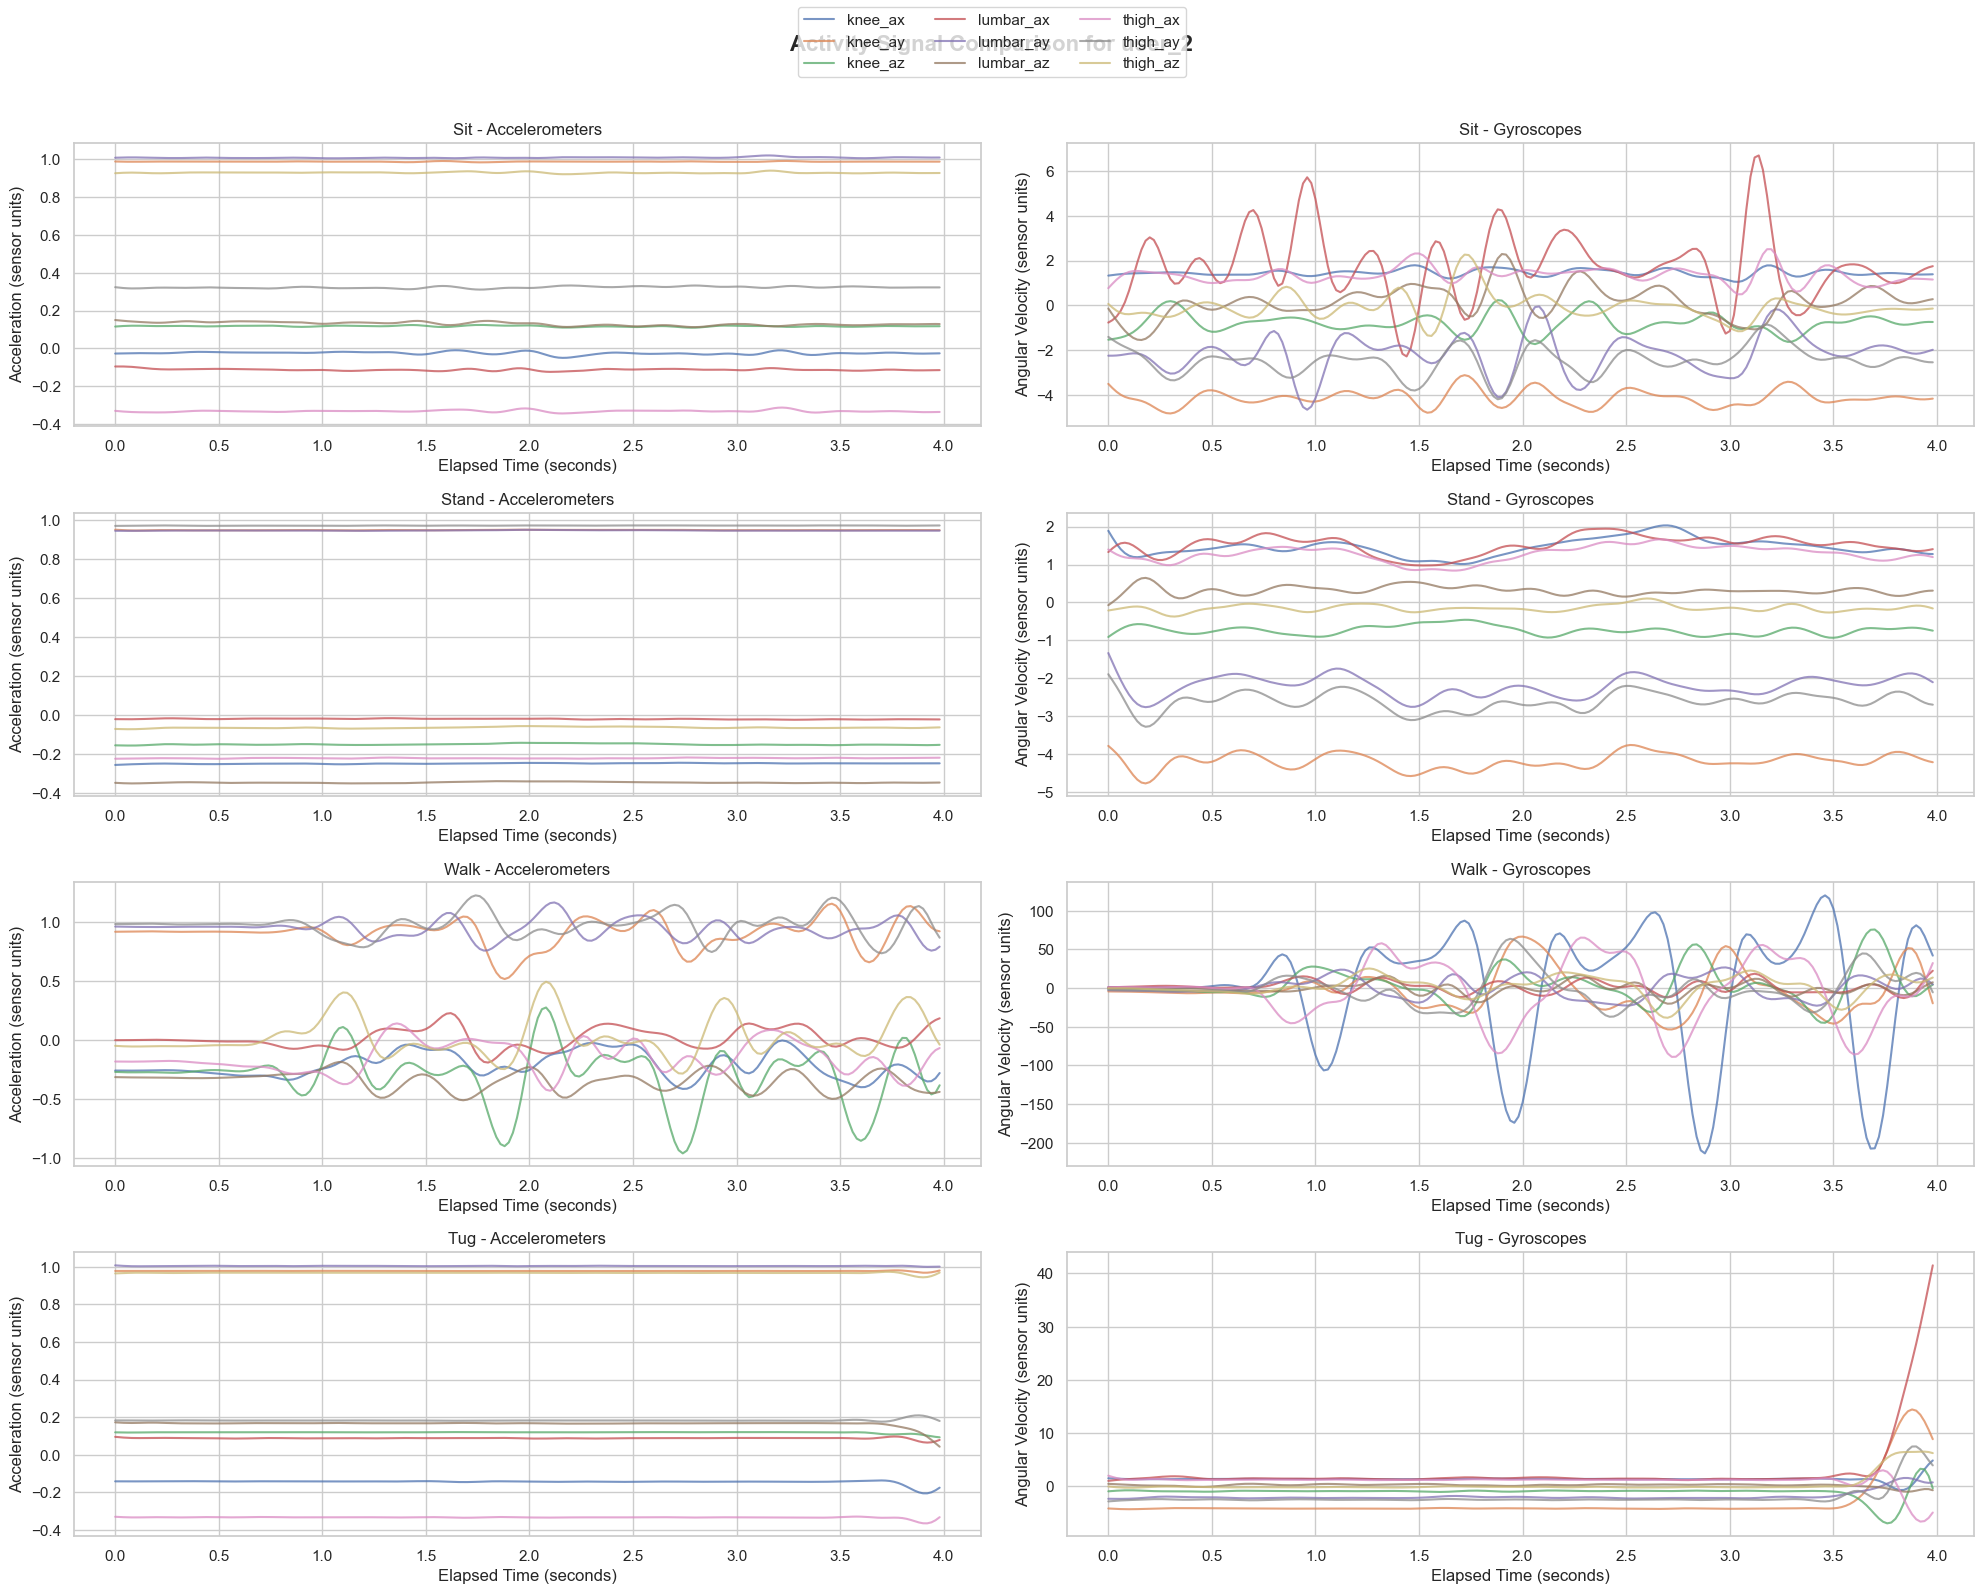

In [12]:
def run_filtered_signal_eda():
    """Reuse the activity time-series plot after low-pass filtering."""
    plot_activity_signal(
        Dataset_A,
        user_id=SAMPLE_USER_ID,
    )


run_filtered_signal_eda()


**Gyroscope values** 

## Separate Primitive HAR Activities from TUG Trials
---

Timed Up and Go is a composite mobility assessment rather than a single primitive activity equivalent to sitting, standing, or walking.

The Human Activity Recognition classifier will therefore use:

- Sit
- Stand
- Walk

However, TUG observations must not be deleted from the master dataset because they are required for the TUG and rehabilitation-analysis component.

The filtered synchronized dataset is therefore preserved as `Dataset_A_all`.

Two views are then created:

- `har_dataset_a`: primitive activities used for HAR classification.
- `tug_dataset_a`: complete TUG recordings retained for TUG-specific analysis.

This separation prevents TUG from becoming an ambiguous fourth HAR class while preserving the information required by the other objective of the project.

In [13]:
def run_activity_dataset_split():
    """Run the activity dataset split stage."""
    global Dataset_A_all, har_dataset_a, tug_dataset_a
    Dataset_A['activity'] = Dataset_A['activity'].astype(str).str.strip().str.lower()
    Dataset_A_all = Dataset_A.copy()
    har_dataset_a = Dataset_A_all[Dataset_A_all['activity'].isin(HAR_ACTIVITIES)].copy().reset_index(drop=True)
    tug_dataset_a = Dataset_A_all[Dataset_A_all['activity'] == 'tug'].copy().reset_index(drop=True)
    print('=' * 70)
    print('DATASET VIEWS')
    print('=' * 70)
    print(f'Complete dataset : {Dataset_A_all.shape}')
    print(f'HAR dataset      : {har_dataset_a.shape}')
    print(f'TUG dataset      : {tug_dataset_a.shape}')
    print('\nHAR classes:', sorted(har_dataset_a['activity'].unique()))
run_activity_dataset_split()


DATASET VIEWS
Complete dataset : (81240, 25)
HAR dataset      : (78430, 25)
TUG dataset      : (2810, 25)

HAR classes: ['sit', 'stand', 'walk']


## Session-Safe IMU Feature Engineering
---

Feature engineering converts the raw accelerometer and gyroscope measurements into additional motion descriptors.

All features are calculated within the physical `session_id` created during data ingestion. The ground-truth `activity` label is not used to define feature boundaries.

This is important because the model must eventually process an unknown activity. Using the true activity label to decide when derivatives or rolling calculations should reset would introduce target information into preprocessing.

The following accelerometer-derived features are calculated for each body location:

### Acceleration magnitude

\[
a_{mag} =
\sqrt{a_x^2 + a_y^2 + a_z^2}
\]

This measures total acceleration independent of individual axis direction.

### Approximate roll and pitch

Accelerometer-derived roll and pitch provide useful orientation information. During dynamic movement they should be interpreted as approximate tilt features because translational acceleration is also present.

### Jerk

\[
j_x =
\frac{\Delta a_x}{\Delta t}
\]

Jerk describes how rapidly acceleration changes.

The actual elapsed time between retained synchronized samples is used when calculating derivatives. This is preferable to blindly assuming that every adjacent retained row is exactly 20 ms apart because synchronization can occasionally remove a sample.

### Rolling acceleration descriptors

Rolling mean, variability, and squared-magnitude power describe local movement intensity over a two-second context window.

Gyroscope-derived features include:

- Angular-velocity magnitude
- Angular acceleration
- Rolling gyroscope mean and variability
- Rolling squared angular-velocity power
- Approximate short-window angular displacement

The complete filtered dataset is feature-engineered once. It is then separated into HAR and TUG feature datasets.

No global `dropna()` is performed. Any undefined first derivative is explicitly set to zero at the beginning of its recording session.

In [14]:
def prepare_feature_frame(dataframe):
    """Return a chronologically ordered copy and add per-row elapsed time."""
    data = (
        dataframe.copy()
        .sort_values(["user_id", "session_id", "pc_timestamp"])
        .reset_index(drop=True)
    )
    data["_dt_seconds"] = (
        data.groupby("session_id")["pc_timestamp"]
        .diff()
        .dt.total_seconds()
        .where(lambda values: values > 0)
        .fillna(DT)
    )
    return data


def grouped_derivative(data, column):
    """Calculate a session-safe first derivative for one signal column."""
    derivative = data.groupby("session_id")[column].diff() / data["_dt_seconds"]
    return derivative.replace([np.inf, -np.inf], np.nan).fillna(0.0)


def grouped_rolling_stat(data, series, operation, window_samples):
    """Apply a rolling statistic independently inside each physical session."""
    grouped = series.groupby(data["session_id"])

    def apply_stat(values):
        """Apply the requested rolling operation to one grouped series."""
        window = values.rolling(window=window_samples, min_periods=1)
        if operation == "mean":
            return window.mean()
        if operation == "std":
            return window.std(ddof=0)
        if operation == "sum":
            return window.sum()
        raise ValueError(f"Unsupported rolling operation: {operation}")

    return grouped.transform(apply_stat)


def add_accelerometer_features(data, node, window_samples):
    """Add magnitude, orientation, jerk and rolling acceleration features."""
    ax, ay, az = (f"{node}_{axis}" for axis in ("ax", "ay", "az"))
    acceleration_squared = data[ax] ** 2 + data[ay] ** 2 + data[az] ** 2

    created = []
    magnitude = f"{node}_accel_mag"
    data[magnitude] = np.sqrt(acceleration_squared)
    created.append(magnitude)

    roll = f"{node}_roll"
    pitch = f"{node}_pitch"
    data[roll] = np.degrees(np.arctan2(data[ay], data[az]))
    data[pitch] = np.degrees(
        np.arctan2(-data[ax], np.sqrt(data[ay] ** 2 + data[az] ** 2))
    )
    created.extend([roll, pitch])

    jerk_columns = []
    for axis_name, source in zip(("x", "y", "z"), (ax, ay, az)):
        target = f"{node}_jerk_{axis_name}"
        data[target] = grouped_derivative(data, source)
        jerk_columns.append(target)

    jerk_magnitude = f"{node}_jerk_mag"
    data[jerk_magnitude] = np.sqrt(sum(data[column] ** 2 for column in jerk_columns))
    created.extend(jerk_columns + [jerk_magnitude])

    mean_column = f"{node}_accel_mag_mean"
    std_column = f"{node}_accel_mag_std"
    power_column = f"{node}_accel_power"
    data[mean_column] = grouped_rolling_stat(data, data[magnitude], "mean", window_samples)
    data[std_column] = grouped_rolling_stat(data, data[magnitude], "std", window_samples)
    data[power_column] = grouped_rolling_stat(data, acceleration_squared, "mean", window_samples)
    created.extend([mean_column, std_column, power_column])
    return created


def add_gyroscope_features(data, node, window_samples):
    """Add angular magnitude, acceleration, variability, power and displacement."""
    gx, gy, gz = (f"{node}_{axis}" for axis in ("gx", "gy", "gz"))
    gyroscope_squared = data[gx] ** 2 + data[gy] ** 2 + data[gz] ** 2

    created = []
    magnitude = f"{node}_gyro_mag"
    data[magnitude] = np.sqrt(gyroscope_squared)
    created.append(magnitude)

    acceleration_columns = []
    for axis_name, source in zip(("x", "y", "z"), (gx, gy, gz)):
        target = f"{node}_ang_acc_{axis_name}"
        data[target] = grouped_derivative(data, source)
        acceleration_columns.append(target)
    created.extend(acceleration_columns)

    mean_column = f"{node}_gyro_mag_mean"
    std_column = f"{node}_gyro_mag_std"
    power_column = f"{node}_gyro_power"
    data[mean_column] = grouped_rolling_stat(data, data[magnitude], "mean", window_samples)
    data[std_column] = grouped_rolling_stat(data, data[magnitude], "std", window_samples)
    data[power_column] = grouped_rolling_stat(data, gyroscope_squared, "mean", window_samples)
    created.extend([mean_column, std_column, power_column])

    displacement_column = f"{node}_angle_disp_z"
    angular_increment = data[gz] * data["_dt_seconds"]
    data[displacement_column] = grouped_rolling_stat(
        data, angular_increment, "sum", window_samples
    )
    created.append(displacement_column)
    return created


def validate_node_channels(data, node):
    """Ensure all six raw channels exist for one body-mounted IMU."""
    required = [f"{node}_{channel}" for channel in SENSOR_CHANNELS]
    missing = [column for column in required if column not in data.columns]
    if missing:
        raise ValueError(f"{node} is missing columns: {missing}")


def engineer_imu_features(dataframe):
    """Add reusable session-safe features for every configured IMU node."""
    data = prepare_feature_frame(dataframe)
    window_samples = max(2, round(FEATURE_ROLLING_SECONDS * SAMPLING_RATE_HZ))
    engineered_columns = []

    for node in SENSOR_NODES:
        validate_node_channels(data, node)
        engineered_columns.extend(add_accelerometer_features(data, node, window_samples))
        engineered_columns.extend(add_gyroscope_features(data, node, window_samples))

    data[engineered_columns] = (
        data[engineered_columns]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )
    return data.drop(columns="_dt_seconds"), engineered_columns


def split_engineered_datasets(data):
    """Create the HAR and TUG analysis views from one engineered dataset."""
    har = (
        data[data["activity"].isin(HAR_ACTIVITIES)]
        .drop(columns=QUALITY_CONTROL_COLUMNS, errors="ignore")
        .reset_index(drop=True)
    )
    tug = data[data["activity"].eq("tug")].copy().reset_index(drop=True)
    return har, tug


def run_feature_engineering_pipeline():
    """Engineer all IMU features and create the HAR/TUG feature datasets."""
    global feature_engineered_all
    global feature_engineered_dataset_a
    global tug_feature_dataset_a
    global engineered_columns

    feature_engineered_all, engineered_columns = engineer_imu_features(Dataset_A_all)
    feature_engineered_dataset_a, tug_feature_dataset_a = split_engineered_datasets(
        feature_engineered_all
    )

    print_section("FEATURE ENGINEERING SUMMARY", 70)
    print(f"Complete engineered data : {feature_engineered_all.shape}")
    print(f"HAR engineered data      : {feature_engineered_dataset_a.shape}")
    print(f"TUG engineered data      : {tug_feature_dataset_a.shape}")
    return feature_engineered_dataset_a


feature_engineered_dataset_a = run_feature_engineering_pipeline()


FEATURE ENGINEERING SUMMARY
Complete engineered data : (81240, 79)
HAR engineered data      : (78430, 76)
TUG engineered data      : (2810, 79)


# Further Exploratory Data Analysis
---

### Recording Duration and TUG Descriptive Analysis
---

The dataset contains complete activity recordings, but it does not contain ground-truth annotations for the exact start and end of individual sit-to-stand movements.

A separate recording labelled `sit` followed by another recording labelled `stand` cannot automatically be interpreted as a continuously recorded sit-to-stand transition. The boundary between those files is an experimental recording boundary, not necessarily the physical start or end of the transition.

Consequently, exact sit-to-stand transition time is not estimated from the `sit` and `stand` recordings in this notebook.

Valid sit-to-stand duration measurement would require one of the following:

- A continuously recorded sit-to-stand trial
- TUG phase annotations
- Ground-truth event markers
- A separately validated transition-detection algorithm

The current data does, however, support valid recording-duration analysis.

Duration is calculated from reconstructed sample timestamps rather than simply dividing the number of retained rows by 50. Timestamp-based duration is preferable because synchronization may remove occasional samples.

Complete TUG trial duration can also be examined because each TUG recording represents an identifiable recorded trial. This should be described as **recorded TUG trial duration**, not yet as automatically segmented TUG phase timing.

ACTIVITY RECORDING DURATION SUMMARY


,activity,number_of_recordings,number_of_participants,mean_duration_seconds,median_duration_seconds,standard_deviation_seconds,minimum_duration_seconds,maximum_duration_seconds
0,sit,8,8,65.300,71.9,24.755,5.2,81.2
1,stand,8,8,69.825,71.3,4.999,59.6,75.8
2,tug,7,7,8.029,8.0,1.867,6.2,11.4
3,walk,7,7,69.657,75.8,11.848,50.0,80.4



RECORDED TUG TRIAL DURATIONS


,user_id,session_id,activity,number_of_samples,duration_seconds
0,user_1,user_1__tug,tug,420,8.4
1,user_2,user_2__tug,tug,570,11.4
2,user_3,user_3__tug,tug,460,9.2
3,user_4,user_4__tug,tug,330,6.6
4,user_5,user_5__tug,tug,320,6.4
5,user_6,user_6__tug,tug,400,8.0
6,user_8,user_8__tug,tug,310,6.2


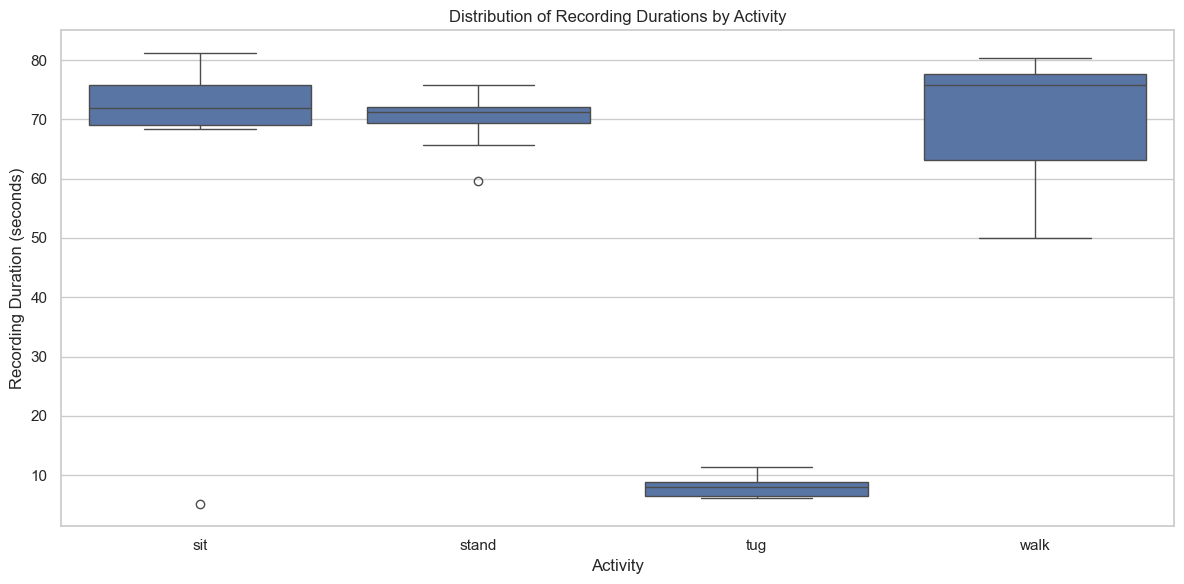

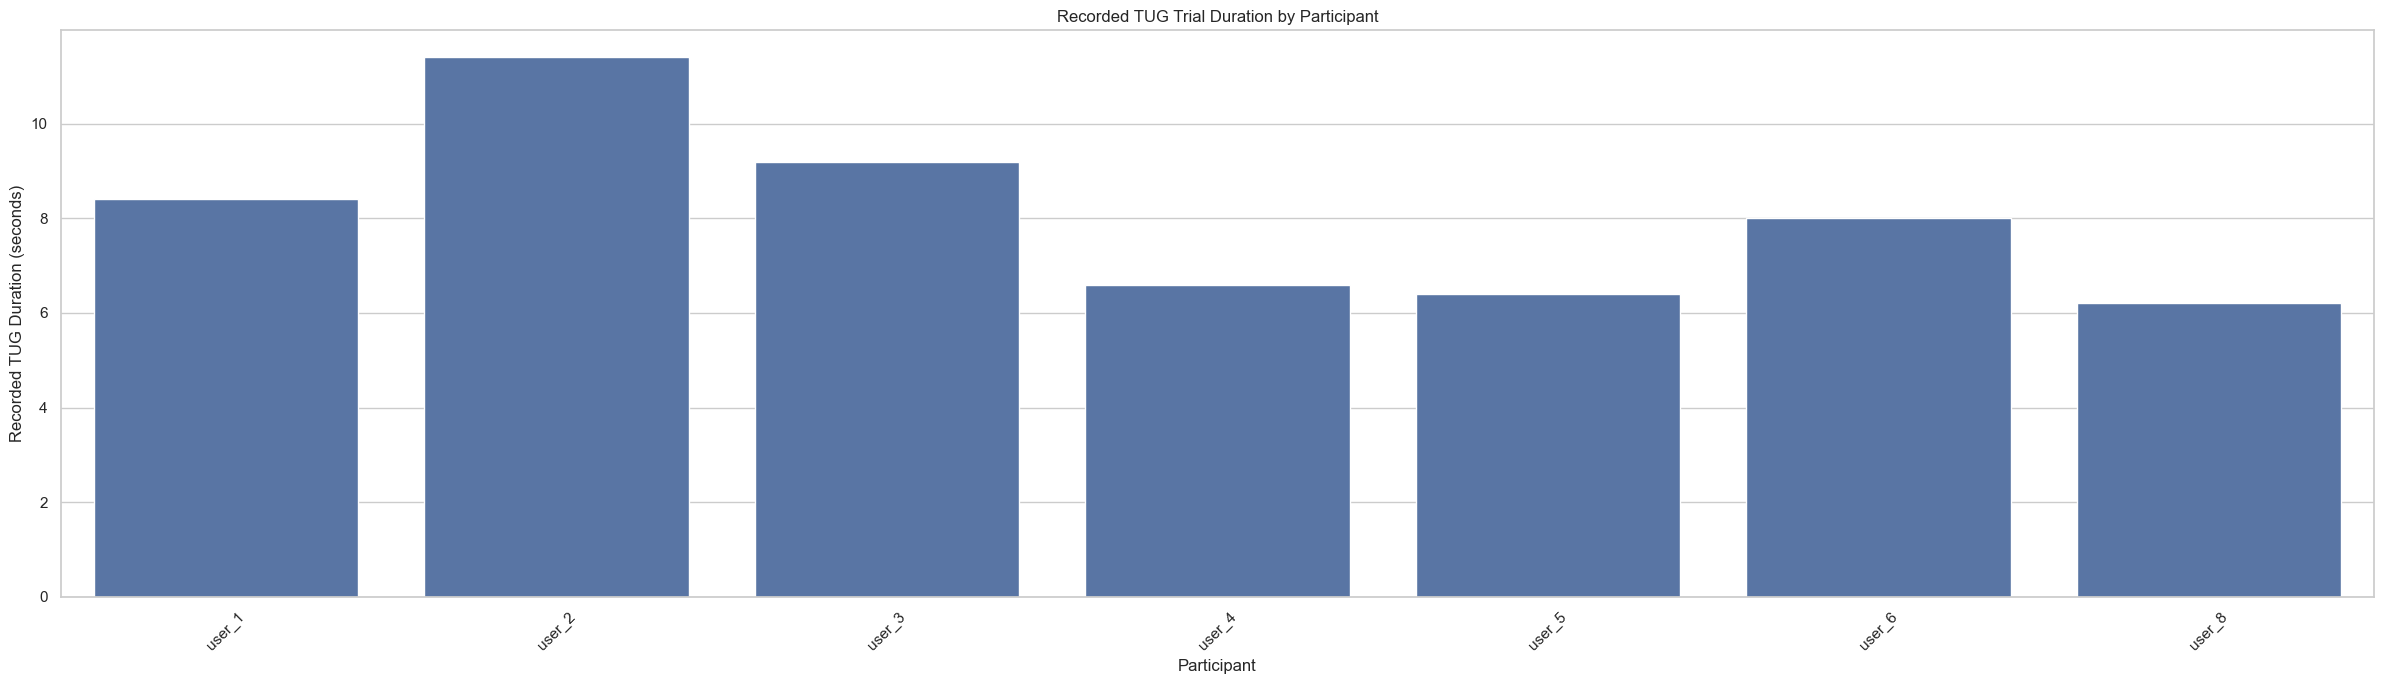

In [15]:
def calculate_recording_duration(dataframe):
    """
    Calculate recording duration from sample-level timestamps.
    """
    if dataframe.empty:
        return np.nan
    ordered = dataframe.sort_values('pc_timestamp')
    if len(ordered) == 1:
        return DT
    intervals = ordered['pc_timestamp'].diff().dt.total_seconds().dropna()
    positive_intervals = intervals[intervals > 0]
    estimated_final_interval = positive_intervals.median() if not positive_intervals.empty else DT
    return (ordered['pc_timestamp'].iloc[-1] - ordered['pc_timestamp'].iloc[0]).total_seconds() + estimated_final_interval

def run_duration_analysis():
    """Run the duration analysis stage."""
    global recording_duration_df, activity_duration_summary, tug_trial_summary
    recording_records = []
    for (user_id, session_id, activity), session_data in feature_engineered_all.groupby(['user_id', 'session_id', 'activity'], sort=False):
        recording_records.append({'user_id': user_id, 'session_id': session_id, 'activity': activity, 'number_of_samples': len(session_data), 'duration_seconds': calculate_recording_duration(session_data)})
    recording_duration_df = pd.DataFrame(recording_records)
    activity_duration_summary = recording_duration_df.groupby('activity', as_index=False).agg(number_of_recordings=('session_id', 'nunique'), number_of_participants=('user_id', 'nunique'), mean_duration_seconds=('duration_seconds', 'mean'), median_duration_seconds=('duration_seconds', 'median'), standard_deviation_seconds=('duration_seconds', 'std'), minimum_duration_seconds=('duration_seconds', 'min'), maximum_duration_seconds=('duration_seconds', 'max'))
    print('=' * 80)
    print('ACTIVITY RECORDING DURATION SUMMARY')
    print('=' * 80)
    display(activity_duration_summary.round(3))
    tug_trial_summary = recording_duration_df[recording_duration_df['activity'] == 'tug'].copy().reset_index(drop=True)
    print('\n' + '=' * 80)
    print('RECORDED TUG TRIAL DURATIONS')
    print('=' * 80)
    display(tug_trial_summary.round(3))
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=recording_duration_df, x='activity', y='duration_seconds')
    plt.title('Distribution of Recording Durations by Activity')
    plt.xlabel('Activity')
    plt.ylabel('Recording Duration (seconds)')
    plt.tight_layout()
    plt.show()
    if not tug_trial_summary.empty:
        plt.figure(figsize=(24, 7))
        sns.barplot(data=tug_trial_summary, x='user_id', y='duration_seconds')
        plt.title('Recorded TUG Trial Duration by Participant')
        plt.xlabel('Participant')
        plt.ylabel('Recorded TUG Duration (seconds)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
run_duration_analysis()


### Walking Step and Cadence Analysis


## Exploratory Walking Step and Cadence Estimation
---

Walking contains a quasi-periodic pattern that can be investigated using peaks in acceleration magnitude.

For every independent walking recording:

1. Knee acceleration magnitude is extracted.
2. The median is removed to centre the signal.
3. Candidate peaks are detected.
4. A minimum time between peaks prevents unrealistically close detections.
5. Peak prominence is scaled to the variability of the individual recording.

Each detected peak is treated as an **estimated gait event**.

This is an exploratory signal-processing estimate rather than validated ground-truth step counting. The peak detector should eventually be compared against manually counted steps or another reference method if step count becomes an evaluated outcome.

Cadence is calculated as:

\[
\text{Cadence}
=
\frac{\text{Detected Steps}}
{\text{Recording Duration}}
\times 60
\]

Cadence is more suitable for comparisons between participants than raw step count because the walking recordings may have different durations.

Walking distance is deliberately not calculated here because participant-specific stride or step length was not measured. Multiplying every person's step count by the same assumed distance could produce apparently precise but unsupported distance values.

EXPLORATORY WALKING RESULTS


,user_id,session_id,walking_duration_seconds,estimated_step_count,estimated_cadence_steps_per_minute,peak_prominence
0,user_1,user_1__walk,69.8,116,99.713,0.025
1,user_2,user_2__walk,78.2,146,112.020,0.040
2,user_3,user_3__walk,56.4,116,123.404,0.053
3,user_4,user_4__walk,77.0,148,115.325,0.078
4,user_5,user_5__walk,80.4,162,120.896,0.061
5,user_6,user_6__walk,75.8,134,106.069,0.037
6,user_7,user_7__walk,50.0,105,126.000,0.049


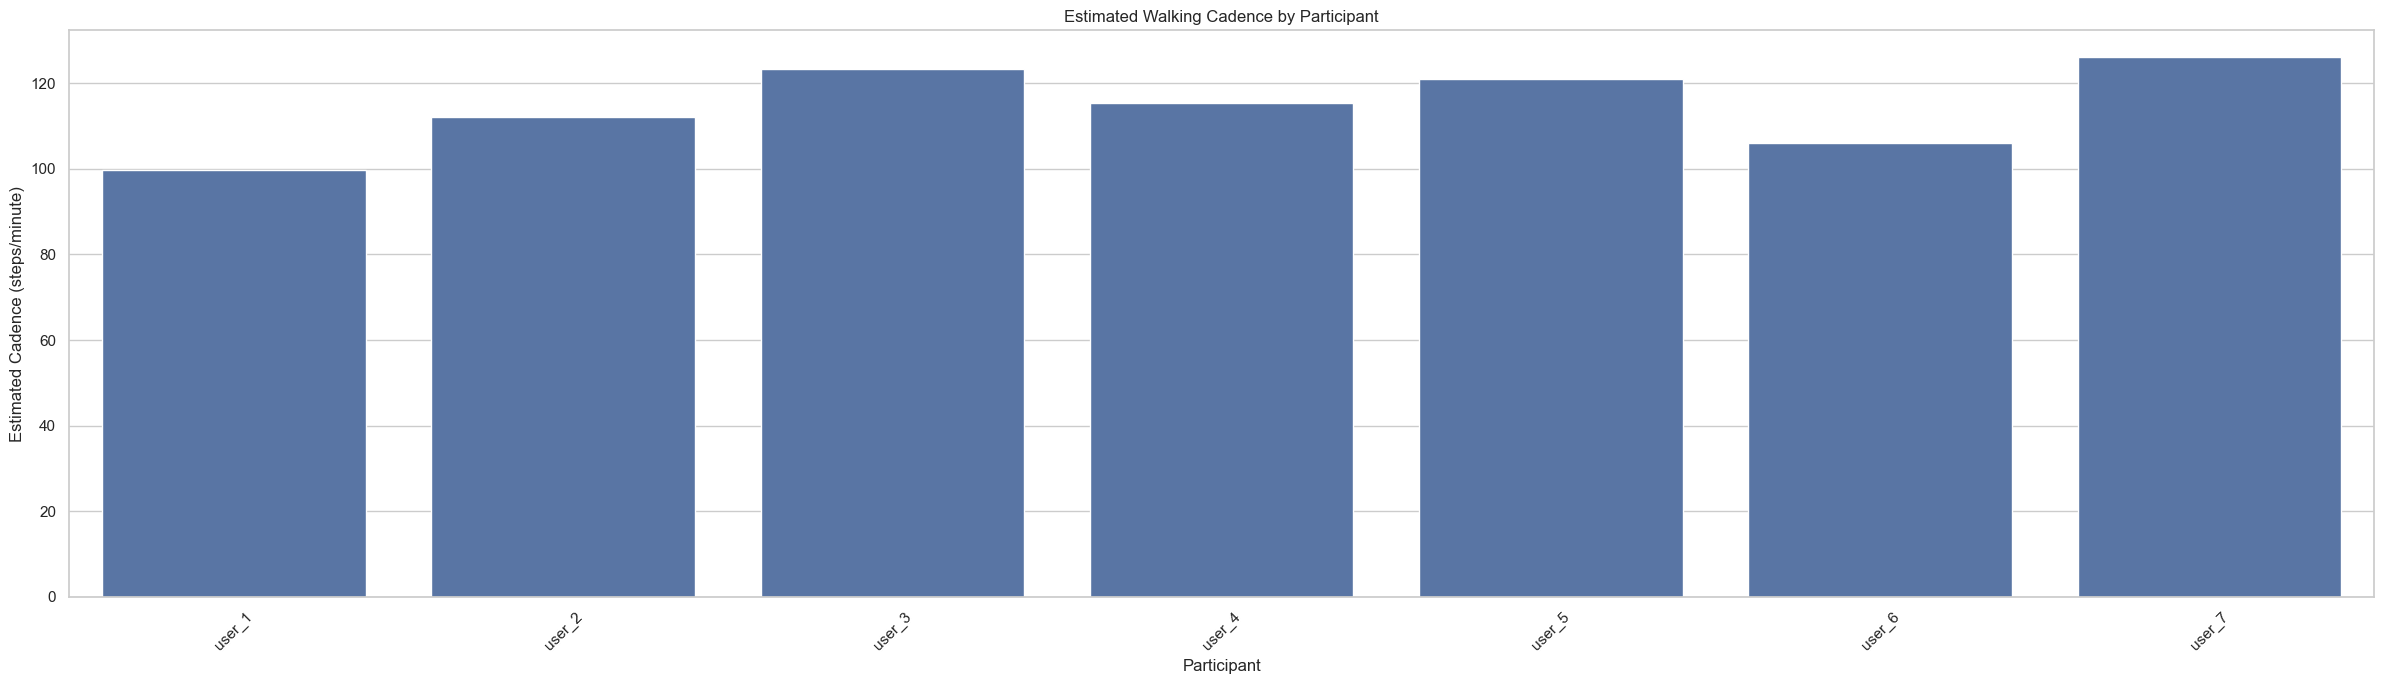

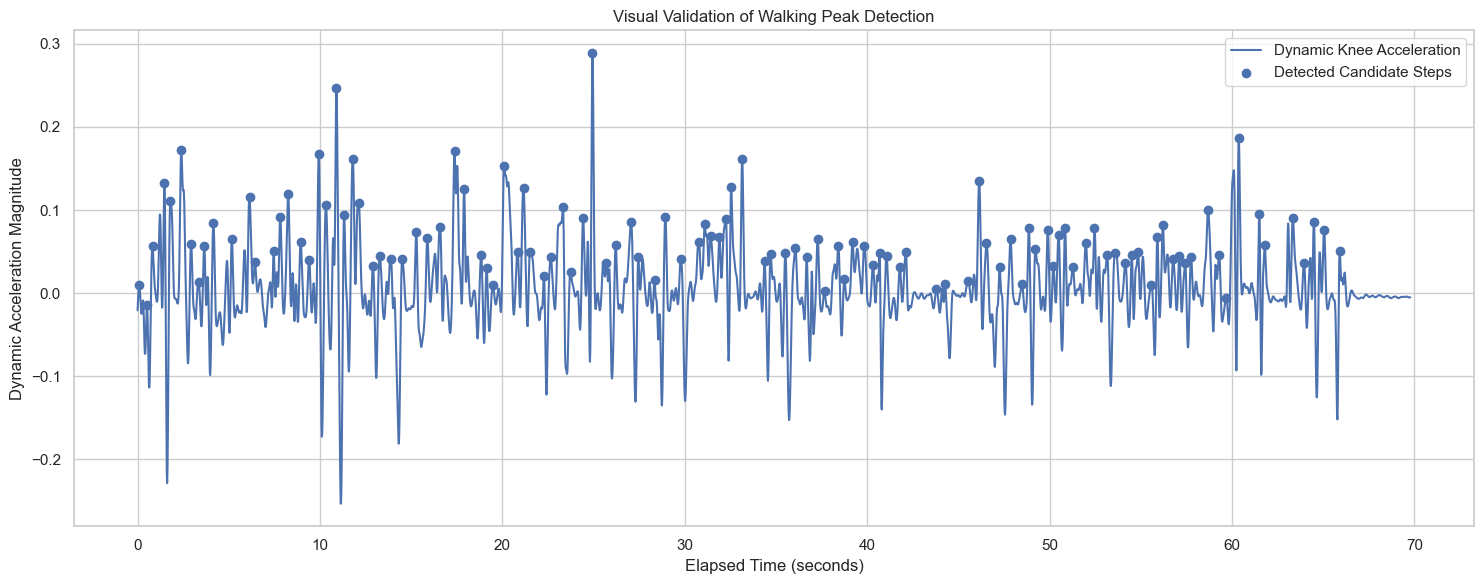

In [16]:
def get_minimum_peak_distance():
    """Return the minimum allowed number of samples between candidate steps."""
    return max(1, round(MIN_STEP_INTERVAL_SECONDS * SAMPLING_RATE_HZ))


def detect_walking_peaks(session):
    """Detect candidate steps from one walking session's knee acceleration magnitude."""
    signal = session["knee_accel_mag"].to_numpy(dtype=float)
    if len(signal) < 3:
        return np.array([], dtype=int), np.nan

    dynamic_signal = signal - np.median(signal)
    prominence = max(
        1e-6,
        STEP_PROMINENCE_MULTIPLIER * np.std(dynamic_signal),
    )
    peaks, _ = find_peaks(
        dynamic_signal,
        distance=get_minimum_peak_distance(),
        prominence=prominence,
    )
    return peaks, prominence


def summarise_walking_session(user_id, session_id, session):
    """Return step-count and cadence estimates for one walking recording."""
    peaks, prominence = detect_walking_peaks(session)
    duration = calculate_recording_duration(session)
    step_count = len(peaks)
    cadence = step_count / duration * 60 if duration > 0 else np.nan

    return {
        "user_id": user_id,
        "session_id": session_id,
        "walking_duration_seconds": duration,
        "estimated_step_count": step_count,
        "estimated_cadence_steps_per_minute": cadence,
        "peak_prominence": prominence,
    }, peaks


def analyse_walking_sessions(dataframe):
    """Analyse every walking session and return session and peak tables."""
    session_rows = []
    peak_rows = []

    for (user_id, session_id), session in dataframe.groupby(
        ["user_id", "session_id"],
        sort=False,
    ):
        session = session.sort_values("pc_timestamp").copy()
        summary, peaks = summarise_walking_session(user_id, session_id, session)
        session_rows.append(summary)

        row_indices = session.index.to_numpy()
        peak_rows.extend(
            {
                "user_id": user_id,
                "session_id": session_id,
                "dataset_index": row_indices[peak],
            }
            for peak in peaks
        )

    return pd.DataFrame(session_rows), pd.DataFrame(peak_rows)


def plot_walking_cadence(results):
    """Plot estimated cadence for each participant."""
    if results.empty:
        return
    plt.figure(figsize=(24, 7))
    sns.barplot(
        data=results,
        x="user_id",
        y="estimated_cadence_steps_per_minute",
    )
    plt.title("Estimated Walking Cadence by Participant")
    plt.xlabel("Participant")
    plt.ylabel("Estimated Cadence (steps/minute)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


def plot_example_walking_peaks(walking_data, results):
    """Plot detected candidate steps for the first analysed walking session."""
    if results.empty:
        return

    selected = results.iloc[0]
    session = walking_data[
        walking_data["user_id"].eq(selected["user_id"])
        & walking_data["session_id"].eq(selected["session_id"])
    ].sort_values("pc_timestamp")

    peaks, _ = detect_walking_peaks(session)
    signal = session["knee_accel_mag"].to_numpy(dtype=float)
    dynamic_signal = signal - np.median(signal)
    time_axis = elapsed_seconds(session)

    plt.figure(figsize=(15, 6))
    plt.plot(time_axis, dynamic_signal, label="Dynamic Knee Acceleration")
    plt.scatter(
        time_axis[peaks],
        dynamic_signal[peaks],
        label="Detected Candidate Steps",
        zorder=3,
    )
    plt.xlabel("Elapsed Time (seconds)")
    plt.ylabel("Dynamic Acceleration Magnitude")
    plt.title("Visual Validation of Walking Peak Detection")
    plt.legend()
    plt.tight_layout()
    plt.show()


def run_walking_cadence_analysis():
    """Run exploratory walking step and cadence analysis."""
    global walking_data, walking_session_results, walking_peak_results

    walking_data = feature_engineered_dataset_a[
        feature_engineered_dataset_a["activity"].eq("walk")
    ].copy()
    walking_session_results, walking_peak_results = analyse_walking_sessions(walking_data)

    print_section("EXPLORATORY WALKING RESULTS")
    display(walking_session_results.round(3))
    plot_walking_cadence(walking_session_results)
    plot_example_walking_peaks(walking_data, walking_session_results)
    return walking_session_results


walking_session_results = run_walking_cadence_analysis()


### Pre-Feature-Selection Data Integrity Check
---

Before feature selection begins, the processed HAR dataset is validated one final time.

This checkpoint ensures that problems introduced during synchronization, filtering, or feature engineering are detected before they propagate into model training.

The following conditions are verified:

1. All required raw IMU channels remain available.
2. Each `session_id` belongs to exactly one participant and one activity.
3. Samples are chronologically ordered inside every recording.
4. No NaN or infinite numerical values remain.
5. The HAR dataset contains only the intended primitive classes.
6. No target-derived `activity_encoded` predictor exists.
7. Synchronization quality-control variables have been removed from the HAR feature dataframe.

Passing these checks does not guarantee that every engineered feature will improve predictive performance. It establishes that the feature-selection stage starts from a structurally consistent dataset.

Participant identifiers and session identifiers remain in the dataframe as metadata because they are required for subject-independent splitting and window construction. They must not later be supplied to a classifier as predictor features.

In [17]:
def check_required_har_columns(dataframe):
    """Ensure all metadata and raw IMU columns required by modelling are present."""
    required = [*METADATA_COLUMNS, *MOTION_COLUMNS]
    missing = [column for column in required if column not in dataframe.columns]
    if missing:
        raise ValueError(f"Required HAR columns are missing: {missing}")


def check_target_leakage_columns(dataframe):
    """Reject target-derived or synchronization-QC columns from the HAR feature frame."""
    if "activity_encoded" in dataframe.columns:
        raise ValueError("'activity_encoded' must not exist inside the predictor dataframe.")

    unexpected_qc = [
        column for column in QUALITY_CONTROL_COLUMNS
        if column in dataframe.columns
    ]
    if unexpected_qc:
        raise ValueError(
            f"Synchronization QC columns remain inside the HAR dataframe: {unexpected_qc}"
        )


def check_numeric_values_are_finite(dataframe):
    """Ensure every numeric feature contains only finite values."""
    numeric = dataframe.select_dtypes(include=np.number).to_numpy()
    if not np.isfinite(numeric).all():
        raise ValueError("NaN or infinite values remain in numerical features.")


def check_session_consistency(dataframe):
    """Ensure each session belongs to exactly one participant and one activity."""
    activity_counts = dataframe.groupby("session_id")["activity"].nunique()
    user_counts = dataframe.groupby("session_id")["user_id"].nunique()

    if not activity_counts.eq(1).all():
        raise ValueError("One or more session IDs contain multiple activity labels.")
    if not user_counts.eq(1).all():
        raise ValueError("One or more session IDs contain multiple participants.")


def check_session_chronology(dataframe):
    """Ensure timestamps increase monotonically within every recording session."""
    chronological = dataframe.groupby("session_id")["pc_timestamp"].apply(
        lambda values: values.is_monotonic_increasing
    )
    if not chronological.all():
        bad_sessions = chronological[~chronological].index.tolist()
        raise ValueError(f"Chronological ordering failed for: {bad_sessions}")


def check_har_activity_set(dataframe):
    """Ensure the HAR frame contains only the configured primitive activities."""
    observed = set(dataframe["activity"].unique())
    unexpected = observed - set(HAR_ACTIVITIES)
    if unexpected:
        raise ValueError(f"Unexpected HAR activities found: {unexpected}")
    return observed


def run_pre_feature_selection_checks():
    """Run structural and leakage checks before feature selection."""
    check_required_har_columns(feature_engineered_dataset_a)
    check_target_leakage_columns(feature_engineered_dataset_a)
    check_numeric_values_are_finite(feature_engineered_dataset_a)
    check_session_consistency(feature_engineered_dataset_a)
    check_session_chronology(feature_engineered_dataset_a)
    observed = check_har_activity_set(feature_engineered_dataset_a)

    print_section("PRE-FEATURE-SELECTION INTEGRITY CHECK")
    print("✓ Required columns present")
    print("✓ No target-derived encoded column")
    print("✓ Synchronization QC columns excluded")
    print("✓ Numerical features are finite")
    print("✓ Sessions contain one activity each")
    print("✓ Sessions contain one participant each")
    print("✓ Samples are chronologically ordered")
    print("✓ HAR activities are valid")
    print(f"Rows: {len(feature_engineered_dataset_a):,}")
    print(f"Columns: {feature_engineered_dataset_a.shape[1]}")
    print(f"Participants: {feature_engineered_dataset_a['user_id'].nunique()}")
    print(f"Activities: {sorted(observed)}")
    display(
        pd.crosstab(
            feature_engineered_dataset_a["user_id"],
            feature_engineered_dataset_a["activity"],
        )
    )


run_pre_feature_selection_checks()


PRE-FEATURE-SELECTION INTEGRITY CHECK
✓ Required columns present
✓ No target-derived encoded column
✓ Synchronization QC columns excluded
✓ Numerical features are finite
✓ Sessions contain one activity each
✓ Sessions contain one participant each
✓ Samples are chronologically ordered
✓ HAR activities are valid
Rows: 78,430
Columns: 76
Participants: 8
Activities: ['sit', 'stand', 'walk']


activity,sit,stand,walk
user_id,,,
user_1,3420,3620,3490
user_2,260,3280,3910
user_3,4020,3790,2820
user_4,3460,3600,3850
user_5,3510,3530,4020
user_6,3680,3540,3790
user_7,3710,2980,2500
user_8,4060,3590,0


---
## Feature Selection
---
---

In [18]:
def run_feature_summary():
    """Run the feature summary stage."""
    feature_engineered_dataset_a.describe(include='all')
run_feature_summary()


 ---------------------------------------------->>>> ------>>> 
 ---------------------------------------------->>>> ------>>> 


,knee_ax,knee_ay,knee_az,knee_gx,knee_gy,knee_gz,lumbar_ax,lumbar_ay,lumbar_az,lumbar_gx,...,thigh_accel_mag_std,thigh_accel_power,thigh_gyro_mag,thigh_ang_acc_x,thigh_ang_acc_y,thigh_ang_acc_z,thigh_gyro_mag_mean,thigh_gyro_mag_std,thigh_gyro_power,thigh_angle_disp_z
knee_ax,1.000000,-0.508217,-0.008869,0.071445,0.003580,0.050698,0.169236,-0.055520,-0.235194,-0.010862,...,0.040542,0.201020,0.024845,-0.068307,0.069595,0.073994,0.042440,0.037018,0.067546,-0.021664
knee_ay,-0.508217,1.000000,-0.066417,0.051595,0.006011,0.027871,-0.165961,-0.113899,0.279143,0.002412,...,-0.011085,-0.405653,0.073208,-0.008424,0.017091,0.020298,0.074878,0.086388,0.055044,-0.120114
knee_az,-0.008869,-0.066417,1.000000,-0.074078,0.013855,-0.012776,-0.159874,0.116614,0.430906,-0.007045,...,-0.300601,0.311332,-0.317646,0.027675,-0.050970,-0.033556,-0.330445,-0.309428,-0.283677,-0.096362
knee_gx,0.071445,0.051595,-0.074078,1.000000,-0.217974,0.020053,0.011086,-0.004103,0.043160,0.058292,...,0.023651,0.033530,0.105369,0.023496,0.081451,0.101165,0.024615,0.025445,0.023176,0.021788
knee_gy,0.003580,0.006011,0.013855,-0.217974,1.000000,0.034825,-0.003594,-0.032244,-0.009571,-0.044522,...,-0.016787,-0.007571,-0.010025,-0.054786,0.020732,-0.018043,-0.012838,-0.014047,-0.005352,-0.148037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
thigh_ang_acc_z,0.073994,0.020298,-0.033556,0.101165,-0.018043,-0.180690,-0.006408,0.002654,0.005023,0.008432,...,-0.008502,0.000928,0.041970,-0.224044,0.198505,1.000000,-0.013856,-0.022415,-0.027993,-0.253106
thigh_gyro_mag_mean,0.042440,0.074878,-0.330445,0.024615,-0.012838,0.010325,0.239359,-0.095847,-0.435906,0.007506,...,0.917058,0.277983,0.846863,0.007058,-0.006936,-0.013856,1.000000,0.957491,0.967321,0.389170
thigh_gyro_mag_std,0.037018,0.086388,-0.309428,0.025445,-0.014047,0.000552,0.254560,-0.067548,-0.421759,0.009383,...,0.849364,0.207302,0.807662,0.006385,-0.015855,-0.022415,0.957491,1.000000,0.956654,0.427029
thigh_gyro_power,0.067546,0.055044,-0.283677,0.023176,-0.005352,-0.000487,0.243373,-0.122286,-0.389028,0.012737,...,0.855621,0.285360,0.807412,0.014764,-0.017916,-0.027993,0.967321,0.956654,1.000000,0.412416


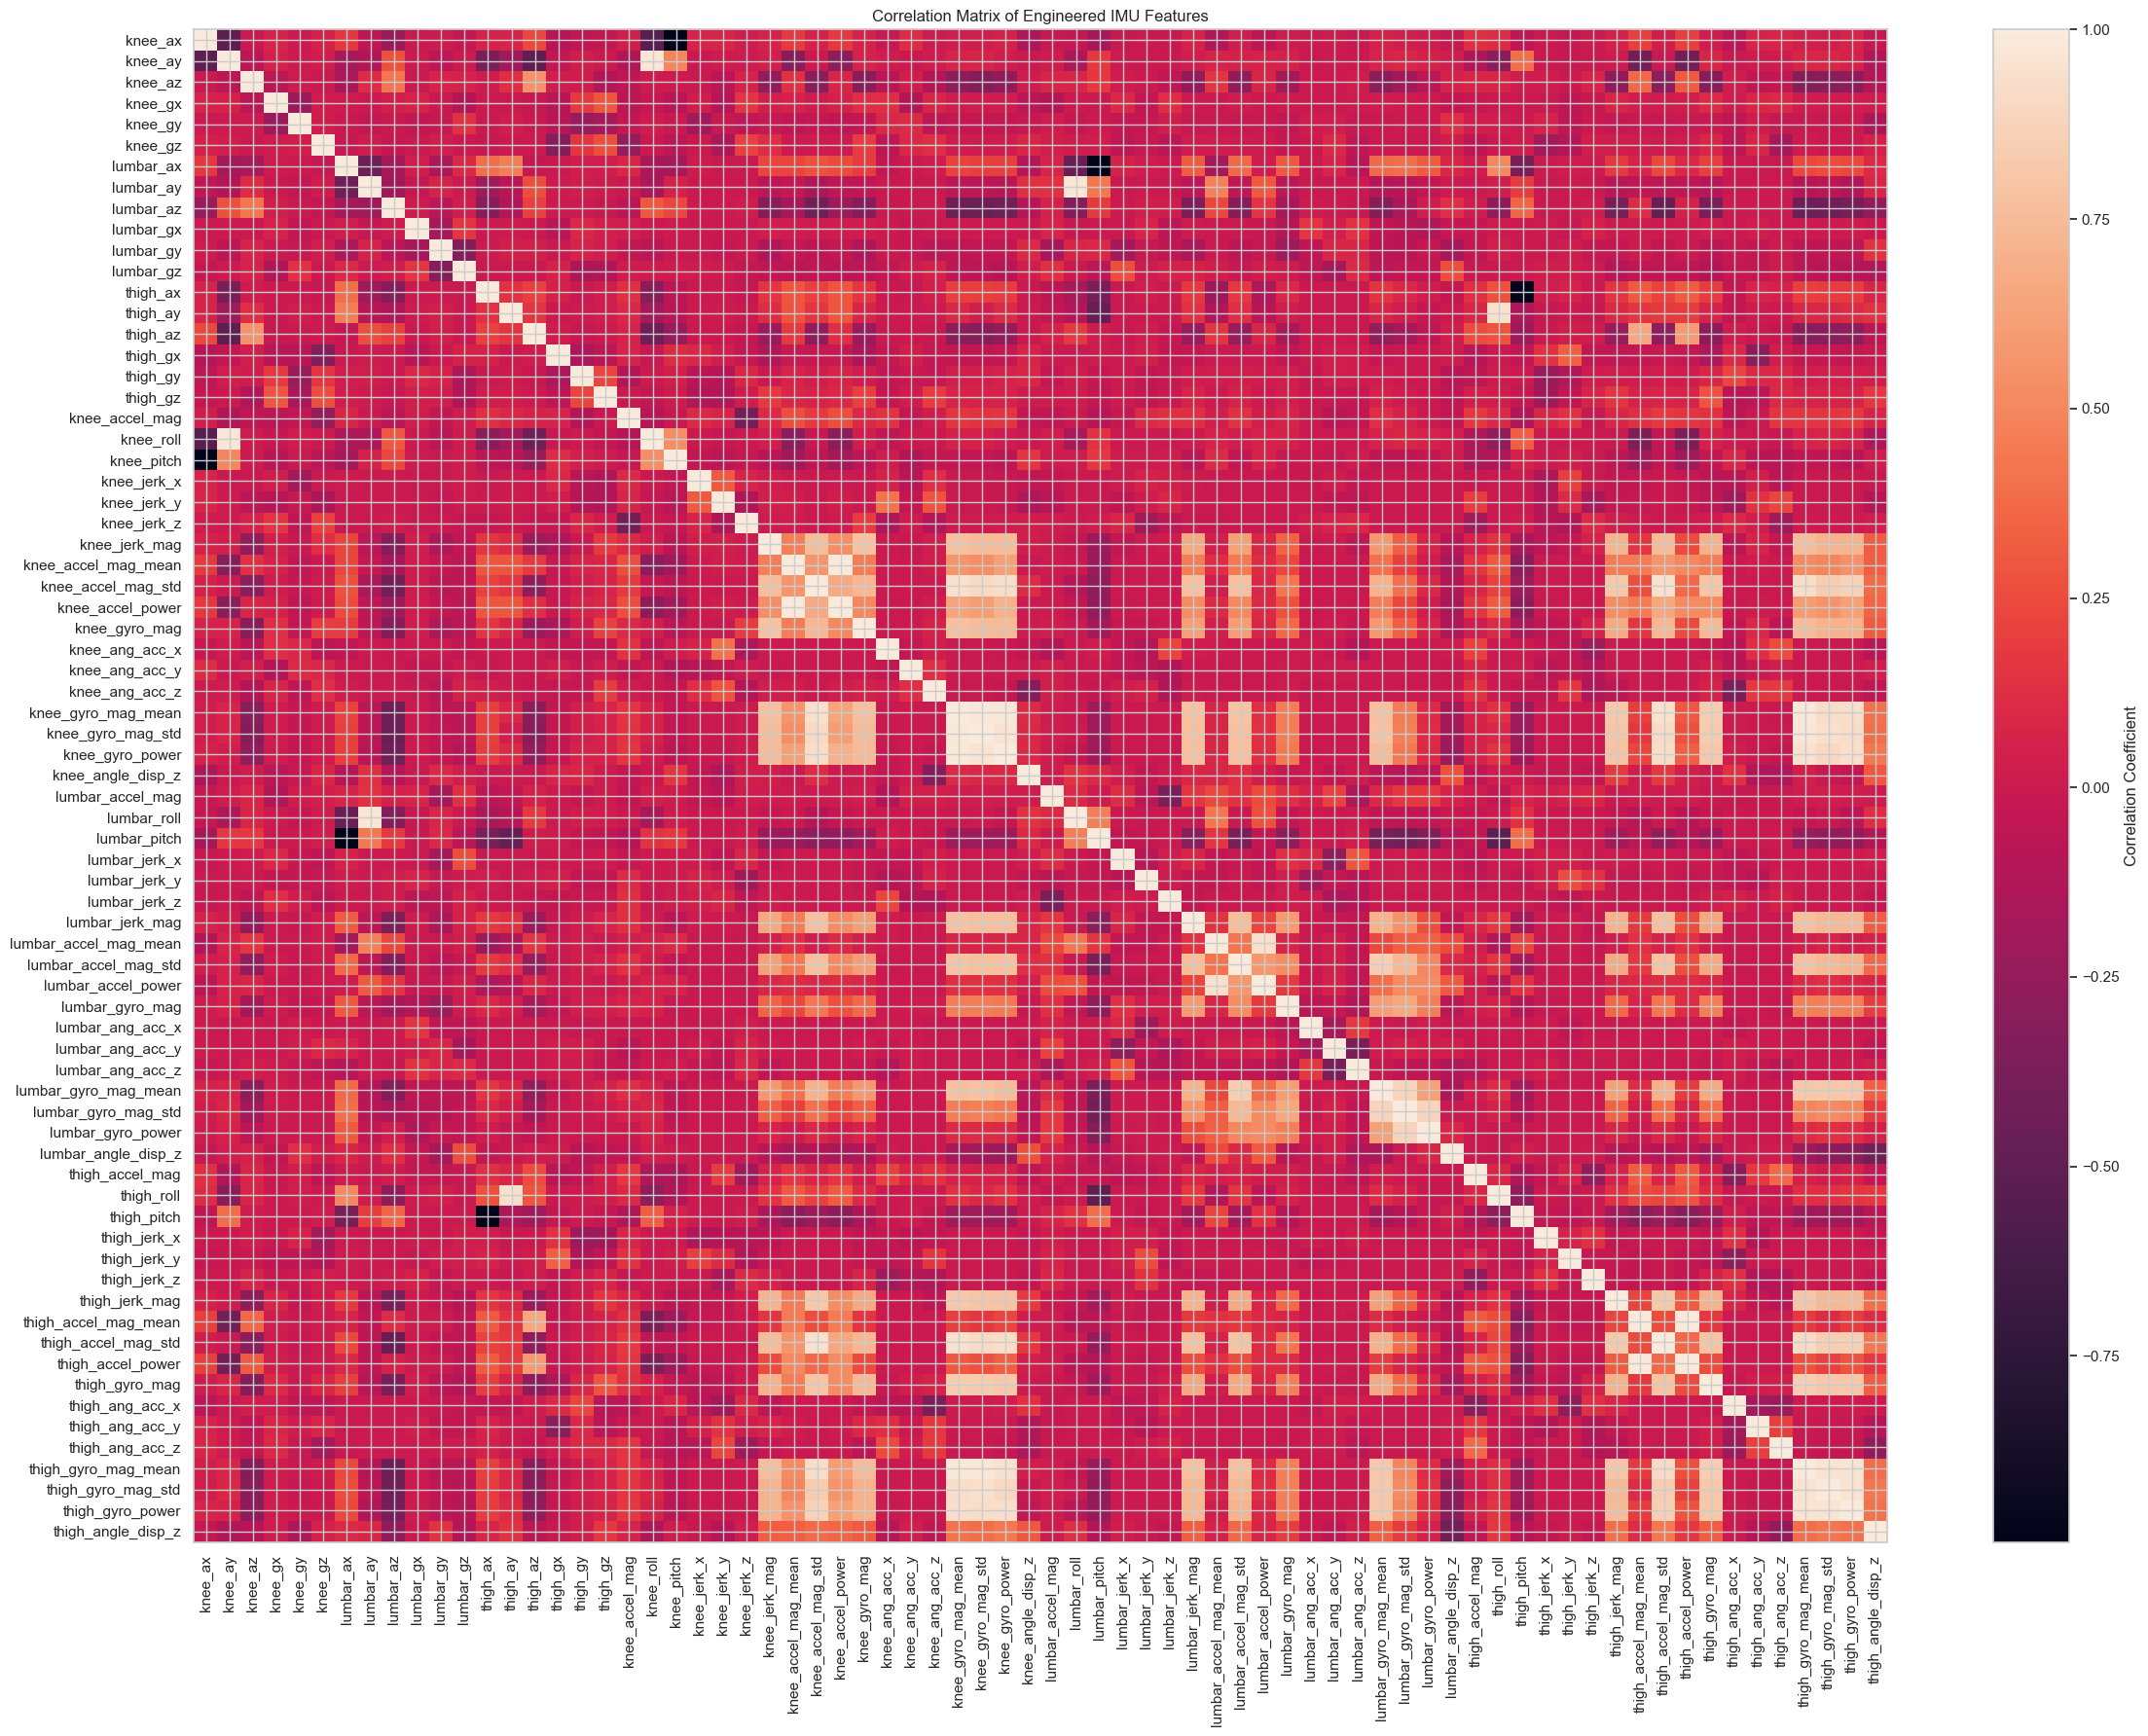

HIGHLY CORRELATED FEATURE PAIRS (|r| >= 0.9)


,feature_1,feature_2,correlation,absolute_correlation
0,knee_ax,knee_pitch,-0.995596,0.995596
1,thigh_accel_mag_mean,thigh_accel_power,0.991258,0.991258
2,thigh_ax,thigh_pitch,-0.990320,0.990320
3,knee_accel_mag_mean,knee_accel_power,0.989965,0.989965
4,lumbar_ax,lumbar_pitch,-0.988186,0.988186
5,knee_gyro_mag_mean,knee_gyro_mag_std,0.983732,0.983732
6,knee_gyro_mag_mean,knee_gyro_power,0.982413,0.982413
7,knee_gyro_mag_mean,thigh_gyro_mag_mean,0.979404,0.979404
8,knee_ay,knee_roll,0.975319,0.975319
9,knee_gyro_mag_std,thigh_gyro_mag_mean,0.974602,0.974602


In [19]:
def run_correlation_analysis():
    """Run the correlation analysis stage."""
    global correlation_features, correlation_matrix, highly_correlated_features
    correlation_features = feature_engineered_dataset_a.select_dtypes(include=np.number).copy()
    print(' ---------------------------------------------->>>> ------>>> ')
    correlation_features.head()
    print(' ---------------------------------------------->>>> ------>>> ')
    correlation_matrix = correlation_features.corr()
    display(correlation_matrix)
    plt.figure(figsize=(24, 18))
    plt.imshow(correlation_matrix, aspect='auto')
    plt.colorbar(label='Correlation Coefficient')
    plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
    plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
    plt.title('Correlation Matrix of Engineered IMU Features')
    plt.tight_layout()
    plt.show()
    highly_correlated_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            correlation_value = correlation_matrix.iloc[i, j]
            if abs(correlation_value) >= CORRELATION_THRESHOLD:
                highly_correlated_pairs.append({'feature_1': correlation_matrix.columns[i], 'feature_2': correlation_matrix.columns[j], 'correlation': correlation_value, 'absolute_correlation': abs(correlation_value)})
    highly_correlated_features = pd.DataFrame(highly_correlated_pairs)
    if not highly_correlated_features.empty:
        highly_correlated_features = highly_correlated_features.sort_values(by='absolute_correlation', ascending=False).reset_index(drop=True)
    print('=' * 80)
    print(f'HIGHLY CORRELATED FEATURE PAIRS (|r| >= {CORRELATION_THRESHOLD})')
    print('=' * 80)
    if highly_correlated_features.empty:
        print('No highly correlated feature pairs were identified.')
    else:
        display(highly_correlated_features)
run_correlation_analysis()


### Remove Redundant Highly Correlated Features

Highly correlated variables contain very similar information. Retaining both variables in a highly correlated pair can unnecessarily increase dimensionality, model complexity, computation time, and the risk of overfitting.

The preceding correlation analysis identified pairs of numerical features with an absolute Pearson correlation coefficient greater than or equal to the selected correlation threshold. For each pair, the second feature is removed.

A separate copy of the feature-engineered dataset is created rather than modifying the original dataframe in place. This preserves the original processed data and makes the modelling pipeline reproducible.

It is important to distinguish correlation-based feature removal from metadata removal. Columns such as `user_id`, `session_id`, `pc_timestamp`, and `activity` are required temporarily for grouping, chronological ordering, LOSO splitting, and target construction. They are therefore retained at this stage but will never be passed to a classifier as predictor variables.

In [20]:
def run_redundant_feature_reduction():
    """Run the redundant feature reduction stage."""
    global columns_to_drop, har_data
    if 'feature_2' in highly_correlated_features.columns and (not highly_correlated_features.empty):
        columns_to_drop = sorted(set(highly_correlated_features['feature_2'].dropna().tolist()))
    else:
        columns_to_drop = []
    har_data = feature_engineered_dataset_a.drop(columns=columns_to_drop, errors='ignore').copy()
    print('=' * 70)
    print('CORRELATION-BASED FEATURE REDUCTION')
    print('=' * 70)
    print(f'Columns before reduction: {feature_engineered_dataset_a.shape[1]}')
    print(f'Highly correlated columns removed: {len(columns_to_drop)}')
    print(f'Columns after reduction: {har_data.shape[1]}')
    if columns_to_drop:
        print('\nRemoved columns:')
        for column in columns_to_drop:
            print(f' - {column}')
    else:
        print('\nNo highly correlated columns were removed.')
run_redundant_feature_reduction()


CORRELATION-BASED FEATURE REDUCTION
Columns before reduction: 76
Highly correlated columns removed: 16
Columns after reduction: 60

Removed columns:
 - knee_accel_power
 - knee_gyro_mag_mean
 - knee_gyro_mag_std
 - knee_gyro_power
 - knee_pitch
 - knee_roll
 - lumbar_accel_power
 - lumbar_pitch
 - lumbar_roll
 - thigh_accel_mag_std
 - thigh_accel_power
 - thigh_gyro_mag_mean
 - thigh_gyro_mag_std
 - thigh_gyro_power
 - thigh_pitch
 - thigh_roll


### Prepare the Dataset for Human Activity Recognition
---

The classification experiment uses synchronized accelerometer and gyroscope measurements from three body locations:

- Knee
- Lumbar
- Thigh

Each IMU contributes six raw motion channels:

- `ax`, `ay`, `az`: accelerometer measurements
- `gx`, `gy`, `gz`: gyroscope measurements

This gives a total of 18 raw IMU channels.

The classifiers deliberately do not receive metadata or target-related columns. In particular:

- `user_id` identifies the participant and is retained only for Leave-One-Subject-Out evaluation.
- `session_id` identifies recording sessions and is used only to prevent windows from crossing session boundaries.
- `pc_timestamp` is used only to preserve chronological ordering.
- `activity` is the ground-truth target and must never appear among the predictor variables.
- `activity_encoded` is not created inside the dataframe because doing so creates an unnecessary target-derived column.
- RSSI, Arduino timestamps, sensor-position labels, and duplicated per-sensor activity labels are not useful motion predictors and should not be included.

For the activity classifier, the same 18 raw IMU channels are used as the underlying sensor information for all four algorithms. This makes the comparison between Random Forest, CNN, LSTM, and Conv-LSTM substantially easier to interpret.

The sensor sampling rate is 50 Hz. A two-second window therefore contains 100 samples. Consecutive windows overlap by 50%, so the window advances by 50 samples, or one second, at a time.

In [21]:
def run_har_data_preparation():
    """Run the har data preparation stage."""
    global har_data, har_model_data
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    tf.keras.utils.set_random_seed(RANDOM_SEED)
    har_data['activity'] = har_data['activity'].astype(str).str.strip().str.lower()
    har_data = har_data[har_data['activity'].isin(SELECTED_ACTIVITIES)].copy()
    har_data.drop(columns=['activity_encoded'], inplace=True, errors='ignore')
    har_data['pc_timestamp'] = pd.to_datetime(har_data['pc_timestamp'], errors='coerce')
    if 'session_id' not in har_data.columns:
        har_data['session_id'] = har_data.groupby(['user_id', 'activity'], sort=False).ngroup()
    missing_features = [column for column in MODEL_FEATURE_COLUMNS if column not in har_data.columns]
    if missing_features:
        raise ValueError(f'The following required IMU columns are missing: {missing_features}')
    har_model_data = har_data[METADATA_COLUMNS + MODEL_FEATURE_COLUMNS].copy()
    har_model_data = har_model_data.replace([np.inf, -np.inf], np.nan).dropna(subset=MODEL_FEATURE_COLUMNS).reset_index(drop=True)
    har_model_data = har_model_data.sort_values(by=['user_id', 'session_id', 'pc_timestamp']).reset_index(drop=True)
    print('=' * 70)
    print('HAR MODELLING DATA')
    print('=' * 70)
    print(f'Sampling rate: {SAMPLING_RATE_HZ} Hz')
    print(f'Window duration: {WINDOW_SECONDS:.1f} seconds')
    print(f'Samples per window: {WINDOW_SIZE}')
    print(f'Window step: {WINDOW_STEP} samples')
    print(f'Number of model features: {len(MODEL_FEATURE_COLUMNS)}')
    print(f"Number of participants: {har_model_data['user_id'].nunique()}")
    print('Activities:', sorted(har_model_data['activity'].unique()))
    print(f'Final sample count: {len(har_model_data):,}')
    print('\nFeatures supplied to the models:')
    for feature in MODEL_FEATURE_COLUMNS:
        print(f' - {feature}')
run_har_data_preparation()


HAR MODELLING DATA
Sampling rate: 50 Hz
Window duration: 2.0 seconds
Samples per window: 100
Window step: 50 samples
Number of model features: 18
Number of participants: 8
Activities: ['sit', 'stand', 'walk']
Final sample count: 78,430

Features supplied to the models:
 - knee_ax
 - knee_ay
 - knee_az
 - knee_gx
 - knee_gy
 - knee_gz
 - lumbar_ax
 - lumbar_ay
 - lumbar_az
 - lumbar_gx
 - lumbar_gy
 - lumbar_gz
 - thigh_ax
 - thigh_ay
 - thigh_az
 - thigh_gx
 - thigh_gy
 - thigh_gz


### Time-Series Segmentation
---

Human Activity Recognition is a time-series classification problem. A single IMU observation provides only an instantaneous measurement and does not contain enough temporal information to distinguish activities reliably.

The synchronized signals are therefore divided into fixed-duration windows.

At 50 Hz:

- 1 second contains 50 samples.
- A 2-second window contains 100 samples.
- A 50% overlap advances the window by 50 samples.

Overlapping windows increase the number of available training examples while retaining temporal continuity.

Windows are created independently for each participant, session, and activity. This is essential because a window must never contain measurements belonging to two different participants, sessions, or activity labels.

The resulting predictor array has three dimensions:

`number of windows × time steps × sensor features`

For this experiment, each individual window therefore has a shape of:

`100 × 18`

The participant identifier is stored separately for each window. It is not used as an input feature; it is retained exclusively for Leave-One-Subject-Out evaluation.

In [22]:
def create_har_windows(dataframe, feature_columns, window_size, window_step):
    """
    Convert synchronized IMU samples into fixed-length HAR windows.

    Windows are constructed independently for every
    user/session/activity combination.
    """
    X_windows = []
    y_windows = []
    window_users = []
    window_sessions = []
    grouping_columns = ['user_id', 'session_id', 'activity']
    for (user_id, session_id, activity), group in dataframe.groupby(grouping_columns, sort=False):
        group = group.sort_values('pc_timestamp').reset_index(drop=True)
        sensor_values = group[feature_columns].to_numpy(dtype=np.float32)
        if len(sensor_values) < window_size:
            continue
        for start in range(0, len(sensor_values) - window_size + 1, window_step):
            end = start + window_size
            X_windows.append(sensor_values[start:end])
            y_windows.append(activity)
            window_users.append(user_id)
            window_sessions.append(session_id)
    X_windows = np.asarray(X_windows, dtype=np.float32)
    y_windows = np.asarray(y_windows)
    window_users = np.asarray(window_users)
    window_sessions = np.asarray(window_sessions)
    if len(X_windows) == 0:
        raise ValueError('No HAR windows were created.')
    return (X_windows, y_windows, window_users, window_sessions)

def run_windowing_pipeline():
    """Run the windowing pipeline stage."""
    global X_windows, y_labels, window_users, window_sessions
    X_windows, y_labels, window_users, window_sessions = create_har_windows(dataframe=har_model_data, feature_columns=MODEL_FEATURE_COLUMNS, window_size=WINDOW_SIZE, window_step=WINDOW_STEP)
    print('=' * 70)
    print('WINDOWED HAR DATASET')
    print('=' * 70)
    print(f'X_windows shape: {X_windows.shape}')
    print(f'y_labels shape: {y_labels.shape}')
    print(f'Participants: {np.unique(window_users)}')
    print(f'Number of windows: {len(X_windows):,}')
    print('\nWindows per participant and activity:')
run_windowing_pipeline()


WINDOWED HAR DATASET
X_windows shape: (1536, 100, 18)
y_labels shape: (1536,)
Participants: ['user_1' 'user_2' 'user_3' 'user_4' 'user_5' 'user_6' 'user_7' 'user_8']
Number of windows: 1,536

Windows per participant and activity:


### Leave-One-Subject-Out Cross-Validation
---

A conventional random train-test split is inappropriate for this dataset because multiple overlapping windows originate from the same participant.

If windows from the same participant are randomly distributed between training and testing sets, the model can learn participant-specific movement characteristics and then encounter almost identical characteristics during testing. This produces an overly optimistic estimate of model performance.

Leave-One-Subject-Out (LOSO) evaluation addresses this problem.

For each outer LOSO fold:

1. One complete participant is held out as the test participant.
2. None of that participant's windows are available during model training.
3. One additional participant from the remaining subjects is used as the validation participant.
4. All remaining participants form the training set.

The validation participant is required for the neural-network models because early stopping and learning-rate adjustment must not use the final test subject.

The validation participant rotates between folds so that the same individual is not repeatedly excluded from training.

This structure provides a subject-independent evaluation and measures how well each classifier generalises to an entirely unseen person.

The activity labels are encoded independently from the feature dataframe. Consequently, no `activity_encoded` predictor column is created.

In [23]:
def run_loso_setup():
    """Run the loso setup stage."""
    global label_encoder, y_encoded, NUM_CLASSES, loso_folds, loso_fold_summary
    label_encoder = LabelEncoder()
    label_encoder.fit(SELECTED_ACTIVITIES)
    y_encoded = label_encoder.transform(y_labels)
    NUM_CLASSES = len(label_encoder.classes_)
    print('Activity label mapping:')
    for index, class_name in enumerate(label_encoder.classes_):
        print(f' {index} -> {class_name}')
    logo = LeaveOneGroupOut()
    all_users = np.sort(np.unique(window_users))
    loso_folds = []
    for fold_number, (train_validation_indices, test_indices) in enumerate(logo.split(X_windows, y_encoded, groups=window_users), start=1):
        test_user = np.unique(window_users[test_indices])[0]
        test_user_position = np.where(all_users == test_user)[0][0]
        validation_user = all_users[(test_user_position + 1) % len(all_users)]
        validation_mask = window_users[train_validation_indices] == validation_user
        validation_indices = train_validation_indices[validation_mask]
        train_indices = train_validation_indices[~validation_mask]
        loso_folds.append({'fold': fold_number, 'train_indices': train_indices, 'validation_indices': validation_indices, 'test_indices': test_indices, 'validation_user': validation_user, 'test_user': test_user})
    fold_summary = []
    for fold in loso_folds:
        fold_summary.append({'Fold': fold['fold'], 'Training Users': len(np.unique(window_users[fold['train_indices']])), 'Validation User': fold['validation_user'], 'Test User': fold['test_user'], 'Training Windows': len(fold['train_indices']), 'Validation Windows': len(fold['validation_indices']), 'Test Windows': len(fold['test_indices'])})
    loso_fold_summary = pd.DataFrame(fold_summary)
run_loso_setup()


Activity label mapping:
 0 -> sit
 1 -> stand
 2 -> walk


### Shared Fold Preprocessing and Evaluation
---

All four classifiers must be evaluated using exactly the same LOSO folds and target labels. Repeating preprocessing and metric calculations independently for every model would introduce unnecessary duplication and increase the possibility of inconsistent evaluation.

This section therefore defines shared utility functions.

For the neural-network models, standardisation is performed independently inside every LOSO fold. The `StandardScaler` is fitted only on the training participants. The fitted training statistics are then applied to the validation and test participants.

This is essential because fitting a scaler before LOSO would allow information about the held-out participant's signal distribution to influence the training data.

Random Forest does not require feature standardisation and will therefore use unscaled window-level statistical features.

Class weights are calculated from the training participants only. They compensate for differences in the number of windows available for each activity.

The same evaluation measures are calculated for every model:

- Accuracy
- Weighted precision
- Weighted recall
- Weighted F1-score
- Macro F1-score
- Training accuracy
- Validation accuracy
- Test accuracy
- Training time

The difference between training and test accuracy is also recorded as a simple generalisation-gap diagnostic. A very large positive gap may indicate overfitting.

In [24]:
def flatten_windows_for_scaler(windows):
    """Flatten 3D windows to 2D while preserving the feature dimension."""
    return windows.reshape(-1, windows.shape[-1])


def restore_window_shape(flattened, original_shape):
    """Restore a scaled 2D array to its original 3D window shape."""
    return flattened.reshape(original_shape).astype(np.float32)


def scale_window_sets(X_train, X_validation, X_test):
    """Fit a scaler on training participants and transform all fold partitions."""
    scaler = StandardScaler()
    scaler.fit(flatten_windows_for_scaler(X_train))

    train = restore_window_shape(
        scaler.transform(flatten_windows_for_scaler(X_train)), X_train.shape
    )
    validation = restore_window_shape(
        scaler.transform(flatten_windows_for_scaler(X_validation)), X_validation.shape
    )
    test = restore_window_shape(
        scaler.transform(flatten_windows_for_scaler(X_test)), X_test.shape
    )
    return train, validation, test, scaler


def get_class_weights(y_train):
    """Return balanced class weights computed only from the training labels."""
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
    return dict(zip(classes.astype(int), weights.astype(float)))


def get_training_callbacks():
    """Build the callbacks shared by every neural-network experiment."""
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=LR_REDUCTION_PATIENCE,
            min_lr=1e-6,
        ),
    ]


def calculate_classification_metrics(y_true, y_pred):
    """Calculate the classification metrics reported throughout the notebook."""
    precision, recall, weighted_f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    )
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Weighted_Precision": precision,
        "Weighted_Recall": recall,
        "Weighted_F1": weighted_f1,
        "Macro_F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }


def get_fold_arrays(fold):
    """Return raw X/y arrays for one train-validation-test LOSO fold."""
    return {
        "X_train": X_windows[fold["train_indices"]],
        "X_validation": X_windows[fold["validation_indices"]],
        "X_test": X_windows[fold["test_indices"]],
        "y_train": y_encoded[fold["train_indices"]],
        "y_validation": y_encoded[fold["validation_indices"]],
        "y_test": y_encoded[fold["test_indices"]],
    }


def prepare_neural_fold(fold, input_transform=None):
    """Scale one LOSO fold and optionally reshape it for a specialised model."""
    arrays = get_fold_arrays(fold)
    train, validation, test, scaler = scale_window_sets(
        arrays["X_train"],
        arrays["X_validation"],
        arrays["X_test"],
    )

    if input_transform is not None:
        train = input_transform(train)
        validation = input_transform(validation)
        test = input_transform(test)

    arrays.update(
        X_train=train,
        X_validation=validation,
        X_test=test,
        scaler=scaler,
    )
    return arrays


def fit_keras_model(model, fold_data):
    """Train one Keras model and return the history and elapsed training time."""
    start = time.perf_counter()
    history = model.fit(
        fold_data["X_train"],
        fold_data["y_train"],
        validation_data=(fold_data["X_validation"], fold_data["y_validation"]),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=get_class_weights(fold_data["y_train"]),
        callbacks=get_training_callbacks(),
        verbose=0,
    )
    return history, time.perf_counter() - start


def evaluate_keras_model(model, fold_data):
    """Collect train, validation and held-out predictions from a fitted model."""
    train_accuracy = model.evaluate(
        fold_data["X_train"], fold_data["y_train"], verbose=0
    )[1]
    validation_accuracy = model.evaluate(
        fold_data["X_validation"], fold_data["y_validation"], verbose=0
    )[1]
    probabilities = model.predict(fold_data["X_test"], verbose=0)
    return float(train_accuracy), float(validation_accuracy), np.argmax(probabilities, axis=1)


def train_keras_fold(fold, model_builder, input_transform=None):
    """Run the shared neural-network workflow for one LOSO fold."""
    seed_everything(RANDOM_SEED + fold["fold"])
    fold_data = prepare_neural_fold(fold, input_transform)

    tf.keras.backend.clear_session()
    model = model_builder(fold_data["X_train"].shape[1:], NUM_CLASSES)
    history, training_time = fit_keras_model(model, fold_data)
    train_accuracy, validation_accuracy, predictions = evaluate_keras_model(
        model, fold_data
    )

    result = {
        "y_true": fold_data["y_test"],
        "y_pred": predictions,
        "train_accuracy": train_accuracy,
        "validation_accuracy": validation_accuracy,
        "training_time": training_time,
        "best_epoch": int(np.argmin(history.history["val_loss"]) + 1),
    }

    del model, history
    gc.collect()
    return result


def build_fold_result_row(model_name, fold, result):
    """Convert one fold's predictions into a flat result row."""
    metrics = calculate_classification_metrics(result["y_true"], result["y_pred"])
    row = {
        "Model": model_name,
        "Fold": fold["fold"],
        "Validation_User": fold["validation_user"],
        "Test_User": fold["test_user"],
        "Train_Accuracy": result["train_accuracy"],
        "Validation_Accuracy": result["validation_accuracy"],
        "Training_Time_Sec": result["training_time"],
        **metrics,
    }
    row["Generalisation_Gap"] = row["Train_Accuracy"] - row["Accuracy"]
    if "best_epoch" in result:
        row["Best_Epoch"] = result["best_epoch"]
    return row


def run_loso_evaluation(model_name, fold_trainer):
    """Evaluate a model over every LOSO fold and pool all held-out predictions."""
    rows = []
    pooled_true = []
    pooled_pred = []
    pooled_users = []

    print_section(model_name.upper())
    for fold in loso_folds:
        result = fold_trainer(fold)
        row = build_fold_result_row(model_name, fold, result)
        rows.append(row)
        pooled_true.append(result["y_true"])
        pooled_pred.append(result["y_pred"])
        pooled_users.extend([fold["test_user"]] * len(result["y_true"]))
        print(
            f"Fold {fold['fold']:02d} | Test: {fold['test_user']:<8} | "
            f"Accuracy: {row['Accuracy']:.4f} | F1: {row['Weighted_F1']:.4f}"
        )

    return pd.DataFrame(rows), {
        "y_true": np.concatenate(pooled_true),
        "y_pred": np.concatenate(pooled_pred),
        "test_user": np.asarray(pooled_users),
    }


### Random Forest Classifier
---

Random Forest is used as the conventional machine-learning baseline.

Unlike CNN and recurrent neural networks, Random Forest does not directly model the temporal ordering of a three-dimensional time-series window. Feeding all 100 × 18 raw observations directly into the forest would create 1,800 predictors per window and allow individual decision trees to memorise highly specific signal values.

Instead, each raw IMU channel is summarised over the two-second window using interpretable statistical descriptors:

- Mean
- Standard deviation
- Minimum
- Maximum
- Median
- Root Mean Square (RMS)
- Mean absolute sample-to-sample change

With 18 sensor channels and seven statistics, each window is represented by 126 predictors instead of 1,800 raw values.

This substantially reduces dimensionality while preserving information about signal magnitude, variability, range, and short-term movement dynamics.

The Random Forest is also regularised using maximum tree depth, minimum split size, and minimum leaf size. These restrictions are specifically intended to reduce the overfitting observed with the previous unconstrained model.

Class balancing is performed inside the estimator to reduce bias toward activities with larger numbers of training windows.

In [25]:
def summarise_window_channel(window_values):
    """Return the statistical descriptors used by the Random Forest."""
    return [
        np.mean(window_values, axis=1),
        np.std(window_values, axis=1),
        np.min(window_values, axis=1),
        np.max(window_values, axis=1),
        np.median(window_values, axis=1),
        np.sqrt(np.mean(np.square(window_values), axis=1)),
        np.mean(np.abs(np.diff(window_values, axis=1)), axis=1),
    ]


def extract_random_forest_features(windows):
    """Convert each time-series window into a flat statistical feature vector."""
    return np.concatenate(summarise_window_channel(windows), axis=1)


def build_random_forest(seed):
    """Create the baseline Random Forest used in LOSO experiments."""
    return RandomForestClassifier(
        **BASE_RF_PARAMETERS,
        random_state=seed,
        n_jobs=-1,
    )


def train_random_forest_fold(fold):
    """Train and evaluate the baseline Random Forest on one LOSO fold."""
    fold_data = get_fold_arrays(fold)

    X_train = extract_random_forest_features(fold_data["X_train"])
    X_validation = extract_random_forest_features(fold_data["X_validation"])
    X_test = extract_random_forest_features(fold_data["X_test"])

    model = build_random_forest(RANDOM_SEED + fold["fold"])

    start = time.perf_counter()
    model.fit(X_train, fold_data["y_train"])
    training_time = time.perf_counter() - start

    return {
        "y_true": fold_data["y_test"],
        "y_pred": model.predict(X_test),
        "train_accuracy": accuracy_score(fold_data["y_train"], model.predict(X_train)),
        "validation_accuracy": accuracy_score(
            fold_data["y_validation"], model.predict(X_validation)
        ),
        "training_time": training_time,
    }


def run_random_forest_experiment():
    """Run baseline Random Forest LOSO evaluation."""
    global rf_fold_results, rf_predictions
    rf_fold_results, rf_predictions = run_loso_evaluation(
        "Random Forest",
        train_random_forest_fold,
    )
    return rf_fold_results


rf_fold_results = run_random_forest_experiment()


RANDOM FOREST
Fold 01 | Test: user_1   | Accuracy: 0.9806 | F1: 0.9806
Fold 02 | Test: user_2   | Accuracy: 0.9724 | F1: 0.9725
Fold 03 | Test: user_3   | Accuracy: 0.9856 | F1: 0.9856
Fold 04 | Test: user_4   | Accuracy: 0.9907 | F1: 0.9907
Fold 05 | Test: user_5   | Accuracy: 1.0000 | F1: 1.0000
Fold 06 | Test: user_6   | Accuracy: 0.6651 | F1: 0.5551
Fold 07 | Test: user_7   | Accuracy: 1.0000 | F1: 1.0000
Fold 08 | Test: user_8   | Accuracy: 0.9667 | F1: 0.9730


### One-Dimensional Convolutional Neural Network
---

A 1D Convolutional Neural Network learns short-duration local motion patterns directly from the multichannel IMU sequence.

Convolutional filters move along the time dimension and can identify recurring local patterns such as acceleration bursts, repetitive walking cycles, changes in angular velocity, and transitions between relatively static and dynamic movement.

The model contains two convolutional blocks. Batch normalisation stabilises the activations, while max pooling reduces temporal dimensionality and computation.

Global average pooling is used instead of flattening the complete convolutional output. This substantially reduces the number of trainable parameters and therefore lowers the risk of overfitting.

Dropout provides additional regularisation.

Only the training participants are used to fit the feature scaler and network parameters. A separate validation participant controls early stopping and learning-rate reduction. The held-out LOSO participant is used only once for final fold evaluation.

In [26]:
def build_cnn_model(input_shape, num_classes):
    """Build the 1D-CNN classifier used for HAR."""
    model = Sequential(
        [
            Input(shape=input_shape),
            Conv1D(64, 5, padding="same", activation="relu"),
            BatchNormalization(),
            MaxPooling1D(2),
            Dropout(0.30),
            Conv1D(128, 3, padding="same", activation="relu"),
            BatchNormalization(),
            GlobalAveragePooling1D(),
            Dense(64, activation="relu"),
            Dropout(0.30),
            Dense(num_classes, activation="softmax"),
        ]
    )
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_cnn_fold(fold):
    """Train the CNN on one LOSO fold."""
    return train_keras_fold(fold, build_cnn_model)


def run_cnn_experiment():
    """Run CNN LOSO evaluation."""
    global cnn_fold_results, cnn_predictions
    cnn_fold_results, cnn_predictions = run_loso_evaluation("1D-CNN", train_cnn_fold)
    return cnn_fold_results


cnn_fold_results = run_cnn_experiment()


1D-CNN
Fold 01 | Test: user_1   | Accuracy: 0.9757 | F1: 0.9757
Fold 02 | Test: user_2   | Accuracy: 0.8138 | F1: 0.8028
Fold 03 | Test: user_3   | Accuracy: 0.6442 | F1: 0.5379
Fold 04 | Test: user_4   | Accuracy: 0.9256 | F1: 0.9272
Fold 05 | Test: user_5   | Accuracy: 0.6820 | F1: 0.5714
Fold 06 | Test: user_6   | Accuracy: 0.3442 | F1: 0.1763
Fold 07 | Test: user_7   | Accuracy: 0.3222 | F1: 0.2078
Fold 08 | Test: user_8   | Accuracy: 0.9667 | F1: 0.9667


### Long Short-Term Memory Network
---

Long Short-Term Memory networks are recurrent neural networks designed to learn relationships across sequential observations.

Whereas the CNN focuses primarily on local temporal patterns, the LSTM maintains an internal state that allows information from earlier parts of the IMU window to influence later representations.

This makes LSTM appropriate for Human Activity Recognition because activities are characterised not only by individual accelerations but also by how those measurements evolve through time.

The first LSTM layer returns the complete temporal sequence so that a second recurrent layer can further summarise the movement. Dropout is used between the recurrent and dense layers to reduce overfitting.

As with the CNN, scaling is fitted exclusively on the training participants, the validation subject controls early stopping, and the LOSO test participant remains completely unseen during optimisation.

In [27]:
def build_lstm_model(input_shape, num_classes):
    """Build the stacked LSTM classifier used for HAR."""
    model = Sequential(
        [
            Input(shape=input_shape),
            LSTM(64, return_sequences=True),
            Dropout(0.30),
            LSTM(32),
            Dense(32, activation="relu"),
            Dropout(0.25),
            Dense(num_classes, activation="softmax"),
        ]
    )
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_lstm_fold(fold):
    """Train the LSTM on one LOSO fold."""
    return train_keras_fold(fold, build_lstm_model)


def run_lstm_experiment():
    """Run LSTM LOSO evaluation."""
    global lstm_fold_results, lstm_predictions
    lstm_fold_results, lstm_predictions = run_loso_evaluation("LSTM", train_lstm_fold)
    return lstm_fold_results


lstm_fold_results = run_lstm_experiment()


LSTM
Fold 01 | Test: user_1   | Accuracy: 0.8592 | F1: 0.8535
Fold 02 | Test: user_2   | Accuracy: 1.0000 | F1: 1.0000
Fold 03 | Test: user_3   | Accuracy: 0.6298 | F1: 0.5350
Fold 04 | Test: user_4   | Accuracy: 0.6605 | F1: 0.5918
Fold 05 | Test: user_5   | Accuracy: 0.6774 | F1: 0.5693
Fold 06 | Test: user_6   | Accuracy: 0.4930 | F1: 0.3972
Fold 07 | Test: user_7   | Accuracy: 0.5833 | F1: 0.5005
Fold 08 | Test: user_8   | Accuracy: 0.4933 | F1: 0.5126


### Convolutional LSTM Network
---

The Conv-LSTM combines convolutional feature extraction with recurrent temporal modelling.

Each two-second IMU window is divided into four consecutive subsequences. With a 100-sample window, each subsequence contains 25 samples.

The resulting input representation is:

`subsequences × spatial row × temporal samples × sensor channels`

or:

`4 × 1 × 25 × 18`

The convolutional component identifies short-term motion structures within each subsequence, while the recurrent component models how those structures change across successive subsequences.

This provides a different temporal representation from both the standard CNN and standard LSTM.

The previous notebook supplied the held-out test set directly to `validation_data`, which meant the test observations participated in model development. In this implementation, the Conv-LSTM follows exactly the same subject-independent training, validation, and LOSO test structure as the other neural models.

In [28]:
def reshape_for_convlstm(windows):
    """Reshape 3D HAR windows into Conv-LSTM subsequences."""
    samples, _, features = windows.shape
    return windows.reshape(
        samples,
        NUMBER_OF_SUBSEQUENCES,
        1,
        STEPS_PER_SUBSEQUENCE,
        features,
    )


def build_convlstm_model(input_shape, num_classes):
    """Build the Conv-LSTM classifier used for HAR."""
    model = Sequential(
        [
            Input(shape=input_shape),
            ConvLSTM2D(32, (1, 3), padding="same", activation="tanh"),
            BatchNormalization(),
            Dropout(0.30),
            Flatten(),
            Dense(64, activation="relu"),
            Dropout(0.30),
            Dense(num_classes, activation="softmax"),
        ]
    )
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_convlstm_fold(fold):
    """Train the Conv-LSTM on one LOSO fold."""
    return train_keras_fold(fold, build_convlstm_model, reshape_for_convlstm)


def run_convlstm_experiment():
    """Run Conv-LSTM LOSO evaluation."""
    global convlstm_fold_results, convlstm_predictions
    convlstm_fold_results, convlstm_predictions = run_loso_evaluation(
        "Conv-LSTM",
        train_convlstm_fold,
    )
    return convlstm_fold_results


convlstm_fold_results = run_convlstm_experiment()


CONV-LSTM
Fold 01 | Test: user_1   | Accuracy: 0.8301 | F1: 0.8175
Fold 02 | Test: user_2   | Accuracy: 0.9724 | F1: 0.9725
Fold 03 | Test: user_3   | Accuracy: 0.9808 | F1: 0.9808
Fold 04 | Test: user_4   | Accuracy: 0.8977 | F1: 0.8968
Fold 05 | Test: user_5   | Accuracy: 0.6820 | F1: 0.5714
Fold 06 | Test: user_6   | Accuracy: 0.3907 | F1: 0.2819
Fold 07 | Test: user_7   | Accuracy: 0.2722 | F1: 0.1710
Fold 08 | Test: user_8   | Accuracy: 0.5000 | F1: 0.5161


### Aggregate LOSO Model Performance
---

A single accuracy score is insufficient for evaluating subject-independent Human Activity Recognition.

Each participant serves as the unseen test participant once. Consequently, every model produces one set of results per LOSO fold.

Performance is summarised using both the mean and standard deviation across participants.

The mean indicates typical classifier performance, while the standard deviation indicates how sensitive the model is to differences between participants.

The principal evaluation measures are:

- Accuracy
- Weighted precision
- Weighted recall
- Weighted F1-score
- Macro F1-score

Weighted F1 accounts for the number of examples from each class, while macro F1 gives every activity equal importance regardless of its frequency.

Training, validation, and test accuracy are also compared. A large difference between training and unseen-subject test accuracy can indicate overfitting.

Training time is reported to provide an additional comparison of computational cost.

In [29]:
def run_model_summary():
    """Run the model summary stage."""
    global all_fold_results, model_summary
    all_fold_results = pd.concat([rf_fold_results, cnn_fold_results, lstm_fold_results, convlstm_fold_results], ignore_index=True)
    model_summary = all_fold_results.groupby('Model').agg(Accuracy_Mean=('Accuracy', 'mean'), Accuracy_SD=('Accuracy', 'std'), Weighted_Precision_Mean=('Weighted_Precision', 'mean'), Weighted_Recall_Mean=('Weighted_Recall', 'mean'), Weighted_F1_Mean=('Weighted_F1', 'mean'), Weighted_F1_SD=('Weighted_F1', 'std'), Macro_F1_Mean=('Macro_F1', 'mean'), Macro_F1_SD=('Macro_F1', 'std'), Train_Accuracy_Mean=('Train_Accuracy', 'mean'), Validation_Accuracy_Mean=('Validation_Accuracy', 'mean'), Generalisation_Gap_Mean=('Generalisation_Gap', 'mean'), Training_Time_Mean_Sec=('Training_Time_Sec', 'mean')).reset_index()
    numeric_columns = model_summary.select_dtypes(include=np.number).columns
    model_summary[numeric_columns] = model_summary[numeric_columns].round(4)
    print('=' * 90)
    print('LOSO MODEL COMPARISON')
    print('=' * 90)
    print('\nPer-subject fold results:')
run_model_summary()


LOSO MODEL COMPARISON

Per-subject fold results:


### Class-Specific Performance
---

Overall accuracy can hide important differences between individual activity classes.

For example, a classifier may perform very well when identifying walking but perform poorly when distinguishing sitting from standing.

Classification reports are therefore generated by pooling the predictions made when each participant served as the held-out LOSO test subject.

For each activity, the following are reported:

- Precision: the proportion of predictions for an activity that were correct.
- Recall: the proportion of true examples of an activity that were detected.
- F1-score: the harmonic mean of precision and recall.
- Support: the number of test windows belonging to the activity.

Because every prediction in the pooled set was generated for a participant who was excluded from the corresponding training fold, these statistics remain subject-independent.

In [30]:
def run_classification_reports():
    """Run the classification reports stage."""
    global all_model_predictions, CLASS_INDICES
    all_model_predictions = {'Random Forest': rf_predictions, '1D-CNN': cnn_predictions, 'LSTM': lstm_predictions, 'Conv-LSTM': convlstm_predictions}
    CLASS_INDICES = np.arange(NUM_CLASSES)
    for model_name, predictions in all_model_predictions.items():
        print('\n' + '=' * 80)
        print(model_name.upper())
        print('=' * 80)
        print(classification_report(predictions['y_true'], predictions['y_pred'], labels=CLASS_INDICES, target_names=label_encoder.classes_, digits=4, zero_division=0))
run_classification_reports()



RANDOM FOREST
              precision    recall  f1-score   support

         sit     1.0000    0.8496    0.9187       512
       stand     0.8646    0.9945    0.9250       546
        walk     0.9894    0.9791    0.9842       478

    accuracy                         0.9414      1536
   macro avg     0.9514    0.9411    0.9427      1536
weighted avg     0.9486    0.9414    0.9413      1536


1D-CNN
              precision    recall  f1-score   support

         sit     0.9577    0.7070    0.8135       512
       stand     0.9798    0.4451    0.6121       546
        walk     0.5187    0.9874    0.6801       478

    accuracy                         0.7012      1536
   macro avg     0.8187    0.7132    0.7019      1536
weighted avg     0.8289    0.7012    0.7004      1536


LSTM
              precision    recall  f1-score   support

         sit     0.8128    0.9668    0.8831       512
       stand     0.9187    0.2070    0.3378       546
        walk     0.5211    0.8766    0.6537   

### Confusion Matrix Analysis

A confusion matrix shows exactly which activity classes are being confused with one another.

The diagonal cells represent correct predictions, while off-diagonal cells represent classification errors.

For this study, confusion matrices are particularly useful for determining whether the models have difficulty distinguishing relatively similar postural states such as sitting and standing, or whether dynamic walking patterns are easier to identify.

One confusion matrix is generated for each classifier using all pooled LOSO test predictions.

Because the underlying predictions originate exclusively from held-out participants, these visualisations describe errors made when generalising to unseen individuals rather than errors on randomly held-out windows from familiar participants.

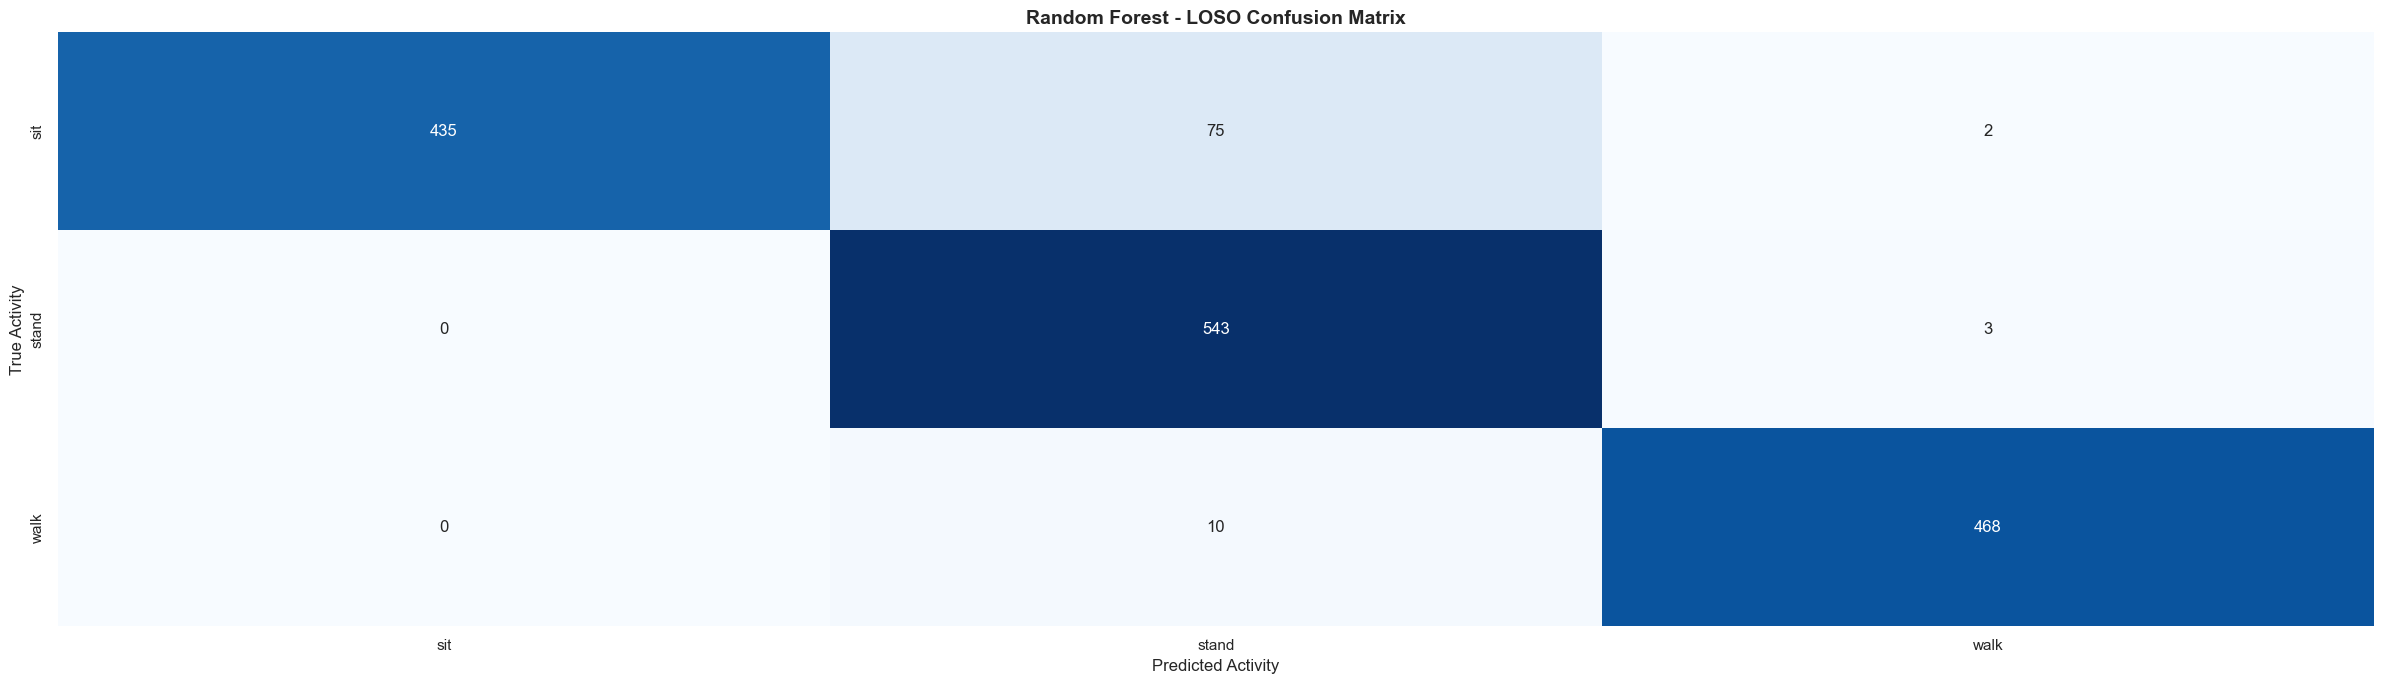

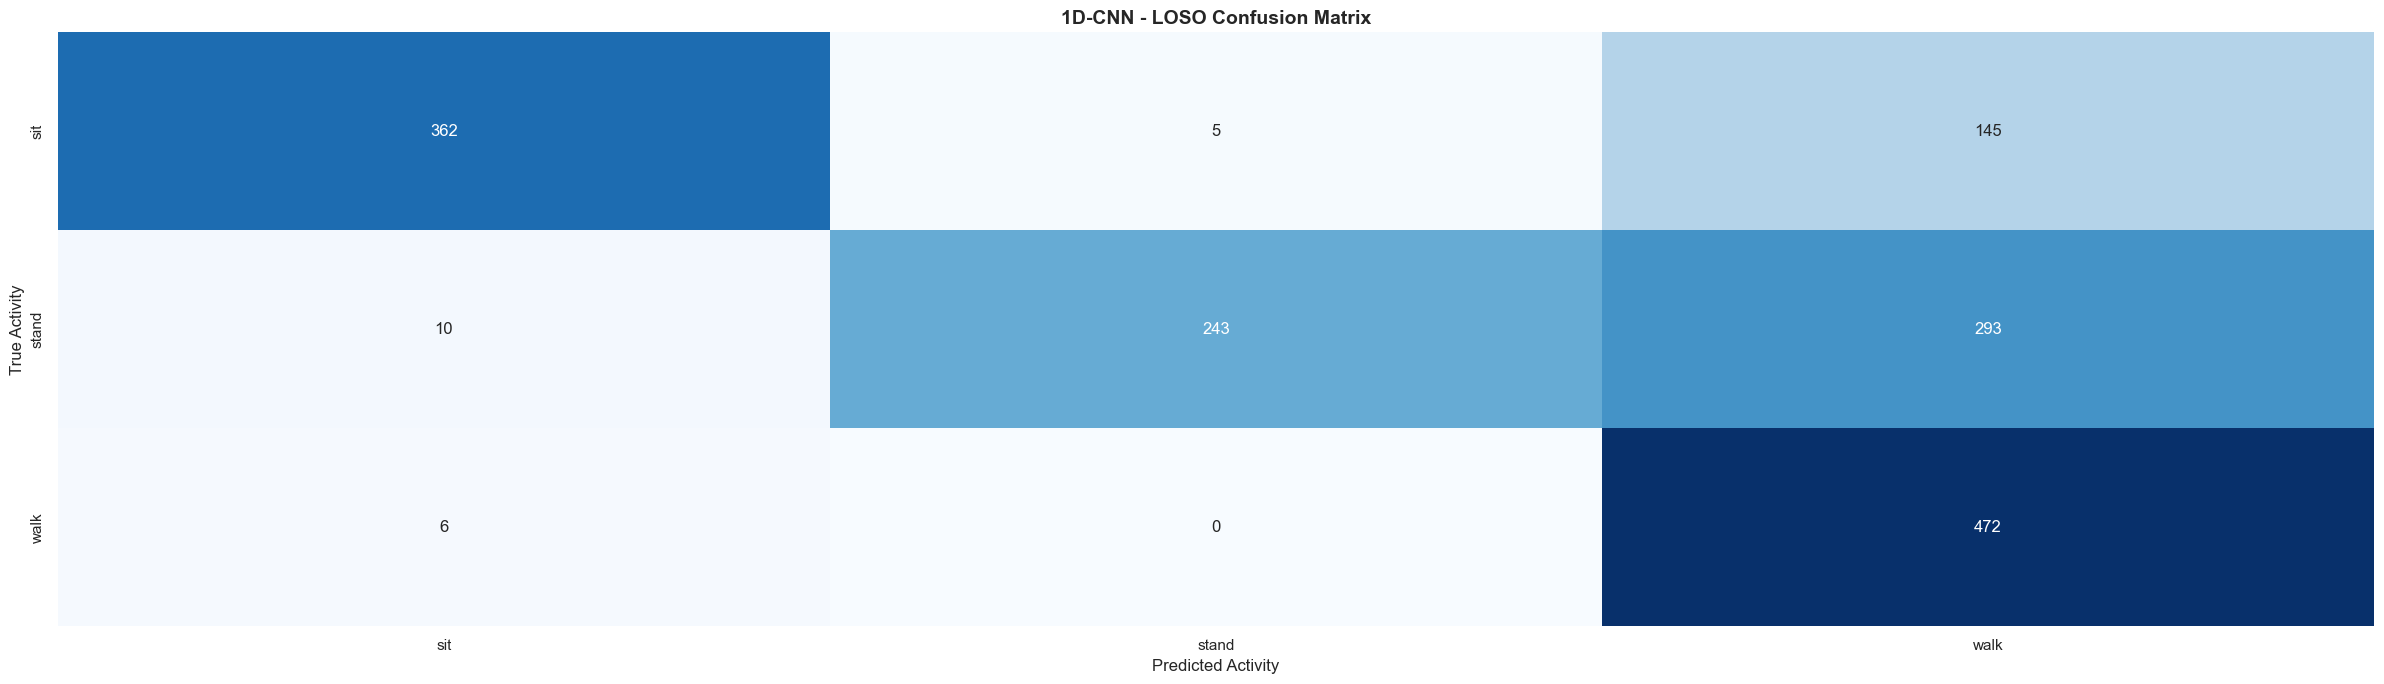

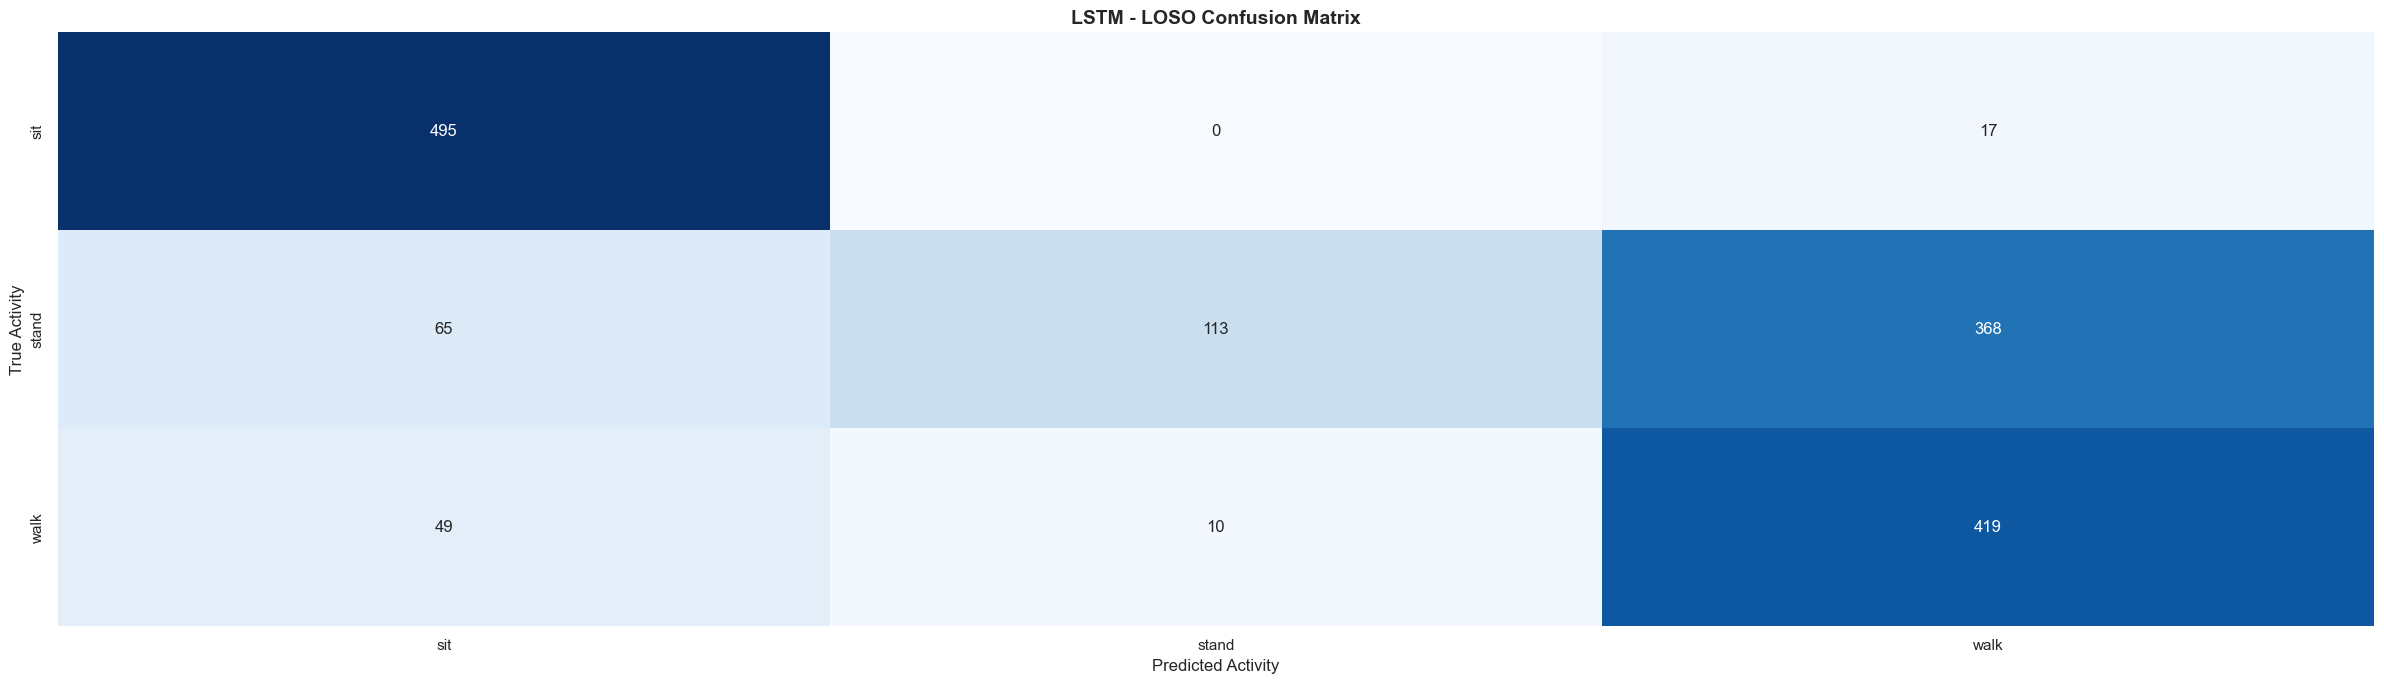

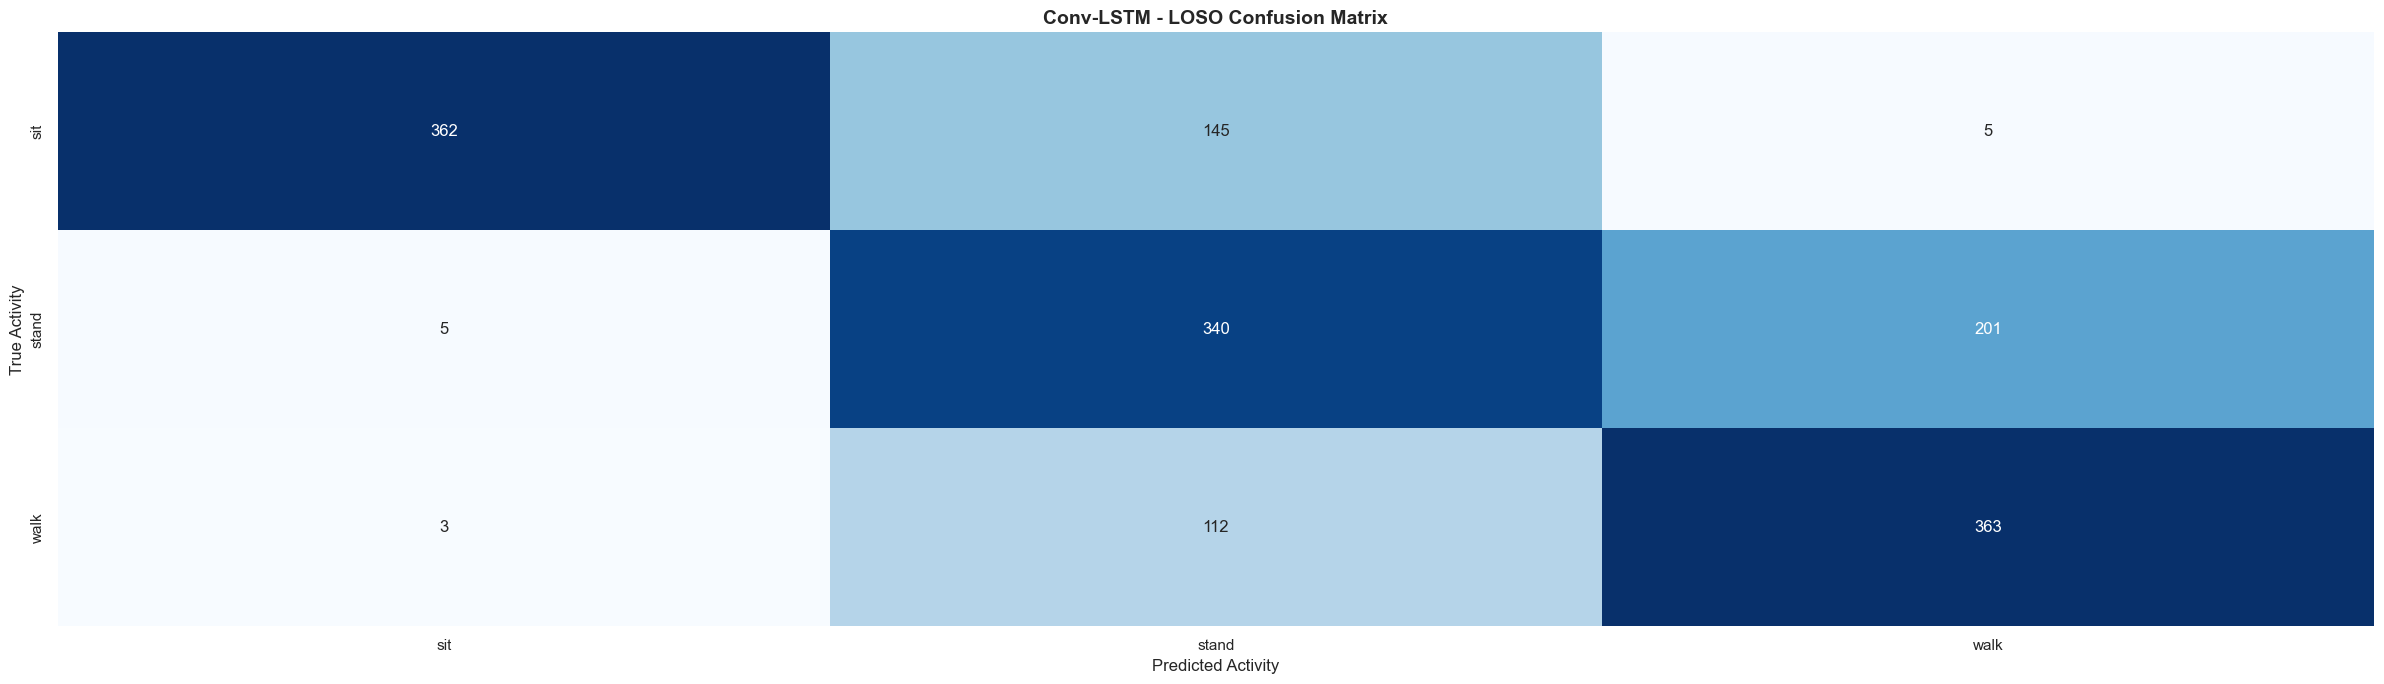

In [31]:
def run_confusion_matrix_analysis():
    """Run the confusion matrix analysis stage."""
    for model_name, predictions in all_model_predictions.items():
        matrix = confusion_matrix(predictions['y_true'], predictions['y_pred'], labels=CLASS_INDICES)
        plt.figure(figsize=(24, 7))
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
        plt.title(f'{model_name} - LOSO Confusion Matrix', fontsize=14, fontweight='bold')
        plt.xlabel('Predicted Activity')
        plt.ylabel('True Activity')
        plt.tight_layout()
        plt.show()
run_confusion_matrix_analysis()


### Generalisation and Overfitting Assessment
---

A model should not be judged solely by its training accuracy.

A classifier that achieves near-perfect performance on the training participants but performs substantially worse on unseen participants is likely learning participant-specific patterns rather than general activity characteristics.

For each model, the mean training, validation, and LOSO test accuracies are therefore compared.

The generalisation gap is defined as:

`Training Accuracy - Test Accuracy`

A small positive gap suggests that training and unseen-subject performance are relatively consistent.

A large positive gap suggests potential overfitting.

Validation performance provides an additional intermediate measure because the validation participant was also excluded from model fitting.

This analysis is particularly important for the Random Forest, whose earlier unrestricted trees could memorise the training windows.

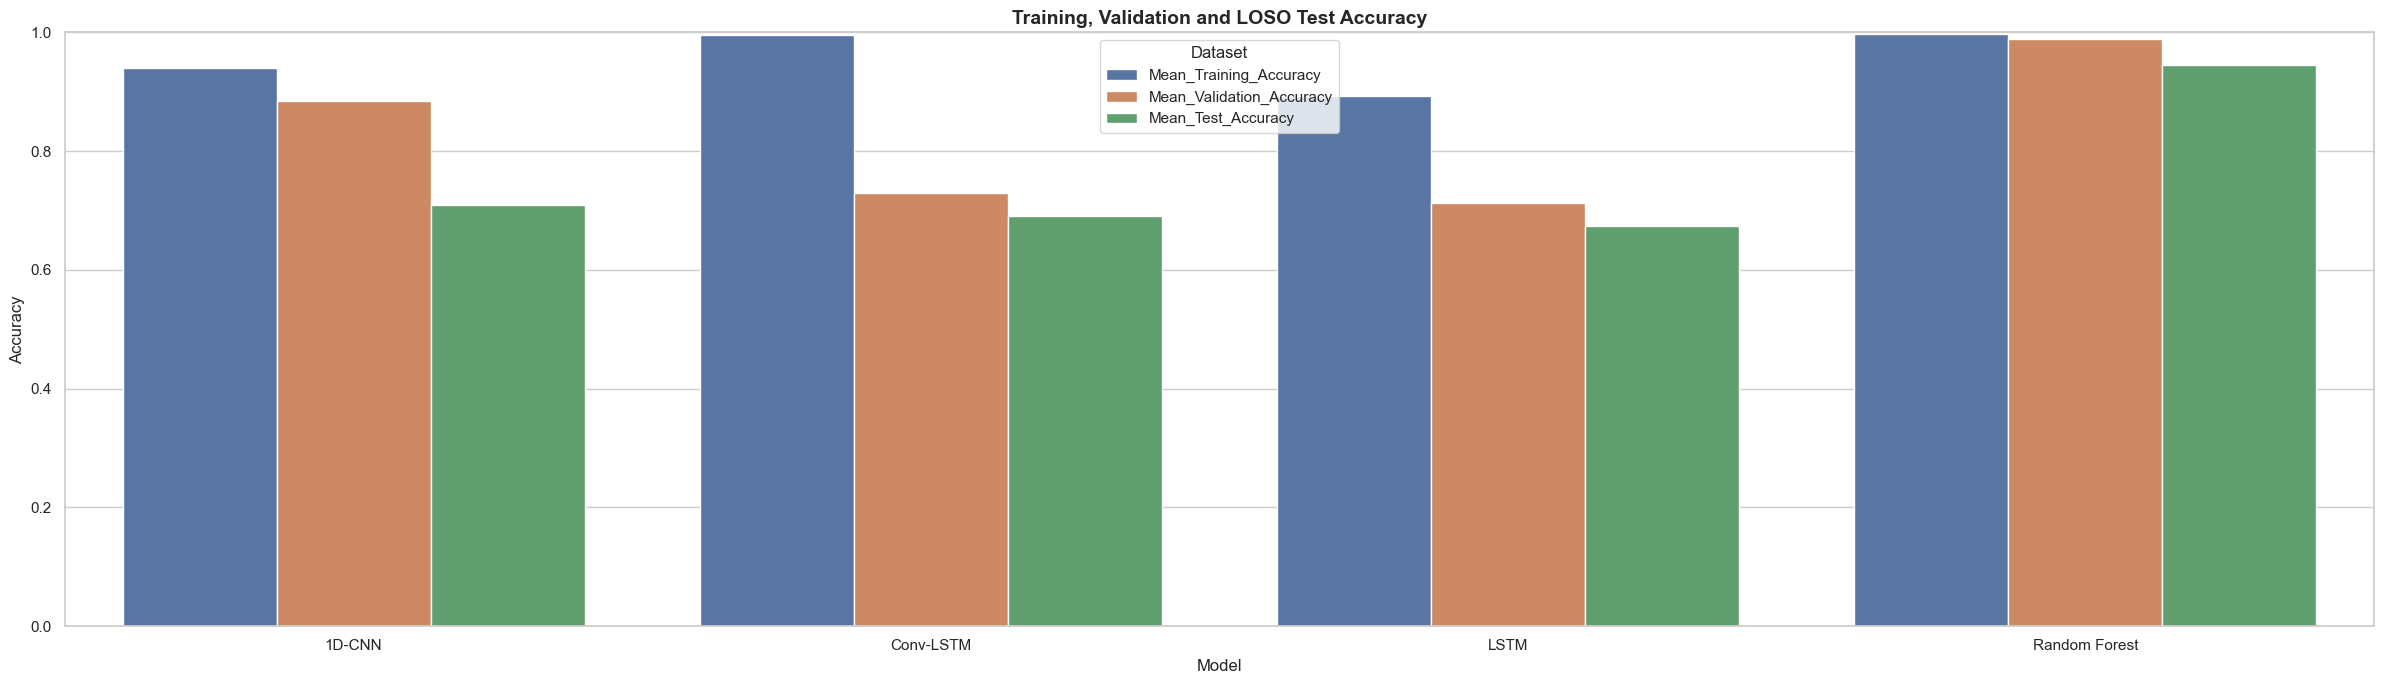

In [32]:
def run_generalisation_analysis():
    """Run the generalisation analysis stage."""
    global generalisation_summary, accuracy_comparison
    generalisation_summary = all_fold_results.groupby('Model').agg(Mean_Training_Accuracy=('Train_Accuracy', 'mean'), Mean_Validation_Accuracy=('Validation_Accuracy', 'mean'), Mean_Test_Accuracy=('Accuracy', 'mean'), Mean_Generalisation_Gap=('Generalisation_Gap', 'mean'), SD_Test_Accuracy=('Accuracy', 'std')).reset_index()
    numeric_columns = generalisation_summary.select_dtypes(include=np.number).columns
    generalisation_summary[numeric_columns] = generalisation_summary[numeric_columns].round(4)
    accuracy_comparison = generalisation_summary[['Model', 'Mean_Training_Accuracy', 'Mean_Validation_Accuracy', 'Mean_Test_Accuracy']].melt(id_vars='Model', var_name='Dataset', value_name='Accuracy')
    plt.figure(figsize=(24, 7))
    sns.barplot(data=accuracy_comparison, x='Model', y='Accuracy', hue='Dataset')
    plt.title('Training, Validation and LOSO Test Accuracy', fontsize=14, fontweight='bold')
    plt.xlabel('Model')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()
run_generalisation_analysis()


### Model Feature Importance
---

Understanding which IMU signals influence each classifier is important for both model interpretation and future sensor-system design.

The four models used in this study do not all provide feature importance in the same way.

Random Forest has a native tree-based feature-importance measure, whereas the CNN, LSTM, and Conv-LSTM learn distributed representations across many internal weights and therefore do not provide a directly comparable built-in importance value for each input channel.

To make the comparison consistent across all four classifiers, **permutation importance** is used.

For a particular IMU channel, such as `knee_ax`, its complete temporal trace is randomly exchanged between test windows while all other channels remain unchanged. The trained model then performs classification again.

If disrupting that channel produces a substantial reduction in weighted F1 score, the channel contains information that the model relies upon strongly.

The importance of channel \(j\) is therefore defined as:

\[
I_j =
F1_{\text{baseline}}
-
F1_{\text{permuted},j}
\]

A larger positive value indicates greater model dependence on that sensor channel.

Importantly, the entire 100-sample temporal trace is permuted between windows rather than shuffling individual time samples. This preserves the internal temporal structure of the signal while removing its relationship with the correct activity label.

For computational practicality, interpretation is performed on one representative LOSO fold. The selected fold prioritises a held-out participant containing all activity classes and, where possible, the largest available test set.

The Random Forest receives the same statistical window representation used during the original experiment. CNN, LSTM, and Conv-LSTM receive the same scaled temporal representation used during their original training.

Permutation importance should be interpreted as **model reliance rather than causal importance**. Strongly correlated sensor channels can share information, so disrupting one channel may produce a smaller reduction when another channel contains similar information.

FEATURE IMPORTANCE FOLD
Fold: 5
Validation participant: user_6
Held-out test participant: user_5
MODEL PERMUTATION FEATURE IMPORTANCE


,Model,Feature,Baseline_Weighted_F1,Mean_Weighted_F1_Drop,SD_Weighted_F1_Drop
0,1D-CNN,thigh_az,0.55603,0.00636,0.00023
1,1D-CNN,knee_ay,0.55603,0.00284,0.00005
2,1D-CNN,lumbar_gx,0.55603,0.00148,0.00051
3,1D-CNN,lumbar_gz,0.55603,0.00093,0.00105
4,1D-CNN,lumbar_ay,0.55603,-0.00001,0.00037
...,...,...,...,...,...
67,Random Forest,lumbar_gz,1.00000,0.00000,0.00000
68,Random Forest,thigh_ax,1.00000,0.00000,0.00000
69,Random Forest,thigh_gx,1.00000,0.00000,0.00000
70,Random Forest,thigh_gy,1.00000,0.00000,0.00000


1D-CNN - TOP 10 CHANNELS


,Model,Feature,Baseline_Weighted_F1,Mean_Weighted_F1_Drop,SD_Weighted_F1_Drop
0,1D-CNN,thigh_az,0.55603,0.00636,0.00023
1,1D-CNN,knee_ay,0.55603,0.00284,0.00005
2,1D-CNN,lumbar_gx,0.55603,0.00148,0.00051
3,1D-CNN,lumbar_gz,0.55603,0.00093,0.00105
4,1D-CNN,lumbar_ay,0.55603,-0.00001,0.00037
5,1D-CNN,lumbar_gy,0.55603,-0.00336,0.00055
6,1D-CNN,thigh_gz,0.55603,-0.00346,0.00164
7,1D-CNN,knee_gx,0.55603,-0.00359,0.00063
8,1D-CNN,knee_gz,0.55603,-0.00408,0.00097
9,1D-CNN,knee_gy,0.55603,-0.00454,0.00070


CONV-LSTM - TOP 10 CHANNELS


,Model,Feature,Baseline_Weighted_F1,Mean_Weighted_F1_Drop,SD_Weighted_F1_Drop
18,Conv-LSTM,knee_az,0.57137,0.06594,0.00687
19,Conv-LSTM,lumbar_az,0.57137,0.04450,0.00436
20,Conv-LSTM,thigh_az,0.57137,0.01525,0.00102
21,Conv-LSTM,knee_ay,0.57137,0.00000,0.00000
22,Conv-LSTM,knee_gx,0.57137,0.00000,0.00000
23,Conv-LSTM,knee_gy,0.57137,0.00000,0.00000
24,Conv-LSTM,knee_gz,0.57137,0.00000,0.00000
25,Conv-LSTM,lumbar_ax,0.57137,0.00000,0.00000
26,Conv-LSTM,lumbar_ay,0.57137,0.00000,0.00000
27,Conv-LSTM,lumbar_gx,0.57137,0.00000,0.00000


LSTM - TOP 10 CHANNELS


,Model,Feature,Baseline_Weighted_F1,Mean_Weighted_F1_Drop,SD_Weighted_F1_Drop
36,LSTM,lumbar_az,1.0,0.17844,0.01237
37,LSTM,thigh_az,1.0,0.12830,0.01250
38,LSTM,knee_az,1.0,0.10243,0.00806
39,LSTM,knee_gz,1.0,0.08903,0.00785
40,LSTM,lumbar_gy,1.0,0.00769,0.00218
41,LSTM,thigh_gy,1.0,0.00768,0.00217
42,LSTM,thigh_ax,1.0,0.00614,0.00434
43,LSTM,thigh_ay,1.0,0.00461,0.00000
44,LSTM,lumbar_ax,1.0,0.00461,0.00000
45,LSTM,thigh_gx,1.0,0.00461,0.00000


RANDOM FOREST - TOP 10 CHANNELS


,Model,Feature,Baseline_Weighted_F1,Mean_Weighted_F1_Drop,SD_Weighted_F1_Drop
54,Random Forest,thigh_ay,1.0,0.10416,0.01398
55,Random Forest,lumbar_az,1.0,0.09256,0.00920
56,Random Forest,thigh_az,1.0,0.08932,0.01050
57,Random Forest,knee_ax,1.0,0.00000,0.00000
58,Random Forest,knee_ay,1.0,0.00000,0.00000
59,Random Forest,knee_az,1.0,0.00000,0.00000
60,Random Forest,knee_gx,1.0,0.00000,0.00000
61,Random Forest,knee_gy,1.0,0.00000,0.00000
62,Random Forest,knee_gz,1.0,0.00000,0.00000
63,Random Forest,lumbar_ax,1.0,0.00000,0.00000


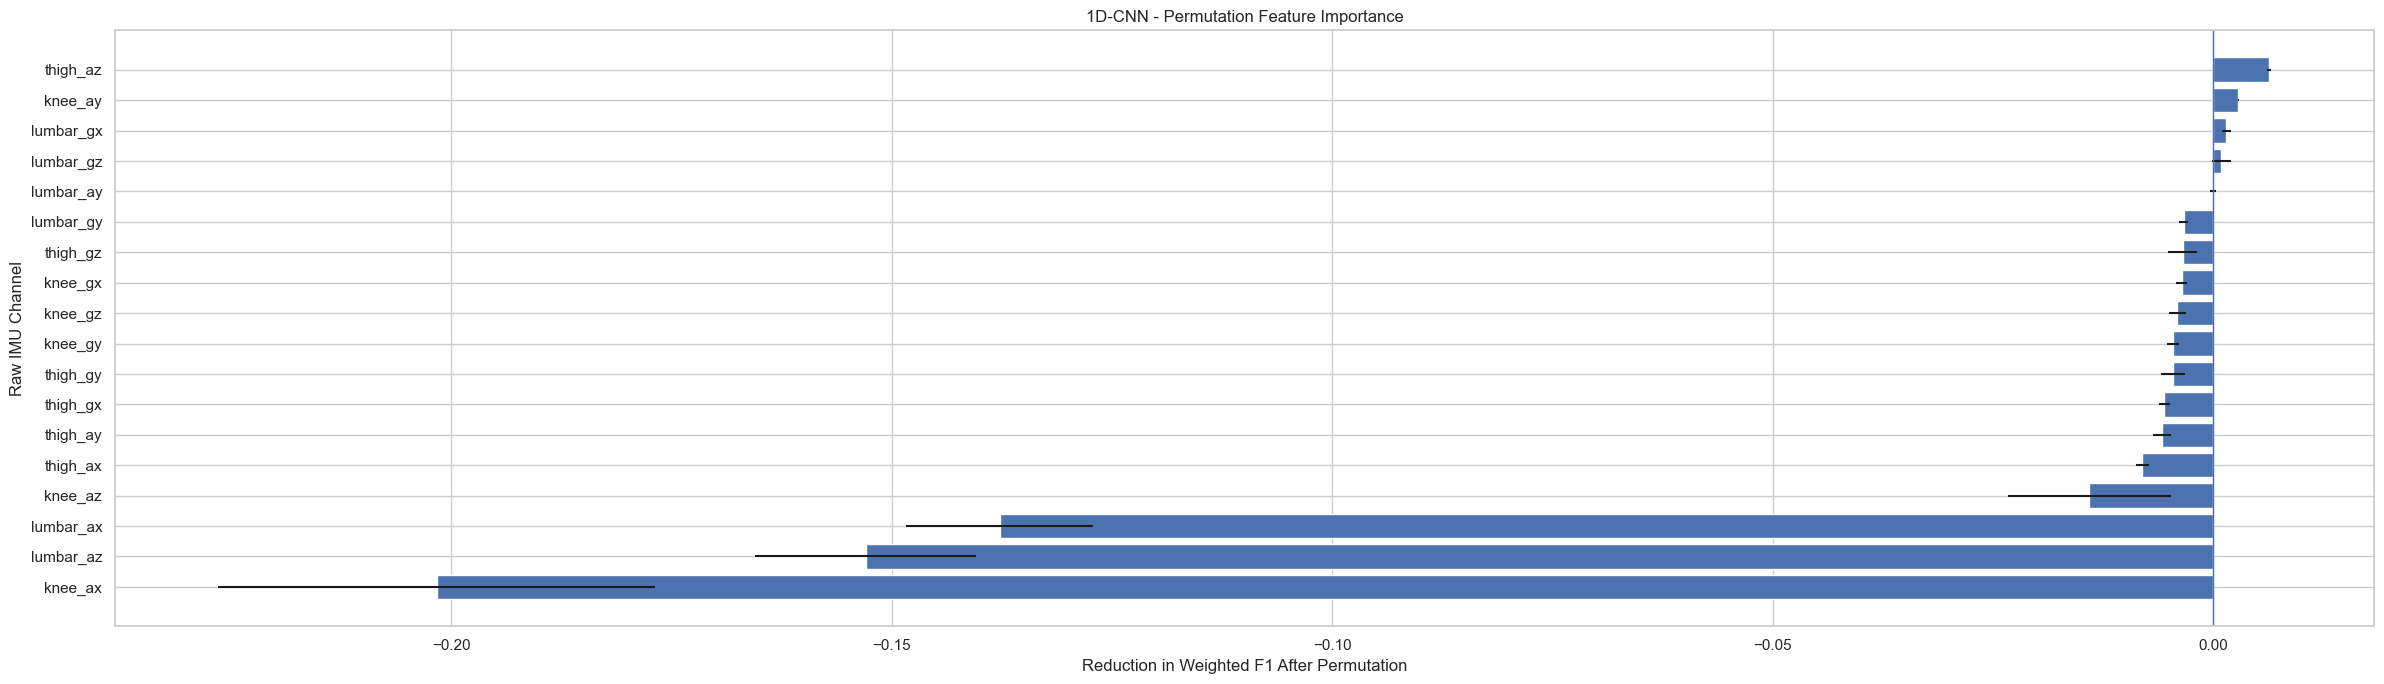

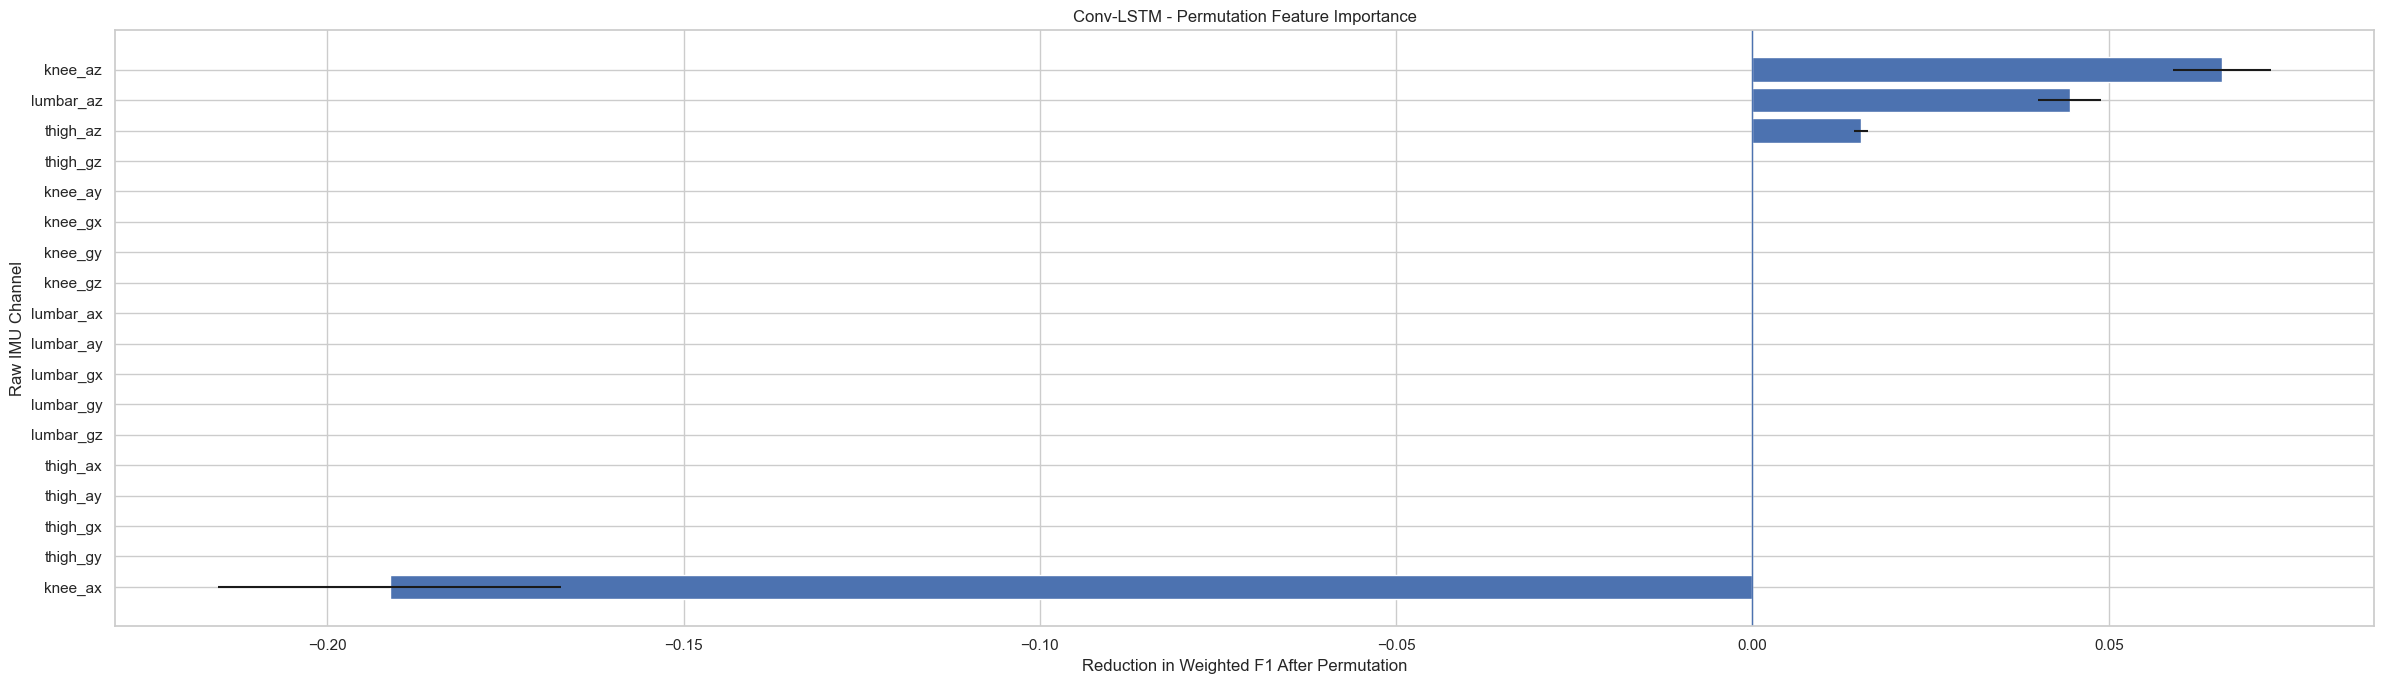

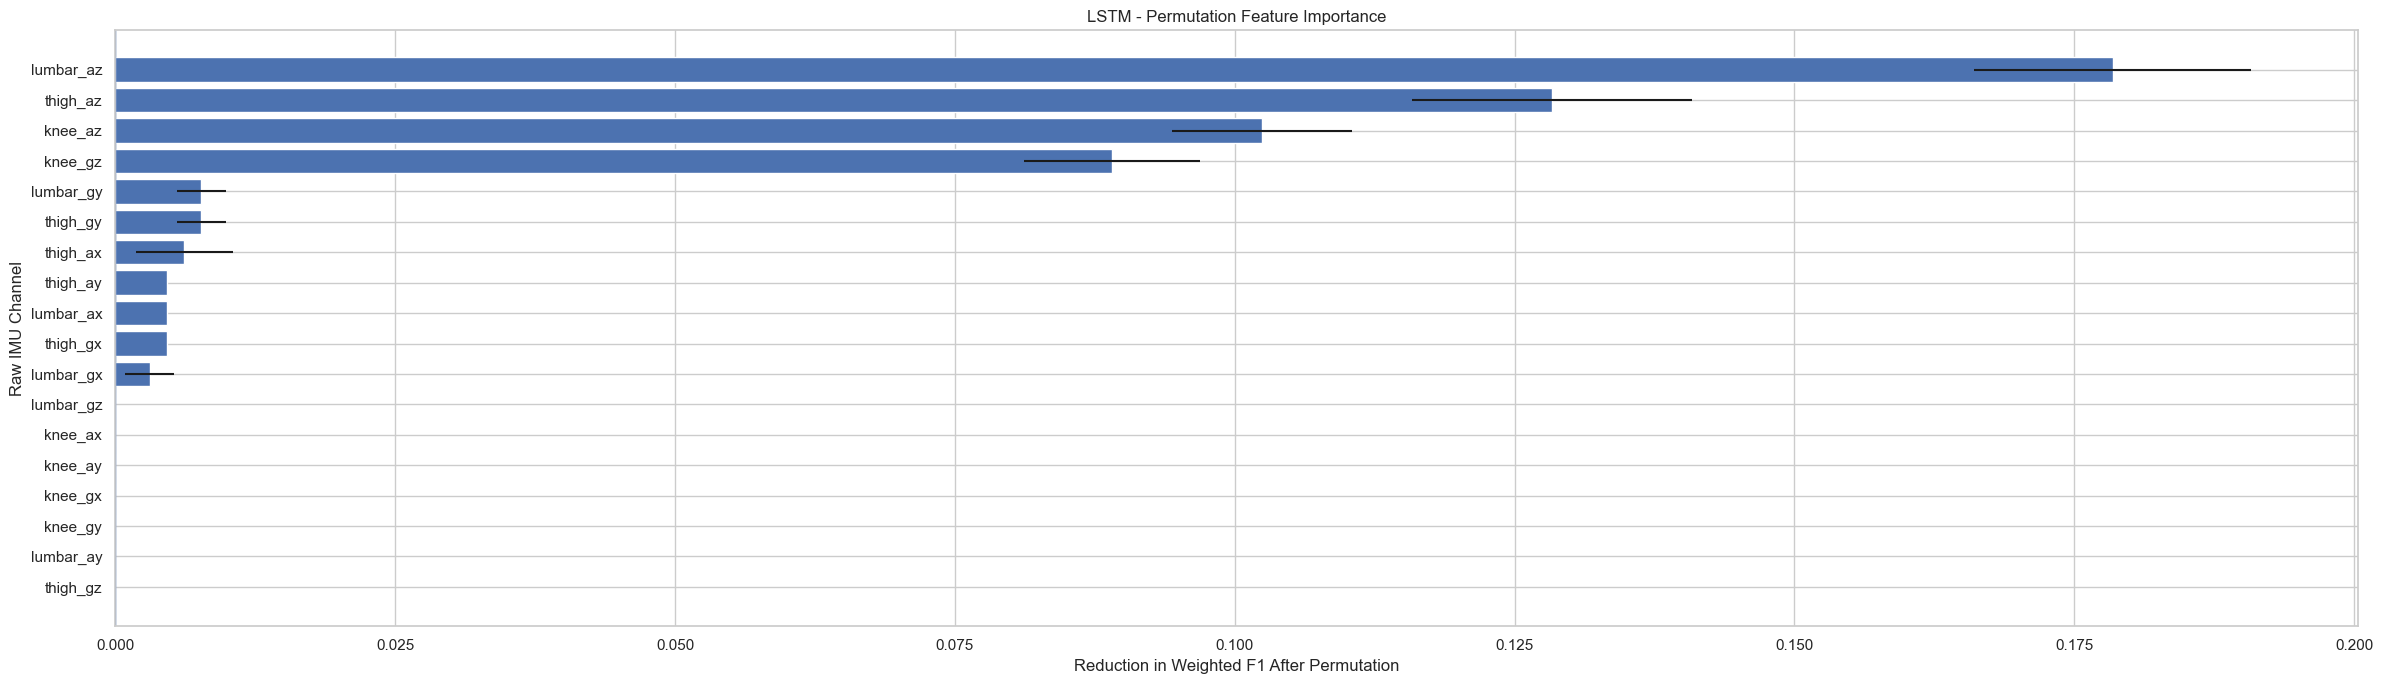

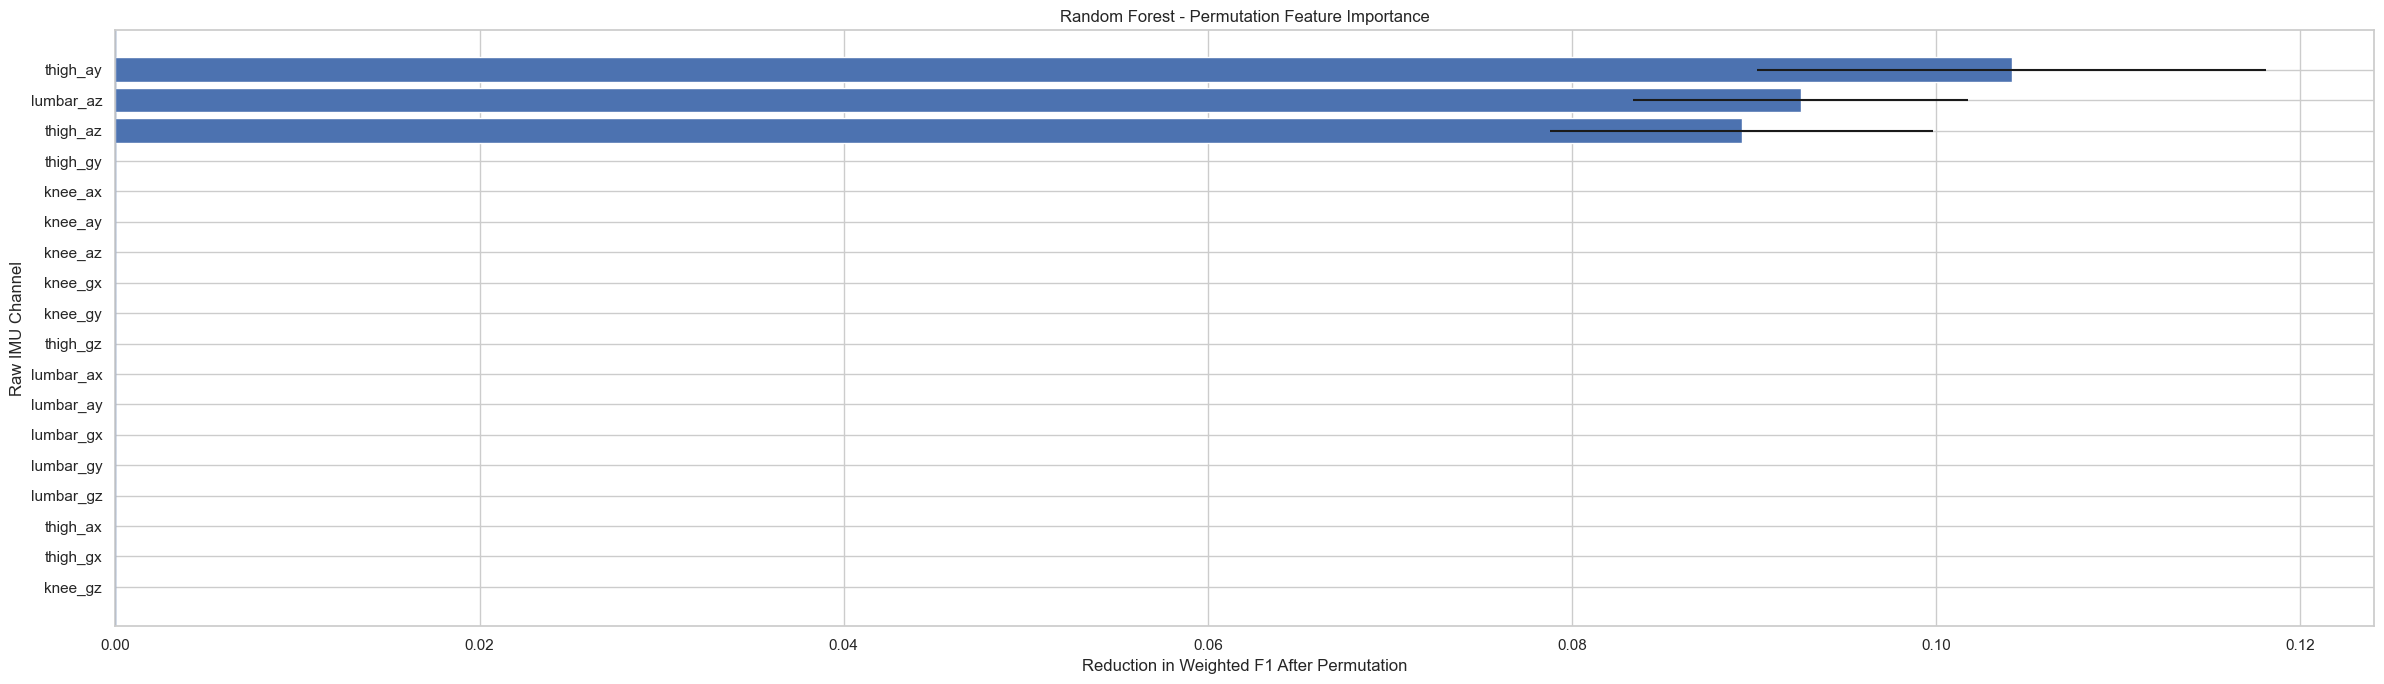

In [33]:
def score_importance_fold(fold):
    """Score a LOSO fold by class coverage first, then by test-window count."""
    labels = y_encoded[fold["test_indices"]]
    return len(np.unique(labels)), len(fold["test_indices"])


def select_representative_importance_fold():
    """Return the LOSO fold with the richest held-out interpretation set."""
    return max(loso_folds, key=score_importance_fold)


def get_importance_fold_data(fold):
    """Return raw train, validation and test arrays for feature interpretation."""
    return {
        "X_train": X_windows[fold["train_indices"]],
        "X_validation": X_windows[fold["validation_indices"]],
        "X_test": X_windows[fold["test_indices"]],
        "y_train": y_encoded[fold["train_indices"]],
        "y_validation": y_encoded[fold["validation_indices"]],
        "y_test": y_encoded[fold["test_indices"]],
    }


def transform_windows_with_scaler(windows, scaler):
    """Scale a 3D window array with an already fitted scaler."""
    flat = windows.reshape(-1, windows.shape[-1])
    return scaler.transform(flat).reshape(windows.shape).astype(np.float32)


def permute_channel_between_windows(windows, channel_index, rng):
    """Shuffle one complete channel trace between windows."""
    permuted = windows.copy()
    order = rng.permutation(len(windows))
    permuted[:, :, channel_index] = windows[order, :, channel_index]
    return permuted


def weighted_f1(y_true, y_pred):
    """Return weighted F1 using the notebook's zero-division policy."""
    return f1_score(y_true, y_pred, average="weighted", zero_division=0)


def calculate_channel_permutation_importance(
    model_name,
    predict_function,
    X_test,
    y_test,
):
    """Measure how much weighted F1 falls when each IMU channel is disrupted."""
    baseline_f1 = weighted_f1(y_test, predict_function(X_test))
    rng = np.random.default_rng(RANDOM_SEED)
    rows = []

    for channel_index, channel_name in enumerate(MODEL_FEATURE_COLUMNS):
        drops = []
        for _ in range(PERMUTATION_REPEATS):
            permuted = permute_channel_between_windows(X_test, channel_index, rng)
            drops.append(baseline_f1 - weighted_f1(y_test, predict_function(permuted)))

        rows.append(
            {
                "Model": model_name,
                "Feature": channel_name,
                "Baseline_Weighted_F1": baseline_f1,
                "Mean_Weighted_F1_Drop": np.mean(drops),
                "SD_Weighted_F1_Drop": np.std(drops),
            }
        )
    return pd.DataFrame(rows)


def fit_importance_random_forest(fold):
    """Fit the baseline RF on every non-test participant in one LOSO fold."""
    training_indices = np.concatenate(
        [fold["train_indices"], fold["validation_indices"]]
    )
    model = build_random_forest(RANDOM_SEED + fold["fold"])
    model.fit(
        extract_random_forest_features(X_windows[training_indices]),
        y_encoded[training_indices],
    )
    return model


def make_rf_importance_predictor(model):
    """Wrap an RF so permutation analysis can pass it raw 3D windows."""
    def predict(windows):
        """Predict RF labels from raw 3D IMU windows."""
        return model.predict(extract_random_forest_features(windows))
    return predict


def fit_importance_scaler(fold_data):
    """Fit the interpretation scaler on the representative fold's training set."""
    _, _, _, scaler = scale_window_sets(
        fold_data["X_train"],
        fold_data["X_validation"],
        fold_data["X_test"],
    )
    return scaler


def make_neural_importance_predictor(model, scaler, input_transform=None):
    """Wrap a Keras model so it can predict directly from raw 3D windows."""
    def predict(windows):
        """Predict neural labels from raw 3D IMU windows."""
        scaled = transform_windows_with_scaler(windows, scaler)
        if input_transform is not None:
            scaled = input_transform(scaled)
        return np.argmax(model(scaled, training=False).numpy(), axis=1)
    return predict


def fit_importance_neural_model(model_builder, fold_data, scaler, input_transform=None):
    """Fit one neural architecture on the representative interpretation fold."""
    train = transform_windows_with_scaler(fold_data["X_train"], scaler)
    validation = transform_windows_with_scaler(fold_data["X_validation"], scaler)

    if input_transform is not None:
        train = input_transform(train)
        validation = input_transform(validation)

    tf.keras.backend.clear_session()
    model = model_builder(train.shape[1:], NUM_CLASSES)
    model.fit(
        train,
        fold_data["y_train"],
        validation_data=(validation, fold_data["y_validation"]),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=get_class_weights(fold_data["y_train"]),
        callbacks=get_training_callbacks(),
        verbose=0,
    )
    return model


def interpret_neural_model(name, builder, fold_data, scaler, input_transform=None):
    """Train one neural model and return its raw-channel permutation importance."""
    model = fit_importance_neural_model(
        builder,
        fold_data,
        scaler,
        input_transform,
    )
    predictor = make_neural_importance_predictor(model, scaler, input_transform)
    result = calculate_channel_permutation_importance(
        name,
        predictor,
        fold_data["X_test"],
        fold_data["y_test"],
    )
    del model
    gc.collect()
    return result


def plot_feature_importance(results):
    """Plot one horizontal permutation-importance chart per model."""
    for model_name, model_data in results.groupby("Model"):
        plot_data = model_data.sort_values("Mean_Weighted_F1_Drop")
        plt.figure(figsize=(24, 7))
        plt.barh(
            plot_data["Feature"],
            plot_data["Mean_Weighted_F1_Drop"],
            xerr=plot_data["SD_Weighted_F1_Drop"],
        )
        plt.axvline(0, linewidth=1)
        plt.title(f"{model_name} - Permutation Feature Importance")
        plt.xlabel("Reduction in Weighted F1 After Permutation")
        plt.ylabel("Raw IMU Channel")
        plt.tight_layout()
        plt.show()


def report_top_features(results, top_n=10):
    """Display the most influential raw channels for each model."""
    for model_name, model_data in results.groupby("Model"):
        print_section(f"{model_name.upper()} - TOP {top_n} CHANNELS", 70)
        display(model_data.head(top_n).round(5))


def build_all_feature_importance_results(fold, fold_data):
    """Train each model family and combine its channel-importance results."""
    rf_model = fit_importance_random_forest(fold)
    rf_result = calculate_channel_permutation_importance(
        "Random Forest",
        make_rf_importance_predictor(rf_model),
        fold_data["X_test"],
        fold_data["y_test"],
    )

    scaler = fit_importance_scaler(fold_data)
    neural_results = [
        interpret_neural_model("1D-CNN", build_cnn_model, fold_data, scaler),
        interpret_neural_model("LSTM", build_lstm_model, fold_data, scaler),
        interpret_neural_model(
            "Conv-LSTM",
            build_convlstm_model,
            fold_data,
            scaler,
            reshape_for_convlstm,
        ),
    ]
    return pd.concat([rf_result, *neural_results], ignore_index=True)


def sort_feature_importance(results):
    """Sort feature importance from the strongest to weakest channel per model."""
    return (
        results.sort_values(
            ["Model", "Mean_Weighted_F1_Drop"],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )


def report_feature_importance_fold(fold):
    """Print the participant roles used for the interpretation experiment."""
    print_section("FEATURE IMPORTANCE FOLD")
    print(f"Fold: {fold['fold']}")
    print(f"Validation participant: {fold['validation_user']}")
    print(f"Held-out test participant: {fold['test_user']}")


def run_feature_importance_analysis():
    """Run comparable raw-channel permutation importance for all four models."""
    global importance_fold, feature_importance_results

    importance_fold = select_representative_importance_fold()
    fold_data = get_importance_fold_data(importance_fold)
    report_feature_importance_fold(importance_fold)

    results = build_all_feature_importance_results(importance_fold, fold_data)
    feature_importance_results = sort_feature_importance(results)

    print_section("MODEL PERMUTATION FEATURE IMPORTANCE", 90)
    display(feature_importance_results.round(5))
    report_top_features(feature_importance_results)
    plot_feature_importance(feature_importance_results)
    return feature_importance_results


feature_importance_results = run_feature_importance_analysis()


### Subject-Independent Hyperparameter Tuning of the Random Forest
---

The Random Forest produced the strongest performance among the classifiers evaluated in the initial LOSO experiment. Hyperparameter optimisation is therefore restricted to this model rather than tuning every classifier.

Restricting tuning to the strongest baseline reduces computational cost and avoids repeatedly searching the configuration space of models that have already demonstrated lower subject-independent performance.

Hyperparameter tuning must preserve the participant-independent design of the experiment.

A conventional random cross-validation search over individual windows would be inappropriate because overlapping windows from the same participant could appear in both the training and validation portions of the search. This would allow the optimisation procedure to favour configurations that exploit participant-specific characteristics.

A **nested group-based procedure** is therefore used.

For every outer LOSO fold:

1. The original held-out participant remains completely untouched as the final test participant.
2. All remaining participants form the development dataset.
3. `GroupKFold` divides the development participants into inner training and validation groups.
4. `RandomizedSearchCV` evaluates candidate Random Forest configurations using weighted F1.
5. The best configuration is retrained using all non-test participants.
6. Performance is measured once on the untouched outer test participant.

This means that the activity windows belonging to the final test participant never contribute to hyperparameter selection.

The following Random Forest parameters are explored:

- Number of trees
- Maximum tree depth
- Minimum samples required to split a node
- Minimum samples allowed in a leaf
- Number of candidate features examined at each split
- Class-weighting strategy

Weighted F1 is used as the optimisation criterion because it considers both precision and recall while accounting for differences in class frequency.

For a fair comparison, a new copy of the **base Random Forest** is also trained on exactly the same non-test participants in every outer fold. The tuned and base forests therefore differ only in their hyperparameters, not in the amount of training data available to them.

After the nested evaluation, the parameter values most consistently selected by the inner participant-wise searches are used to construct `FINAL_RF_PARAMS`. A final deployment Random Forest is then fitted to all currently available HAR windows. This final fitted model is intended for deployment rather than unbiased performance estimation; LOSO results remain the appropriate estimate of generalisation to unseen participants.

TUNING OUTER FOLD 1 | TEST: user_1
Best inner CV weighted F1: 0.9901
Base weighted F1: 0.9854
Tuned weighted F1: 0.9854
Best parameters: {'n_estimators': 400, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced_subsample'}
TUNING OUTER FOLD 2 | TEST: user_2
Best inner CV weighted F1: 0.9904
Base weighted F1: 0.9725
Tuned weighted F1: 0.9793
Best parameters: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.75, 'max_depth': 8, 'class_weight': 'balanced_subsample'}
TUNING OUTER FOLD 3 | TEST: user_3
Best inner CV weighted F1: 0.9798
Base weighted F1: 0.9856
Tuned weighted F1: 0.9856
Best parameters: {'n_estimators': 400, 'min_samples_split': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 12, 'class_weight': 'balanced'}
TUNING OUTER FOLD 4 | TEST: user_4
Best inner CV weighted F1: 0.9788
Base weighted F1: 0.9907
Tuned weighted F1: 0.9907
Best parameters: {'n_estimators': 800,

,Model,Accuracy_Mean,Accuracy_SD,Weighted_F1_Mean,Weighted_F1_SD,Macro_F1_Mean,Macro_F1_SD
0,Base Random Forest,0.9876,0.0128,0.9884,0.0114,0.9488,0.1214
1,Tuned Random Forest,0.9893,0.0102,0.9897,0.0095,0.9497,0.1208


,Fold,Test_User,Inner_CV_Weighted_F1,Tuning_Time_Sec,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,class_weight
0,1,user_1,0.990144,20.753107,400,4,2,sqrt,20.0,balanced_subsample
1,2,user_2,0.990444,29.379297,800,2,1,0.75,8.0,balanced_subsample
2,3,user_3,0.979818,17.161021,400,8,5,sqrt,12.0,balanced
3,4,user_4,0.978762,18.474077,800,12,1,log2,8.0,balanced
4,5,user_5,0.984874,29.058176,800,4,1,log2,20.0,balanced_subsample
5,6,user_6,0.986814,19.210448,600,2,3,sqrt,NaN,balanced_subsample
6,7,user_7,0.988609,102.182617,600,2,2,log2,12.0,balanced_subsample
7,8,user_8,0.992624,26.970481,200,2,5,0.5,8.0,balanced_subsample


BASE RANDOM FOREST - POOLED LOSO REPORT
              precision    recall  f1-score   support

         sit     1.0000    0.9902    0.9951       512
       stand     0.9784    0.9945    0.9864       546
        walk     0.9895    0.9812    0.9853       478

    accuracy                         0.9889      1536
   macro avg     0.9893    0.9886    0.9889      1536
weighted avg     0.9890    0.9889    0.9889      1536

TUNED RANDOM FOREST - POOLED LOSO REPORT
              precision    recall  f1-score   support

         sit     1.0000    0.9922    0.9961       512
       stand     0.9801    0.9945    0.9873       546
        walk     0.9916    0.9833    0.9874       478

    accuracy                         0.9902      1536
   macro avg     0.9906    0.9900    0.9902      1536
weighted avg     0.9903    0.9902    0.9902      1536



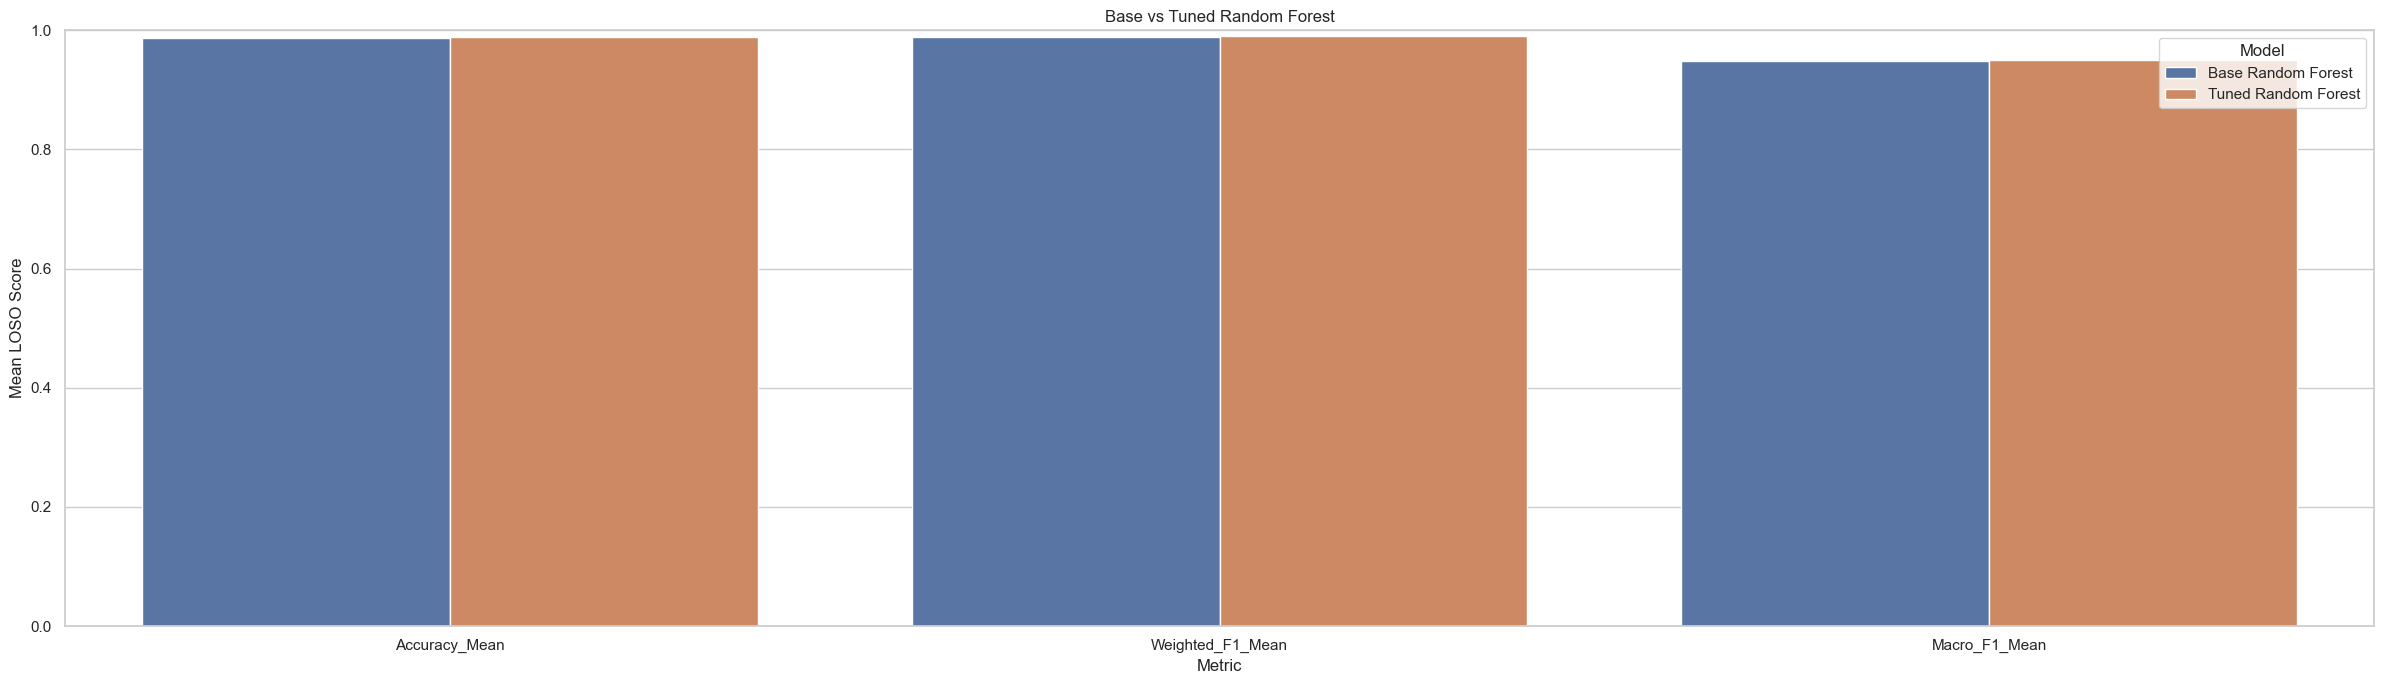

CONSENSUS RANDOM FOREST PARAMETERS
n_estimators: 800
max_depth: 8
min_samples_split: 2
min_samples_leaf: 1
max_features: sqrt
class_weight: balanced_subsample


In [34]:
def get_rf_outer_fold_data(fold, X_rf_all):
    """Return development/test arrays for one outer LOSO fold."""
    development_indices = np.concatenate(
        [fold["train_indices"], fold["validation_indices"]]
    )
    test_indices = fold["test_indices"]
    return {
        "X_development": X_rf_all[development_indices],
        "y_development": y_encoded[development_indices],
        "groups": window_users[development_indices],
        "X_test": X_rf_all[test_indices],
        "y_test": y_encoded[test_indices],
    }


def build_rf_search(seed, groups):
    """Create a participant-wise RandomizedSearchCV for Random Forest tuning."""
    number_of_users = len(np.unique(groups))
    inner_splits = min(INNER_GROUP_FOLDS, number_of_users)
    if inner_splits < 2:
        raise ValueError("At least two development participants are required.")

    estimator = RandomForestClassifier(random_state=seed, n_jobs=1)
    return RandomizedSearchCV(
        estimator=estimator,
        param_distributions=RF_PARAMETER_DISTRIBUTIONS,
        n_iter=RF_TUNING_ITERATIONS,
        scoring="f1_weighted",
        cv=GroupKFold(n_splits=inner_splits),
        refit=True,
        n_jobs=-1,
        random_state=seed,
        verbose=0,
    )


def fit_base_rf_for_tuning(fold_data, seed):
    """Fit the untuned baseline on the same development participants."""
    model = build_random_forest(seed)
    model.fit(fold_data["X_development"], fold_data["y_development"])
    return model


def evaluate_rf_model(model, fold_data):
    """Evaluate a fitted RF on the untouched outer test participant."""
    predictions = model.predict(fold_data["X_test"])
    metrics = calculate_classification_metrics(fold_data["y_test"], predictions)
    return predictions, metrics


def tune_one_rf_fold(fold, X_rf_all):
    """Tune and compare base/tuned Random Forests for one outer LOSO fold."""
    seed = RANDOM_SEED + fold["fold"]
    fold_data = get_rf_outer_fold_data(fold, X_rf_all)

    search = build_rf_search(seed, fold_data["groups"])
    started = time.perf_counter()
    search.fit(
        fold_data["X_development"],
        fold_data["y_development"],
        groups=fold_data["groups"],
    )
    tuning_time = time.perf_counter() - started

    tuned_model = search.best_estimator_.set_params(n_jobs=-1)
    base_model = fit_base_rf_for_tuning(fold_data, seed)

    base_predictions, base_metrics = evaluate_rf_model(base_model, fold_data)
    tuned_predictions, tuned_metrics = evaluate_rf_model(tuned_model, fold_data)

    return {
        "fold": fold,
        "fold_data": fold_data,
        "search": search,
        "tuning_time": tuning_time,
        "base_predictions": base_predictions,
        "base_metrics": base_metrics,
        "tuned_predictions": tuned_predictions,
        "tuned_metrics": tuned_metrics,
    }


def build_rf_comparison_rows(result):
    """Create the base/tuned metric rows for one outer fold."""
    fold = result["fold"]
    shared = {"Fold": fold["fold"], "Test_User": fold["test_user"]}
    return [
        {"Model": "Base Random Forest", **shared, **result["base_metrics"]},
        {"Model": "Tuned Random Forest", **shared, **result["tuned_metrics"]},
    ]


def build_rf_parameter_record(result):
    """Store the parameter choice and inner-CV score for one outer fold."""
    fold = result["fold"]
    search = result["search"]
    return {
        "Fold": fold["fold"],
        "Test_User": fold["test_user"],
        "Inner_CV_Weighted_F1": search.best_score_,
        "Tuning_Time_Sec": result["tuning_time"],
        **search.best_params_,
    }


def summarise_rf_tuning(comparison):
    """Aggregate base and tuned RF results across outer LOSO folds."""
    return (
        comparison.groupby("Model")
        .agg(
            Accuracy_Mean=("Accuracy", "mean"),
            Accuracy_SD=("Accuracy", "std"),
            Weighted_F1_Mean=("Weighted_F1", "mean"),
            Weighted_F1_SD=("Weighted_F1", "std"),
            Macro_F1_Mean=("Macro_F1", "mean"),
            Macro_F1_SD=("Macro_F1", "std"),
        )
        .reset_index()
    )


def choose_consensus_rf_parameters(parameter_records):
    """Choose the most frequently selected inner-CV value for each parameter."""
    return {
        parameter: Counter(record[parameter] for record in parameter_records).most_common(1)[0][0]
        for parameter in RF_PARAMETER_DISTRIBUTIONS
    }


def plot_rf_tuning_comparison(summary):
    """Plot mean LOSO metrics for the base and tuned Random Forest."""
    plot_data = summary[
        ["Model", "Accuracy_Mean", "Weighted_F1_Mean", "Macro_F1_Mean"]
    ].melt(id_vars="Model", var_name="Metric", value_name="Score")

    plt.figure(figsize=(24, 7))
    sns.barplot(data=plot_data, x="Metric", y="Score", hue="Model")
    plt.ylim(0, 1)
    plt.title("Base vs Tuned Random Forest")
    plt.xlabel("Metric")
    plt.ylabel("Mean LOSO Score")
    plt.tight_layout()
    plt.show()


def print_pooled_rf_report(title, y_true, y_pred):
    """Print a pooled LOSO classification report for one RF configuration."""
    print_section(title, 90)
    print(
        classification_report(
            y_true,
            y_pred,
            labels=CLASS_INDICES,
            target_names=label_encoder.classes_,
            digits=4,
            zero_division=0,
        )
    )


def collect_rf_tuning_results(X_rf_all):
    """Run nested RF tuning over every outer LOSO fold and collect raw results."""
    comparison_rows = []
    parameter_records = []
    pooled = {"base_true": [], "base_pred": [], "tuned_true": [], "tuned_pred": []}

    for fold in loso_folds:
        print_section(
            f"TUNING OUTER FOLD {fold['fold']} | TEST: {fold['test_user']}",
            90,
        )
        result = tune_one_rf_fold(fold, X_rf_all)
        comparison_rows.extend(build_rf_comparison_rows(result))
        parameter_records.append(build_rf_parameter_record(result))

        y_test = result["fold_data"]["y_test"]
        pooled["base_true"].append(y_test)
        pooled["base_pred"].append(result["base_predictions"])
        pooled["tuned_true"].append(y_test)
        pooled["tuned_pred"].append(result["tuned_predictions"])

        print(f"Best inner CV weighted F1: {result['search'].best_score_:.4f}")
        print(f"Base weighted F1: {result['base_metrics']['Weighted_F1']:.4f}")
        print(f"Tuned weighted F1: {result['tuned_metrics']['Weighted_F1']:.4f}")
        print(f"Best parameters: {result['search'].best_params_}")

    return pd.DataFrame(comparison_rows), parameter_records, pooled


def report_rf_tuning_results(comparison, parameter_records, pooled):
    """Display nested-CV summaries, pooled reports and comparison plots."""
    summary = summarise_rf_tuning(comparison)
    parameter_table = pd.DataFrame(parameter_records)

    print_section("BASE VS TUNED RANDOM FOREST - LOSO SUMMARY", 90)
    display(summary.round(4))
    display(parameter_table)

    print_pooled_rf_report(
        "BASE RANDOM FOREST - POOLED LOSO REPORT",
        np.concatenate(pooled["base_true"]),
        np.concatenate(pooled["base_pred"]),
    )
    print_pooled_rf_report(
        "TUNED RANDOM FOREST - POOLED LOSO REPORT",
        np.concatenate(pooled["tuned_true"]),
        np.concatenate(pooled["tuned_pred"]),
    )
    plot_rf_tuning_comparison(summary)
    return summary, parameter_table


def fit_final_tuned_random_forest(X_rf_all, parameter_records):
    """Fit the final deployment RF using consensus inner-CV hyperparameters."""
    parameters = choose_consensus_rf_parameters(parameter_records)
    model = RandomForestClassifier(
        **parameters,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    model.fit(X_rf_all, y_encoded)
    return model, parameters


def run_random_forest_tuning():
    """Tune the Random Forest subject-independently and fit its deployment copy."""
    global X_rf_all
    global rf_tuning_comparison
    global rf_tuning_summary
    global rf_best_parameters_by_fold
    global FINAL_RF_PARAMS
    global final_tuned_rf_model

    X_rf_all = extract_random_forest_features(X_windows)
    rf_tuning_comparison, parameter_records, pooled = collect_rf_tuning_results(X_rf_all)
    rf_tuning_summary, rf_best_parameters_by_fold = report_rf_tuning_results(
        rf_tuning_comparison,
        parameter_records,
        pooled,
    )
    final_tuned_rf_model, FINAL_RF_PARAMS = fit_final_tuned_random_forest(
        X_rf_all,
        parameter_records,
    )

    print_section("CONSENSUS RANDOM FOREST PARAMETERS", 90)
    for parameter, value in FINAL_RF_PARAMS.items():
        print(f"{parameter}: {value}")
    return rf_tuning_summary


rf_tuning_summary = run_random_forest_tuning()


### Real-Time Inference Latency
---

The final system is intended to perform activity recognition from incoming wearable IMU measurements. Predictive accuracy is therefore only one requirement; the classifier must also be computationally fast enough for real-time operation.

Inference latency is measured using **one HAR window at a time**, corresponding to the way the deployed application would receive and classify data.

For each classifier, the benchmark includes the preprocessing required immediately before prediction:

- **Random Forest:** statistical window-feature extraction followed by forest prediction.
- **1D-CNN:** StandardScaler transformation followed by the neural-network forward pass.
- **LSTM:** StandardScaler transformation followed by the recurrent-network forward pass.
- **Conv-LSTM:** StandardScaler transformation, Conv-LSTM reshaping, and the neural-network forward pass.

The benchmark uses batch size 1 because batching many windows together would produce attractive throughput numbers that do not represent real-time single-window prediction.

Several warm-up predictions are performed before timing begins. This is particularly important for TensorFlow because the first neural-network invocation may include one-time framework initialisation costs.

The following latency statistics are reported:

- Mean inference time
- Median inference time
- Standard deviation
- 95th-percentile inference time
- Approximate number of windows that could be processed per second

Neural-network latency depends primarily on architecture rather than the learned numerical weight values. The previous LOSO training procedure deliberately deletes its fitted neural models after every fold, so architecture-identical CNN, LSTM, and Conv-LSTM instances are used for the latency benchmark. This avoids unnecessarily retraining the networks solely to measure their forward-pass computational cost.

The Random Forest is different because its number and structure of trees depend on training. Therefore, the tuned deployment Random Forest created in the preceding section is used where available.

It is important to distinguish **computational inference latency** from **system decision latency**.

The HAR configuration uses a two-second window:

\[
100 \text{ samples} / 50\text{ Hz} = 2 \text{ seconds}
\]

Therefore, the first prediction requires approximately two seconds of sensor data to accumulate regardless of whether model computation takes 1 ms or 50 ms.

With 50% overlap, a new window begins every:

\[
50 / 50 = 1 \text{ second}
\]

After the initial two-second buffer has been filled, the system can therefore produce a new activity prediction approximately once per second, provided the measured computational inference time remains comfortably below that one-second interval.

All latency measurements are hardware-specific and should therefore be reported together with the computer on which the experiment is run.

SINGLE-WINDOW END-TO-END INFERENCE LATENCY


,Model,Number_of_Runs,Mean_Inference_ms,Median_Inference_ms,SD_Inference_ms,P95_Inference_ms,Approx_Max_Windows_Per_Second
0,1D-CNN,200,4.2516,4.1611,0.2458,4.7619,235.2062
1,Conv-LSTM,200,19.5125,19.0122,1.0554,21.2794,51.2492
2,Random Forest (Tuned),200,39.7371,38.2522,5.1360,52.6911,25.1654
3,LSTM,200,193.7941,191.0150,8.0874,204.0105,5.1601


Window accumulation time: 2.00 seconds
New prediction window every: 1.00 seconds
Fastest computational model: 1D-CNN
Mean computational inference time: 4.2516 ms


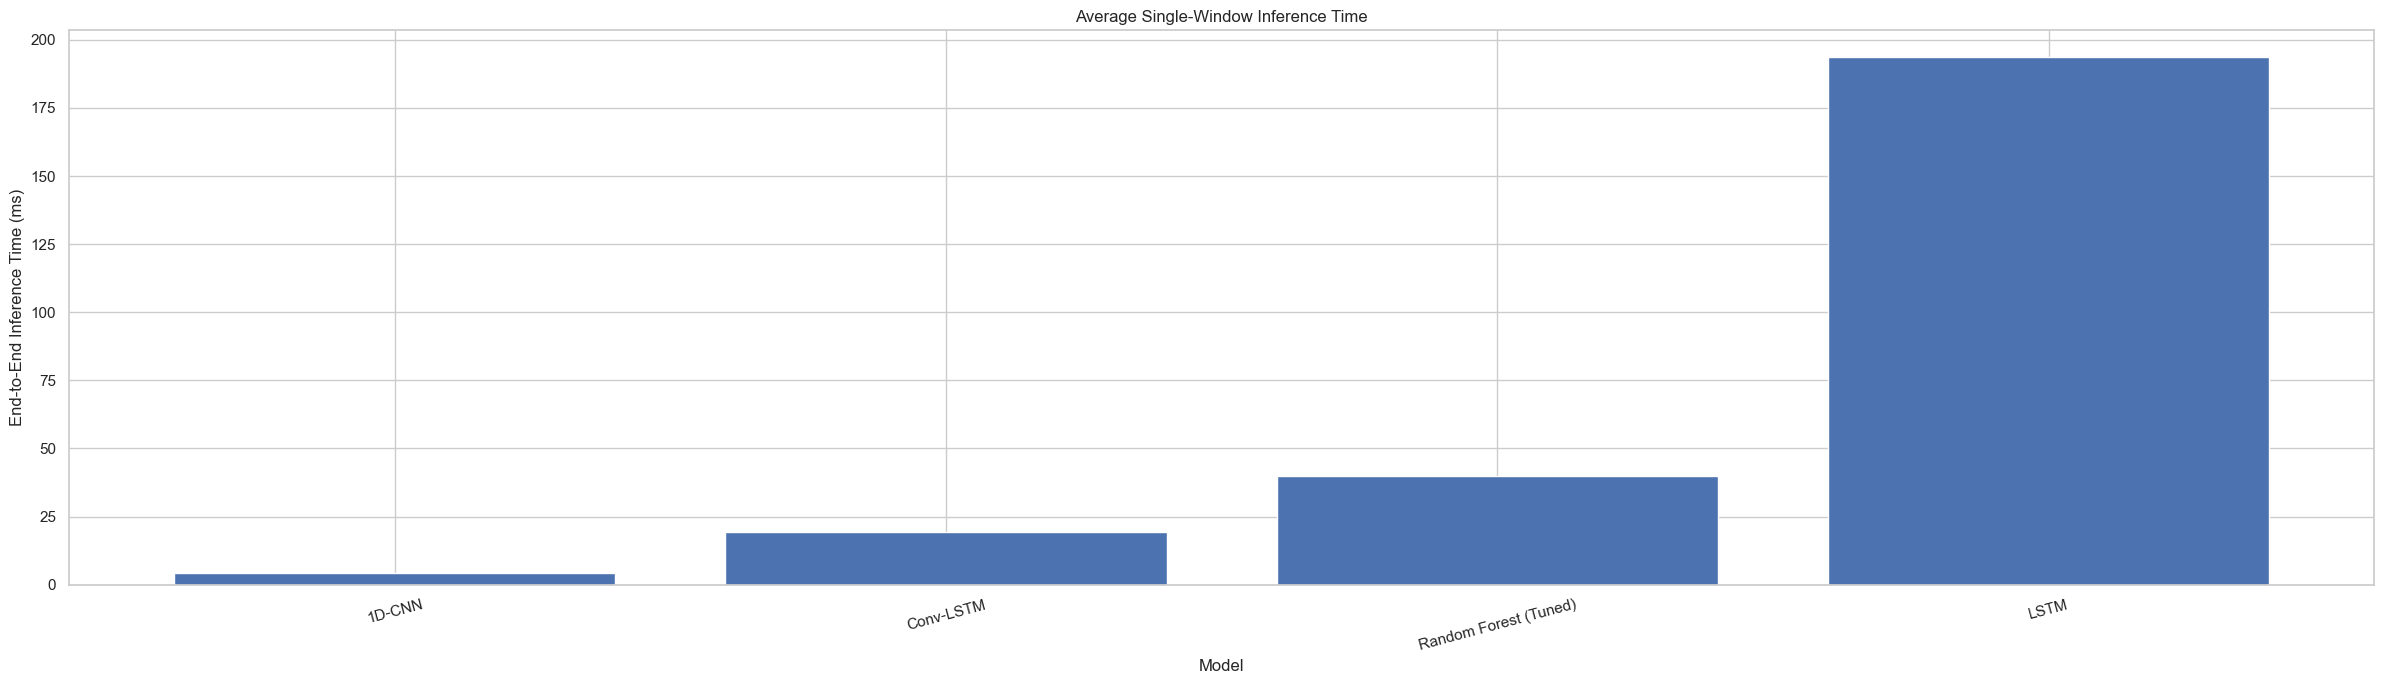

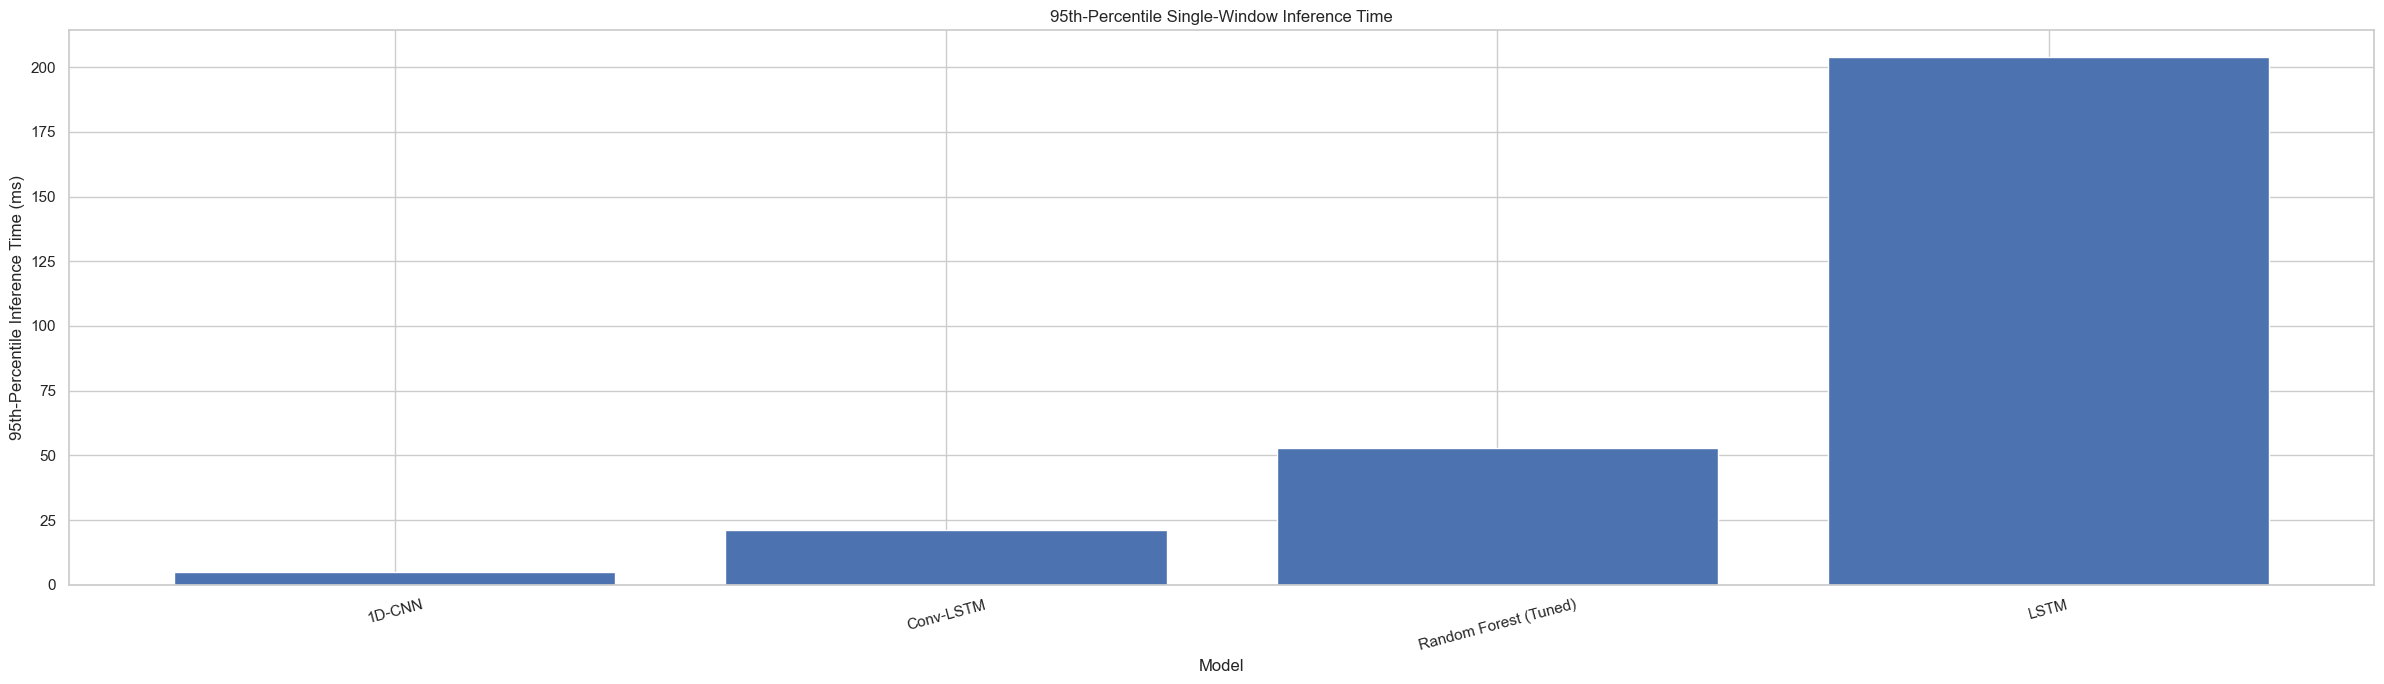

In [ ]:
def select_inference_windows():
    """Select evenly spaced windows for a stable latency benchmark."""
    count = min(MAX_BENCHMARK_WINDOWS, len(X_windows))
    indices = np.linspace(0, len(X_windows) - 1, count, dtype=int)
    return X_windows[indices].astype(np.float32)


def fit_inference_scaler():
    """Fit the preprocessing scaler used before neural-network inference."""
    scaler = StandardScaler()
    scaler.fit(X_windows.reshape(-1, X_windows.shape[-1]))
    return scaler


def scale_single_window(raw_window, scaler):
    """Scale one raw HAR window and restore the expected batch dimension."""
    features = raw_window.shape[-1]
    scaled = scaler.transform(raw_window.reshape(-1, features))
    return scaled.reshape(1, WINDOW_SIZE, features).astype(np.float32)


def get_inference_random_forest():
    """Return the tuned deployment RF when available, otherwise fit the base RF."""
    if "final_tuned_rf_model" in globals():
        return final_tuned_rf_model, "Random Forest (Tuned)"

    model = build_random_forest(RANDOM_SEED)
    model.fit(extract_random_forest_features(X_windows), y_encoded)
    return model, "Random Forest (Base)"


def build_latency_models():
    """Build architecture-identical neural networks for forward-pass timing."""
    tf.keras.backend.clear_session()
    cnn = build_cnn_model(X_windows.shape[1:], NUM_CLASSES)
    lstm = build_lstm_model(X_windows.shape[1:], NUM_CLASSES)
    conv_shape = (
        NUMBER_OF_SUBSEQUENCES,
        1,
        STEPS_PER_SUBSEQUENCE,
        X_windows.shape[-1],
    )
    convlstm = build_convlstm_model(conv_shape, NUM_CLASSES)
    return cnn, lstm, convlstm


def make_rf_inference_function(model):
    """Return an end-to-end single-window RF inference callable."""
    def infer(raw_window):
        """Predict one activity from a raw window using the Random Forest."""
        features = extract_random_forest_features(raw_window[np.newaxis, ...])
        return model.predict(features)[0]
    return infer


def make_neural_inference_function(model, scaler, input_transform=None):
    """Return an end-to-end single-window neural inference callable."""
    def infer(raw_window):
        """Predict one activity from a raw window using a neural model."""
        prepared = scale_single_window(raw_window, scaler)
        if input_transform is not None:
            prepared = input_transform(prepared)
        probabilities = model(prepared, training=False).numpy()
        return int(np.argmax(probabilities, axis=1)[0])
    return infer


def warm_up_inference(inference_function, windows):
    """Run untimed predictions to remove one-off framework start-up overhead."""
    for index in range(INFERENCE_WARMUP_RUNS):
        inference_function(windows[index % len(windows)])


def time_inference_runs(inference_function, windows):
    """Measure one end-to-end inference time per raw window in milliseconds."""
    timings = []
    for window in windows:
        started = time.perf_counter_ns()
        inference_function(window)
        timings.append((time.perf_counter_ns() - started) / 1_000_000)
    return np.asarray(timings)


def summarise_inference_times(model_name, timings):
    """Convert raw timing measurements into deployment-oriented statistics."""
    mean_ms = float(np.mean(timings))
    return {
        "Model": model_name,
        "Number_of_Runs": len(timings),
        "Mean_Inference_ms": mean_ms,
        "Median_Inference_ms": float(np.median(timings)),
        "SD_Inference_ms": float(np.std(timings)),
        "P95_Inference_ms": float(np.percentile(timings, 95)),
        "Approx_Max_Windows_Per_Second": 1000 / mean_ms if mean_ms else np.inf,
    }


def benchmark_inference_function(model_name, inference_function, windows):
    """Warm up and benchmark one single-window inference callable."""
    warm_up_inference(inference_function, windows)
    timings = time_inference_runs(inference_function, windows)
    return summarise_inference_times(model_name, timings)


def plot_inference_metric(results, column, title, ylabel):
    """Plot one latency metric for all evaluated models."""
    plt.figure(figsize=(24, 7))
    plt.bar(results["Model"], results[column])
    plt.title(title)
    plt.xlabel("Model")
    plt.ylabel(ylabel)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


def build_inference_benchmarks(scaler):
    """Build the named single-window inference callables used by the benchmark."""
    rf_model, rf_name = get_inference_random_forest()
    cnn_model, lstm_model, convlstm_model = build_latency_models()
    return [
        (rf_name, make_rf_inference_function(rf_model)),
        ("1D-CNN", make_neural_inference_function(cnn_model, scaler)),
        ("LSTM", make_neural_inference_function(lstm_model, scaler)),
        (
            "Conv-LSTM",
            make_neural_inference_function(
                convlstm_model,
                scaler,
                reshape_for_convlstm,
            ),
        ),
    ]


def benchmark_all_models(windows, benchmarks):
    """Run the same latency benchmark for every model family."""
    rows = [
        benchmark_inference_function(name, inference_function, windows)
        for name, inference_function in benchmarks
    ]
    return (
        pd.DataFrame(rows)
        .sort_values("Mean_Inference_ms")
        .reset_index(drop=True)
    )


def report_inference_results(results):
    """Display latency results and relate them to the HAR window schedule."""
    print_section("SINGLE-WINDOW END-TO-END INFERENCE LATENCY", 90)
    display(results.round(4))

    print(f"Window accumulation time: {WINDOW_SIZE / SAMPLING_RATE_HZ:.2f} seconds")
    print(f"New prediction window every: {WINDOW_STEP / SAMPLING_RATE_HZ:.2f} seconds")

    fastest = results.iloc[0]
    print(f"Fastest computational model: {fastest['Model']}")
    print(f"Mean computational inference time: {fastest['Mean_Inference_ms']:.4f} ms")


def plot_inference_results(results):
    """Plot mean and 95th-percentile end-to-end inference latency."""
    plot_inference_metric(
        results,
        "Mean_Inference_ms",
        "Average Single-Window Inference Time",
        "End-to-End Inference Time (ms)",
    )
    plot_inference_metric(
        results,
        "P95_Inference_ms",
        "95th-Percentile Single-Window Inference Time",
        "95th-Percentile Inference Time (ms)",
    )


def run_inference_benchmark():
    """Benchmark end-to-end single-window latency for all four model families."""
    global inference_time_results

    windows = select_inference_windows()
    scaler = fit_inference_scaler()
    benchmarks = build_inference_benchmarks(scaler)
    inference_time_results = benchmark_all_models(windows, benchmarks)

    report_inference_results(inference_time_results)
    plot_inference_results(inference_time_results)
    return inference_time_results


inference_time_results = run_inference_benchmark()


---
### Pickle the Model 
---

In [ ]:
def get_deployment_model():
    """Return the tuned deployment Random Forest when it has been created."""
    if "final_tuned_rf_model" not in globals():
        raise RuntimeError(
            "Run the Random Forest tuning pipeline before exporting the final model."
        )
    return final_tuned_rf_model


def create_model_directory(directory_name=MODEL_DIRECTORY):
    """Create and return the directory used for saved model artefacts."""
    directory = Path(directory_name)
    directory.mkdir(parents=True, exist_ok=True)
    return directory


def run_model_export():
    """Save the final tuned Random Forest and its label encoder."""
    model_directory = create_model_directory()
    model_path = model_directory / "random_forest_model.pkl"
    labels_path = model_directory / "activity_label_encoder.pkl"

    joblib.dump(get_deployment_model(), model_path)
    joblib.dump(label_encoder, labels_path)

    print(f"Saved model to: {model_path.resolve()}")
    print(f"Saved label encoder to: {labels_path.resolve()}")
    return model_path


# Export is intentionally not called automatically.
# Call run_model_export() once you are satisfied with the tuned model.

create_model_directory()
run_model_export()


Saved model to: /Users/ikenjokudc/Documents/Arduino/finals-project/models/random_forest_model.pkl
Saved label encoder to: /Users/ikenjokudc/Documents/Arduino/finals-project/models/activity_label_encoder.pkl


PosixPath('models/random_forest_model.pkl')

### Modek Joblib
---

In [ ]:
# =============================================================================
# CONVERT EXISTING RANDOM FOREST MODEL INTO DEPLOYMENT BUNDLE
# =============================================================================

from pathlib import Path

import joblib
import sklearn


# =============================================================================
# PROJECT PATHS
# =============================================================================

PROJECT_ROOT = Path.cwd()

# If this is executed from notebooks/, move one directory up.
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent


MODEL_DIRECTORY = (
    PROJECT_ROOT
    /
    "models"
)


SOURCE_MODEL_PATH = (
    MODEL_DIRECTORY
    /
    "random_forest_model.pkl"
)


OUTPUT_BUNDLE_PATH = (
    MODEL_DIRECTORY
    /
    "random_forest_bundle.joblib"
)


# =============================================================================
# MODEL CONFIGURATION
# =============================================================================

SAMPLING_RATE_HZ = 50

WINDOW_SIZE = 100

WINDOW_STEP = 50

LOWPASS_CUTOFF_HZ = 4.0

FILTER_ORDER = 4


SENSOR_NODES = [
    "knee",
    "lumbar",
    "thigh"
]


SENSOR_CHANNELS = [
    "ax",
    "ay",
    "az",
    "gx",
    "gy",
    "gz"
]


MODEL_FEATURE_COLUMNS = [
    f"{node}_{channel}"
    for node in SENSOR_NODES
    for channel in SENSOR_CHANNELS
]


# These must be in the same order used by your LabelEncoder.
CLASS_LABELS = [
    "sit",
    "stand",
    "walk"
]


# =============================================================================
# LOAD EXISTING MODEL
# =============================================================================

def load_existing_model(model_path):
    """Load the previously exported Random Forest."""

    if not model_path.exists():
        raise FileNotFoundError(
            f"Model not found: {model_path}"
        )

    return joblib.load(
        model_path
    )


# =============================================================================
# VALIDATE MODEL
# =============================================================================

def validate_random_forest(model):
    """
    Check that the model expects the same number of statistical features
    produced by the real-time preprocessing pipeline.
    """

    statistics_per_channel = 7

    expected_features = (
        len(MODEL_FEATURE_COLUMNS)
        *
        statistics_per_channel
    )


    actual_features = getattr(
        model,
        "n_features_in_",
        None
    )


    print(
        f"Expected RF features: {expected_features}"
    )

    print(
        f"Model expects: {actual_features}"
    )


    if (
        actual_features is not None
        and
        actual_features != expected_features
    ):
        raise ValueError(
            "The saved Random Forest does not match the "
            "current real-time feature extraction pipeline."
        )


# =============================================================================
# CREATE BUNDLE
# =============================================================================

def create_model_bundle(model):
    """Package the trained classifier with deployment metadata."""

    return {
        "model": model,

        "classes": CLASS_LABELS,

        "feature_columns": MODEL_FEATURE_COLUMNS,

        "sampling_rate_hz": SAMPLING_RATE_HZ,

        "window_size": WINDOW_SIZE,

        "window_step": WINDOW_STEP,

        "lowpass_cutoff_hz": LOWPASS_CUTOFF_HZ,

        "filter_order": FILTER_ORDER,

        "sklearn_version": sklearn.__version__,
    }


# =============================================================================
# SAVE BUNDLE
# =============================================================================

def save_model_bundle(bundle, output_path):
    """Save the deployment bundle to the models directory."""

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    joblib.dump(
        bundle,
        output_path
    )


# =============================================================================
# RUN CONVERSION
# =============================================================================

random_forest_model = (
    load_existing_model(
        SOURCE_MODEL_PATH
    )
)


validate_random_forest(
    random_forest_model
)


model_bundle = (
    create_model_bundle(
        random_forest_model
    )
)


save_model_bundle(
    model_bundle,
    OUTPUT_BUNDLE_PATH
)


print("\nModel bundle created successfully.")

print(
    f"Source model:\n"
    f"{SOURCE_MODEL_PATH.resolve()}"
)

print(
    f"\nDeployment bundle:\n"
    f"{OUTPUT_BUNDLE_PATH.resolve()}"
)

print(
    f"\nBundle exists: "
    f"{OUTPUT_BUNDLE_PATH.exists()}"
)

Expected RF features: 126
Model expects: 126

Model bundle created successfully.
Source model:
/Users/ikenjokudc/Documents/Arduino/finals-project/models/random_forest_model.pkl

Deployment bundle:
/Users/ikenjokudc/Documents/Arduino/finals-project/models/random_forest_bundle.joblib

Bundle exists: True


### Project Pipeline Reference

The functions below represent the notebook's major executable stages in dependency order.
They are stored as callables rather than strings, so they can be inspected, iterated over,
or executed sequentially when needed.

The model-export stage is included last but remains an explicit deployment action.


In [ ]:
project_pipelines = [
    show_data_folder_tree,
    run_dataset_build_pipeline,
    run_dataset_integrity_pipeline,
    run_activity_distribution_eda,
    run_signal_distribution_eda,
    run_boxplot_eda,
    run_participant_distribution_eda,
    run_activity_completion_check,
    run_time_domain_eda,
    run_filtering_pipeline,
    run_filtered_signal_eda,
    run_activity_dataset_split,
    run_feature_engineering_pipeline,
    run_duration_analysis,
    run_walking_cadence_analysis,
    run_pre_feature_selection_checks,
    run_feature_summary,
    run_correlation_analysis,
    run_redundant_feature_reduction,
    run_har_data_preparation,
    run_windowing_pipeline,
    run_loso_setup,
    run_random_forest_experiment,
    run_cnn_experiment,
    run_lstm_experiment,
    run_convlstm_experiment,
    run_model_summary,
    run_classification_reports,
    run_confusion_matrix_analysis,
    run_generalisation_analysis,
    run_feature_importance_analysis,
    run_random_forest_tuning,
    run_inference_benchmark,
    run_model_export,
]


def run_project_pipeline(include_model_export=False):
    """Execute the registered project pipelines in order."""
    pipelines = project_pipelines if include_model_export else project_pipelines[:-1]
    for pipeline in pipelines:
        print_section(f"RUNNING: {pipeline.__name__}", 90)
        pipeline()


print("Project pipeline order:")
for index, pipeline in enumerate(project_pipelines, start=1):
    print(f"{index:02d}. {pipeline.__name__}")


Project pipeline order:
01. show_data_folder_tree
02. run_dataset_build_pipeline
03. run_dataset_integrity_pipeline
04. run_activity_distribution_eda
05. run_signal_distribution_eda
06. run_boxplot_eda
07. run_participant_distribution_eda
08. run_activity_completion_check
09. run_time_domain_eda
10. run_filtering_pipeline
11. run_filtered_signal_eda
12. run_activity_dataset_split
13. run_feature_engineering_pipeline
14. run_duration_analysis
15. run_walking_cadence_analysis
16. run_pre_feature_selection_checks
17. run_feature_summary
18. run_correlation_analysis
19. run_redundant_feature_reduction
20. run_har_data_preparation
21. run_windowing_pipeline
22. run_loso_setup
23. run_random_forest_experiment
24. run_cnn_experiment
25. run_lstm_experiment
26. run_convlstm_experiment
27. run_model_summary
28. run_classification_reports
29. run_confusion_matrix_analysis
30. run_generalisation_analysis
31. run_feature_importance_analysis
32. run_random_forest_tuning
33. run_inference_benchmark
